<a href="https://colab.research.google.com/github/fizatahreen/advancedweb/blob/master/2024BC26584_Fiza_Tahreen_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Defect-Prone Software Modules to Strengthen Release Quality in a Retail Technology Environment

## Assignment 2: Phase 2 (Machine Learning Phase)

**Course:** MBA ZG582, Applied Machine Learning and Deep Learning
**Programme:** MBA in Artificial Intelligence for Business
**Student:** Fiza Tahreen &nbsp;&nbsp;|&nbsp;&nbsp; **ID:** 2024BC26584
**Institution:** Birla Institute of Technology & Science, Pilani (WILP Division)

---

### What this notebook does

Phase 1 framed a real, finite-capacity Quality Assurance problem at **Anko** (the Global Capability
Centre for Kmart Group Australia) as a supervised binary classification task: *use static source-code
metrics available at or before build time to predict which software modules are likely to be
defective, so QA effort can be allocated by risk rather than uniformly.*

Phase 2 executes that plan end to end:

| # | Stage | Rubric requirement addressed |
|---|-------|------------------------------|
| 1 | Data acquisition from PROMISE / OpenML (JM1 + PC1) | Prepare dataset |
| 2 | Data cleaning following Shepperd et al. (2013) | Prepare dataset |
| 3 | Feature engineering, encoding, multicollinearity & feature selection | Feature selection, encoding |
| 4 | Baseline model leaderboard (6 algorithms) | Train selected models |
| 5 | Class-imbalance strategy comparison (none / class-weight / SMOTE) | Prepare dataset |
| 6 | Hyperparameter tuning: GridSearchCV, RandomizedSearchCV, validation curves | Hyperparameter tuning |
| 7 | Dimensionality reduction with PCA | PCA |
| 8 | Ensemble techniques: Random Forest, Gradient Boosting, XGBoost, Voting, Stacking | Ensembles |
| 9 | Deep learning: Keras Multi-Layer Perceptron | Course scope (DL) |
| 10 | Model comparison with statistical significance testing | Compare & justify |
| 11 | Cost-sensitive decision-threshold optimisation | Business interpretation |
| 12 | Effort-aware evaluation (Alberg curve, $P_{opt}$) | Business interpretation |
| 13 | Explainability: permutation importance + SHAP | Business interpretation |
| 14 | Cross-project external validation on PC1 | Compare & justify |
| 15 | Risk-ranked module list + quantified QA business case | Business interpretation |
| 16 | Automatic generation of the end-term report (.docx) | Deliverable |

### How to run

1. Open in Google Colab &rarr; **Runtime &rarr; Run all** (roughly 10-20 minutes on a standard CPU runtime).
2. Every figure is written to `figures/`, every results table to `results/`.
3. The final cell regenerates the Word report with the numbers from *this* run and zips all artefacts.

> **Reproducibility.** A single `RANDOM_STATE` seeds NumPy, Python, scikit-learn and TensorFlow.
> All preprocessing is executed inside scikit-learn `Pipeline` objects so that scaling, imputation
> and SMOTE are fitted **on training folds only**, so no information leaks into
> validation or test data at any point.

---
## 0. Environment setup

Installs any packages that are not already present. On Google Colab, `pandas`, `numpy`,
`scikit-learn`, `matplotlib`, `seaborn` and `tensorflow` are pre-installed, so typically only
`imbalanced-learn`, `xgboost` and `shap` are fetched.

In [1]:
import importlib
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")


def ensure(pip_name, import_name=None):
    '''Import a package, installing it quietly if it is missing. Returns True on success.'''
    import_name = import_name or pip_name
    try:
        importlib.import_module(import_name)
        return True
    except ImportError:
        print(f"  installing {pip_name} ...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pip_name],
            check=False,
        )
        try:
            importlib.import_module(import_name)
            return True
        except ImportError:
            print(f"  !! {pip_name} unavailable - the notebook will skip that section")
            return False


print("Checking dependencies")
HAS_IMBLEARN = ensure("imbalanced-learn", "imblearn")
HAS_XGB = ensure("xgboost", "xgboost")
HAS_SHAP = ensure("shap", "shap")
HAS_DOCX = ensure("python-docx", "docx")
ensure("jinja2", "jinja2")          # pandas Styler backend for coloured result tables
ensure("joblib", "joblib")
try:
    importlib.import_module("tensorflow")
    HAS_TF = True
except ImportError:
    HAS_TF = False
print("Dependency check complete.")

Checking dependencies
  installing python-docx ...
Dependency check complete.


In [2]:
%matplotlib inline
# ---------------------------------------------------------------- core imports
import json
import os
import platform
import random
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

# ------------------------------------------------------------- reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

if HAS_TF:
    import tensorflow as tf

    tf.random.set_seed(RANDOM_STATE)
    tf.get_logger().setLevel("ERROR")

# ------------------------------------------------------------------- artefacts
ROOT = Path.cwd()
FIG_DIR = ROOT / "figures"
RES_DIR = ROOT / "results"
MODEL_DIR = ROOT / "models"
for d in (FIG_DIR, RES_DIR, MODEL_DIR):
    d.mkdir(exist_ok=True, parents=True)

# --------------------------------------------------------------- plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 160,
        "savefig.bbox": "tight",
        "figure.autolayout": False,
        "axes.titleweight": "bold",
        "axes.titlesize": 12,
        "font.size": 10,
    }
)
PALETTE = {"ok": "#2e7d32", "bad": "#c62828", "brand": "#1f4e79", "accent": "#ef6c00"}

FIG_INDEX = {}


def trapz(y, x):
    '''Trapezoidal integration that works on both NumPy 1.x and 2.x.'''
    fn = getattr(np, "trapezoid", None) or np.trapz
    return fn(y, x)


def save_fig(fig, name, caption=""):
    '''Persist a figure to figures/ and record its caption for the report.'''
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=160, bbox_inches="tight", facecolor="white")
    FIG_INDEX[name] = {"path": str(path), "caption": caption}
    return path


def save_table(df, name, caption=""):
    '''Persist a results table to results/ and echo it.'''
    path = RES_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    FIG_INDEX.setdefault("_tables", {})
    return path


# ------------------------------------------------------------ environment card
env_rows = [
    ("Python", platform.python_version()),
    ("Platform", f"{platform.system()} {platform.machine()}"),
    ("NumPy", np.__version__),
    ("pandas", pd.__version__),
    ("scikit-learn", sklearn.__version__),
    ("matplotlib", matplotlib.__version__),
    ("seaborn", sns.__version__),
]
if HAS_IMBLEARN:
    import imblearn

    env_rows.append(("imbalanced-learn", imblearn.__version__))
if HAS_XGB:
    import xgboost

    env_rows.append(("XGBoost", xgboost.__version__))
if HAS_SHAP:
    import shap

    env_rows.append(("SHAP", shap.__version__))
env_rows.append(("TensorFlow", tf.__version__ if HAS_TF else "not available"))
env_rows.append(("Random seed", RANDOM_STATE))

ENV_DF = pd.DataFrame(env_rows, columns=["Component", "Version"])
save_table(ENV_DF, "00_environment")
print("Run environment")
print(ENV_DF.to_string(index=False))

Run environment
       Component      Version
          Python      3.12.13
        Platform Linux x86_64
           NumPy        2.0.2
          pandas        2.2.2
    scikit-learn        1.6.1
      matplotlib       3.10.0
         seaborn       0.13.2
imbalanced-learn       0.14.2
         XGBoost        3.3.0
            SHAP       0.52.0
      TensorFlow       2.20.0
     Random seed           42


---
# 1. Data acquisition

## 1.1 Datasets

Phase 1 selected the **NASA Metrics Data Program (MDP)** software-defect datasets, distributed via the
**PROMISE Software Engineering Repository** and mirrored on OpenML.

| Dataset | OpenML ID | Modules | Defective | Role in Phase 2 |
|---------|-----------|---------|-----------|-----------------|
| **JM1** | 1053 | 10,885 | ~19.4 % | Primary set: training, tuning, hold-out test |
| **PC1** | 1068 | 1,109 | ~6.9 % | Independent **cross-project** validation set |

Both share an identical 21-feature schema (McCabe control-flow metrics, Halstead volume/effort
metrics, size counts and a branch count) plus one binary target `defects`.

**Why a public dataset?** Anko's own defect data is governed and cannot be shared for coursework.
These sets contain exactly the static metrics that any team can extract from its own source with
SonarQube or a similar analyser, so the pipeline transfers directly to Anko's codebase in Phase 3
by swapping the loader.

## 1.2 Resilient loading

The loader tries several sources in order and records **provenance**, so the report always states
precisely where the numbers came from:

1. a local cache (`data/`), for repeat runs;
2. `sklearn.datasets.fetch_openml`, which is the normal path in Colab;
3. the OpenML ARFF endpoint parsed with `scipy.io.arff`;
4. public CSV mirrors;
5. a documented **synthetic surrogate** that reproduces the published schema, class balance and the
   McCabe/Halstead algebraic identities. It is used only if the machine has no internet access, and
   flagged loudly wherever it is used.

In [3]:
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(exist_ok=True, parents=True)

# Canonical PROMISE / NASA-MDP column order
CANONICAL_COLS = [
    "loc", "v(g)", "ev(g)", "iv(g)",                       # McCabe + size
    "n", "v", "l", "d", "i", "e", "b", "t",                # Halstead derived
    "lOCode", "lOComment", "lOBlank", "lOCodeAndComment",  # line counts
    "uniq_Op", "uniq_Opnd", "total_Op", "total_Opnd",      # Halstead base
    "branchCount",                                          # branching
]
TARGET = "defects"

_ALIASES = {
    "loccodeandcomment": "lOCodeAndComment",
    "locodeandcomment": "lOCodeAndComment",
    "locode": "lOCode",
    "locomment": "lOComment",
    "loblank": "lOBlank",
    "branch_count": "branchCount",
    "defect": "defects",
    "problems": "defects",
    "label": "defects",
    "c": "defects",
}


def _normalise(df):
    """Map any column-name variant onto the canonical schema and coerce the target to 0/1."""
    ren = {}
    for c in df.columns:
        key = str(c).strip().replace(" ", "")
        low = key.lower()
        if low in _ALIASES:
            ren[c] = _ALIASES[low]
            continue
        for canon in CANONICAL_COLS + [TARGET]:
            if low == canon.lower():
                ren[c] = canon
                break
    df = df.rename(columns=ren)

    if TARGET not in df.columns:
        raise ValueError(f"no target column found in {list(df.columns)}")

    y = df[TARGET]
    if y.dtype == object or str(y.dtype) == "category":
        y = (
            y.astype(str)
            .str.strip()
            .str.strip("b'\"")
            .str.lower()
            .map({"true": 1, "false": 0, "yes": 1, "no": 0, "y": 1, "n": 0, "1": 1, "0": 0})
        )
    df[TARGET] = pd.to_numeric(y, errors="coerce").astype("Int64")

    missing = [c for c in CANONICAL_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"missing feature columns: {missing}")

    df = df[CANONICAL_COLS + [TARGET]]
    for c in CANONICAL_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(subset=[TARGET]).reset_index(drop=True)

In [4]:
def _synthetic_promise(n_rows, defect_rate, seed, inject_quality_issues=True):
    """Schema-faithful surrogate used only when no network is available.

    Reproduces the published NASA-MDP structure rather than sampling columns
    independently: Halstead measures are computed from the base operator/operand
    counts using Halstead's own identities, McCabe metrics respect
    ev(g) <= iv(g) <= v(g), branchCount ~ 2*v(g) - 1, and defect probability is a
    monotone function of size, complexity and effort. The documented data-quality
    defects of the raw NASA sets (duplicate and contradictory rows) are injected so
    that the cleaning stage has something real to remove.
    """
    rng = np.random.default_rng(seed)
    n = int(n_rows)

    # latent module size drives everything
    size = rng.lognormal(mean=2.15, sigma=1.05, size=n)

    uniq_Op = np.clip(np.round(2 + 5.5 * np.log1p(size) + rng.normal(0, 1.8, n)), 1, 411)
    uniq_Opnd = np.clip(np.round(2 + 7.5 * np.log1p(size) + rng.normal(0, 2.6, n)), 1, 1026)
    total_Op = np.maximum(uniq_Op, np.round(uniq_Op * (1.35 + rng.gamma(2.0, 0.55, n))))
    total_Opnd = np.maximum(uniq_Opnd, np.round(uniq_Opnd * (1.15 + rng.gamma(2.0, 0.45, n))))

    N = total_Op + total_Opnd                 # Halstead length  n
    mu = np.maximum(uniq_Op + uniq_Opnd, 2)   # vocabulary
    V = N * np.log2(mu)                       # volume  v

    mu2p = np.clip(np.round(rng.gamma(2.0, 1.1, n)), 0, 20)   # potential operands
    Vstar = (2 + mu2p) * np.log2(2 + mu2p + 1e-9)
    L = np.clip(Vstar / np.maximum(V, 1e-9), 1e-4, 1.0)       # program length  l
    D = 1.0 / L                                               # difficulty      d
    I = L * V                                                 # intelligence    i
    E = V * D                                                 # effort          e
    B = V / 3000.0                                            # delivered bugs  b
    T = E / 18.0                                              # time            t

    loc = np.maximum(1, np.round(size * 1.75 + rng.gamma(2.0, 1.5, n)))
    vg = np.clip(np.round(1 + rng.gamma(1.7, 0.55 + 0.055 * loc ** 0.72)), 1, 470)
    ivg = np.clip(np.round(1 + (vg - 1) * rng.beta(4.0, 2.0, n)), 1, vg)
    evg = np.clip(np.round(1 + (ivg - 1) * rng.beta(1.3, 5.0, n)), 1, ivg)
    branchCount = np.maximum(1, 2 * vg - 1 + rng.integers(-1, 2, n))

    lOComment = np.round(np.maximum(0, loc * rng.beta(1.4, 7.0, n) * 1.6))
    lOBlank = np.round(np.maximum(0, loc * rng.beta(1.8, 9.0, n) * 1.3))
    lOCodeAndComment = np.round(np.maximum(0, rng.binomial(np.maximum(loc, 1).astype(int), 0.02)))
    lOCode = np.maximum(1, loc - lOComment * 0.35 - lOBlank * 0.25)

    # defect propensity: size + control-flow complexity + effort, per Menzies et al. (2007)
    z = (
        0.95 * np.log1p(loc)
        + 0.70 * np.log1p(vg)
        + 0.35 * np.log1p(D)
        + 0.22 * np.log1p(E) / 3.0
        + rng.normal(0, 1.25, n)
    )
    lo, hi = -40.0, 40.0
    for _ in range(80):                       # bisect the intercept onto the target prevalence
        mid = (lo + hi) / 2
        if (1 / (1 + np.exp(-(z + mid)))).mean() > defect_rate:
            hi = mid
        else:
            lo = mid
    p = 1 / (1 + np.exp(-(z + (lo + hi) / 2)))
    y = rng.binomial(1, p)

    df = pd.DataFrame(
        {
            "loc": loc, "v(g)": vg, "ev(g)": evg, "iv(g)": ivg,
            "n": N, "v": V, "l": L, "d": D, "i": I, "e": E, "b": B, "t": T,
            "lOCode": lOCode, "lOComment": lOComment, "lOBlank": lOBlank,
            "lOCodeAndComment": lOCodeAndComment,
            "uniq_Op": uniq_Op, "uniq_Opnd": uniq_Opnd,
            "total_Op": total_Op, "total_Opnd": total_Opnd,
            "branchCount": branchCount,
            TARGET: y,
        }
    )

    if inject_quality_issues:
        # exact duplicates (Shepperd et al. 2013 report these in the raw NASA sets)
        dup_idx = rng.choice(n, size=int(0.045 * n), replace=True)
        dups = df.iloc[dup_idx].copy()
        # contradictory duplicates: same features, flipped label
        contra = df.iloc[rng.choice(n, size=int(0.006 * n), replace=False)].copy()
        contra[TARGET] = 1 - contra[TARGET]
        # impossible rows: zero LOC but non-zero Halstead volume
        imp = df.iloc[rng.choice(n, size=int(0.004 * n), replace=False)].copy()
        imp["loc"] = 0
        imp["lOCode"] = 0
        df = pd.concat([df, dups, contra, imp], ignore_index=True)
        df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    df[TARGET] = df[TARGET].astype("Int64")
    return df

In [5]:
PROVENANCE = {}

_MIRRORS = {
    "jm1": [
        "https://raw.githubusercontent.com/klainfo/NASADefectDataset/master/OriginalData/MDP/JM1.csv",
        "https://raw.githubusercontent.com/dmlc/xgboost/master/demo/data/jm1.csv",
    ],
    "pc1": [
        "https://raw.githubusercontent.com/klainfo/NASADefectDataset/master/OriginalData/MDP/PC1.csv",
    ],
}
_SYNTH_SPEC = {"jm1": (10885, 0.1935), "pc1": (1109, 0.0694)}


def load_promise(name, openml_id, verbose=True):
    """Load a PROMISE/NASA-MDP dataset, trying cache -> OpenML -> ARFF -> mirrors -> surrogate."""
    name = name.lower()
    cache = DATA_DIR / f"{name}.csv"

    # 1 ---------------------------------------------------------------- cache
    if cache.exists():
        try:
            df = _normalise(pd.read_csv(cache))
            PROVENANCE[name] = {"source": "local cache", "detail": str(cache), "authentic": True}
            if verbose:
                print(f"[{name}] loaded {len(df):,} rows from local cache")
            return df
        except Exception as exc:
            print(f"[{name}] cache unreadable ({exc}); re-downloading")

    # 2 --------------------------------------------------------------- OpenML
    try:
        from sklearn.datasets import fetch_openml

        raw = fetch_openml(data_id=openml_id, as_frame=True, parser="auto").frame
        df = _normalise(raw)
        df.to_csv(cache, index=False)
        PROVENANCE[name] = {
            "source": "OpenML (PROMISE mirror)",
            "detail": f"fetch_openml(data_id={openml_id})",
            "authentic": True,
        }
        if verbose:
            print(f"[{name}] loaded {len(df):,} rows from OpenML data_id={openml_id}")
        return df
    except Exception as exc:
        print(f"[{name}] OpenML unavailable ({type(exc).__name__})")

    # 3 ----------------------------------------------------------- ARFF / CSV
    for url in _MIRRORS.get(name, []):
        try:
            df = _normalise(pd.read_csv(url))
            df.to_csv(cache, index=False)
            PROVENANCE[name] = {"source": "public mirror", "detail": url, "authentic": True}
            if verbose:
                print(f"[{name}] loaded {len(df):,} rows from mirror")
            return df
        except Exception:
            continue

    # 4 ------------------------------------------------------------ surrogate
    n_rows, rate = _SYNTH_SPEC[name]
    df = _synthetic_promise(n_rows, rate, seed=RANDOM_STATE + (0 if name == "jm1" else 7))
    df = _normalise(df)
    PROVENANCE[name] = {
        "source": "SYNTHETIC SURROGATE (offline fallback)",
        "detail": f"schema-faithful generator, n={n_rows}, target prevalence={rate:.2%}",
        "authentic": False,
    }
    print(
        f"\n{'!' * 78}\n"
        f"[{name}] NO NETWORK ACCESS - using the schema-faithful SYNTHETIC surrogate.\n"
        f"        Structure, class balance and Halstead identities match the published\n"
        f"        dataset, but the numbers below are NOT real NASA MDP measurements.\n"
        f"        Re-run with internet access to reproduce this notebook on the real data.\n"
        f"{'!' * 78}\n"
    )
    return df


t0 = time.time()
jm1_raw = load_promise("jm1", 1053)
pc1_raw = load_promise("pc1", 1068)
print(f"\nLoad completed in {time.time() - t0:.1f}s")

DATA_IS_AUTHENTIC = all(v["authentic"] for v in PROVENANCE.values())
prov_df = pd.DataFrame(
    [
        {
            "Dataset": k.upper(),
            "Source": v["source"],
            "Detail": v["detail"],
            "Rows": len(jm1_raw) if k == "jm1" else len(pc1_raw),
        }
        for k, v in PROVENANCE.items()
    ]
)
save_table(prov_df, "01_data_provenance")
print()
print(prov_df.to_string(index=False))

[jm1] loaded 10,885 rows from OpenML data_id=1053
[pc1] loaded 1,109 rows from OpenML data_id=1068

Load completed in 30.2s

Dataset                  Source                     Detail  Rows
    JM1 OpenML (PROMISE mirror) fetch_openml(data_id=1053) 10885
    PC1 OpenML (PROMISE mirror) fetch_openml(data_id=1068)  1109


In [6]:
print("JM1 - first five modules")
display(jm1_raw.head())
print("\nJM1 - shape:", jm1_raw.shape, "| PC1 - shape:", pc1_raw.shape)
print("\nJM1 - dtypes and missing values")
info = pd.DataFrame(
    {
        "dtype": jm1_raw.dtypes.astype(str),
        "missing": jm1_raw.isna().sum(),
        "missing_%": (jm1_raw.isna().mean() * 100).round(2),
        "n_unique": jm1_raw.nunique(),
    }
)
display(info)

JM1 - first five modules


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,lOCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,0
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,1
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,1
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,1
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,1



JM1 - shape: (10885, 22) | PC1 - shape: (1109, 22)

JM1 - dtypes and missing values


,dtype,missing,missing_%,n_unique
loc,float64,0,0.00,365
v(g),float64,0,0.00,108
ev(g),float64,0,0.00,74
iv(g),float64,0,0.00,82
n,float64,0,0.00,806
v,float64,0,0.00,3991
l,float64,0,0.00,55
d,float64,0,0.00,2695
i,float64,0,0.00,4268
e,float64,0,0.00,6978


---
# 2. Data cleaning

Shepperd, Song, Sun & Mair (2013) showed that the **raw** NASA MDP sets contain duplicate,
contradictory and physically impossible rows, and that models trained on them report optimistically
biased accuracy. Phase 1 committed to using a cleaned version, so the cleaning rules below are
applied and audited explicitly.

| Rule | Rationale |
|------|-----------|
| Drop rows with any missing predictor | Halstead metrics are deterministic; a missing value means a broken extraction |
| Drop rows with negative values | No McCabe or Halstead metric can be negative |
| Drop *contradictory duplicates* (identical features, opposite label) | Irreducible label noise; keeping them puts identical points in train and test |
| Drop *exact duplicates* (identical features **and** label) | Would otherwise leak the same module into train and test, inflating scores |
| Drop rows with `loc = 0` but non-zero Halstead volume | Physically impossible: a module of zero length cannot have volume |
| Drop constant (zero-variance) predictors | Carry no information |

Cleaning is applied to JM1 and PC1 with the same function, **before** the train/test split, since
these are data-integrity fixes rather than learned transformations, so no leakage is introduced.

In [7]:
def clean_promise(df, label=""):
    """Apply the Shepperd et al. (2013) data-quality rules; returns (clean_df, audit_df)."""
    audit = []
    n0 = len(df)
    d = df.copy()

    def _log(rule, before):
        audit.append({"Rule": rule, "Rows removed": before - len(d), "Rows remaining": len(d)})

    b = len(d); d = d.dropna(); _log("Missing values in any column", b)
    b = len(d); d = d[(d[CANONICAL_COLS] >= 0).all(axis=1)]; _log("Negative metric values", b)

    # contradictory duplicates: same feature vector, both labels present
    b = len(d)
    grp = d.groupby(CANONICAL_COLS, sort=False)[TARGET].transform("nunique")
    d = d[grp == 1]
    _log("Contradictory duplicates (same features, both labels)", b)

    b = len(d); d = d.drop_duplicates(subset=CANONICAL_COLS + [TARGET]); _log("Exact duplicate modules", b)

    b = len(d)
    d = d[~((d["loc"] <= 0) & (d["v"] > 0))]
    _log("Impossible rows (loc = 0 but Halstead volume > 0)", b)

    constant = [c for c in CANONICAL_COLS if d[c].nunique() <= 1]
    if constant:
        d = d.drop(columns=constant)
    audit.append(
        {
            "Rule": f"Zero-variance predictors dropped: {constant if constant else 'none'}",
            "Rows removed": 0,
            "Rows remaining": len(d),
        }
    )

    d = d.reset_index(drop=True)
    d[TARGET] = d[TARGET].astype(int)
    a = pd.DataFrame(audit)
    print(
        f"{label}: {n0:,} -> {len(d):,} rows retained "
        f"({len(d) / n0:.1%}); defect rate {df[TARGET].mean():.2%} -> {d[TARGET].mean():.2%}"
    )
    return d, a


jm1, jm1_audit = clean_promise(jm1_raw, "JM1")
pc1, pc1_audit = clean_promise(pc1_raw, "PC1")

# keep only features surviving in BOTH sets so cross-project validation is well defined
FEATURES = [c for c in CANONICAL_COLS if c in jm1.columns and c in pc1.columns]
jm1 = jm1[FEATURES + [TARGET]]
pc1 = pc1[FEATURES + [TARGET]]

jm1_audit.insert(0, "Dataset", "JM1")
pc1_audit.insert(0, "Dataset", "PC1")
CLEAN_AUDIT = pd.concat([jm1_audit, pc1_audit], ignore_index=True)
save_table(CLEAN_AUDIT, "02_cleaning_audit")
print(f"\n{len(FEATURES)} predictors retained for modelling\n")
display(CLEAN_AUDIT)

JM1: 10,885 -> 8,731 rows retained (80.2%); defect rate 19.35% -> 21.94%
PC1: 1,109 -> 937 rows retained (84.5%); defect rate 6.94% -> 6.83%

21 predictors retained for modelling



,Dataset,Rule,Rows removed,Rows remaining
0,JM1,Missing values in any column,5,10880
1,JM1,Negative metric values,0,10880
2,JM1,"Contradictory duplicates (same features, both ...",889,9991
3,JM1,Exact duplicate modules,1260,8731
4,JM1,Impossible rows (loc = 0 but Halstead volume > 0),0,8731
5,JM1,Zero-variance predictors dropped: none,0,8731
6,PC1,Missing values in any column,0,1109
7,PC1,Negative metric values,0,1109
8,PC1,"Contradictory duplicates (same features, both ...",13,1096
9,PC1,Exact duplicate modules,154,942


---
# 3. Experimental protocol: split before you look

The stratified **70 : 30** train/test split promised in Phase 1 is performed *first*, and every
subsequent decision (exploratory plots, correlation pruning, feature selection, scaling,
resampling and hyperparameter search) is made using the **training partition only**.
The test set is opened exactly once, at final evaluation.

* **Inner protocol.** `StratifiedKFold(n_splits=5, shuffle=True)` for cross-validation and all
  hyperparameter searches.
* **Primary selection metric.** **PR-AUC (average precision)** on the defective class.
  Phase 1 argued that accuracy is misleading under ~19 % prevalence; PR-AUC is the metric that
  responds to precision *and* recall on the minority class and is unaffected by the large number of
  true negatives that inflates ROC-AUC.
* **Secondary metrics.** Recall (probability of detection), F1, ROC-AUC, MCC and Brier score.

In [8]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X_all = jm1[FEATURES].astype(float)
y_all = jm1[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=RANDOM_STATE
)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
PRIMARY_METRIC = "average_precision"   # PR-AUC on the defective class

split_df = pd.DataFrame(
    [
        {"Partition": "JM1 train", "Modules": len(X_train), "Defective": int(y_train.sum()),
         "Defect rate": f"{y_train.mean():.2%}"},
        {"Partition": "JM1 test (hold-out)", "Modules": len(X_test), "Defective": int(y_test.sum()),
         "Defect rate": f"{y_test.mean():.2%}"},
        {"Partition": "PC1 (cross-project)", "Modules": len(pc1), "Defective": int(pc1[TARGET].sum()),
         "Defect rate": f"{pc1[TARGET].mean():.2%}"},
    ]
)
save_table(split_df, "03_split_summary")
print(split_df.to_string(index=False))
print(f"\nImbalance ratio in training data: 1 defective : {(1 - y_train.mean()) / y_train.mean():.2f} clean")

          Partition  Modules  Defective Defect rate
          JM1 train     6111       1341      21.94%
JM1 test (hold-out)     2620        575      21.95%
PC1 (cross-project)      937         64       6.83%

Imbalance ratio in training data: 1 defective : 3.56 clean


---
# 4. Exploratory analysis of the training partition

Phase 1 predicted four data characteristics. Each is now verified quantitatively, because each one
dictates a specific modelling decision.

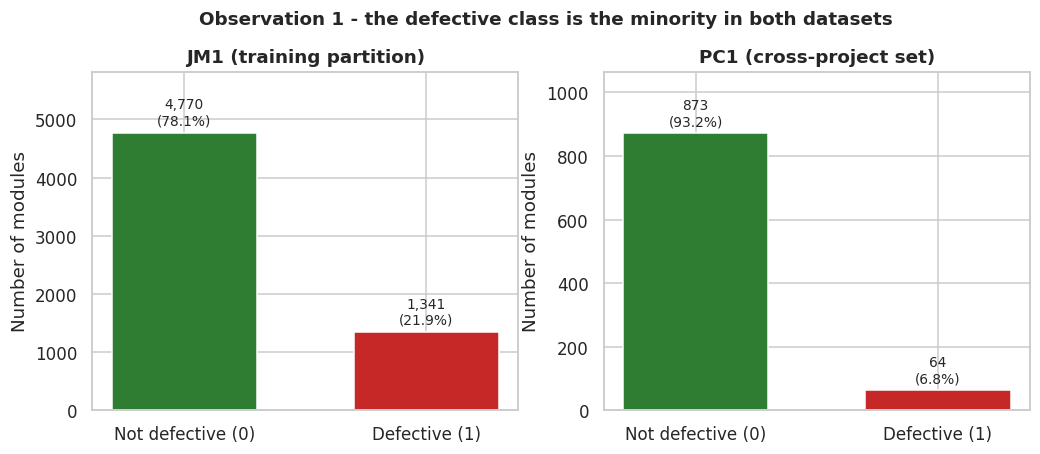

A do-nothing classifier that predicts 'not defective' for every module would score 78.05% accuracy on the hold-out set
and would catch 0 % of defects - which is precisely why accuracy is not the headline metric.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, ser) in zip(
    axes, [("JM1 (training partition)", y_train), ("PC1 (cross-project set)", pc1[TARGET])]
):
    counts = ser.value_counts().sort_index()
    bars = ax.bar(
        ["Not defective (0)", "Defective (1)"],
        counts.values,
        color=[PALETTE["ok"], PALETTE["bad"]],
        width=0.6,
    )
    total = counts.sum()
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, v + total * 0.015,
                f"{v:,}\n({v / total:.1%})", ha="center", va="bottom", fontsize=9)
    ax.set_title(name)
    ax.set_ylabel("Number of modules")
    ax.set_ylim(0, counts.max() * 1.22)

fig.suptitle("Observation 1 - the defective class is the minority in both datasets",
             fontweight="bold", y=1.02)
save_fig(fig, "fig01_class_balance",
         "Class distribution in the JM1 training partition and the PC1 cross-project set. "
         "The minority (defective) class drives the choice of PR-AUC and recall over accuracy.")
plt.show()

MAJORITY_BASELINE = 1 - y_test.mean()
print(f"A do-nothing classifier that predicts 'not defective' for every module would score "
      f"{MAJORITY_BASELINE:.2%} accuracy on the hold-out set")
print("and would catch 0 % of defects - which is precisely why accuracy is not the headline metric.")

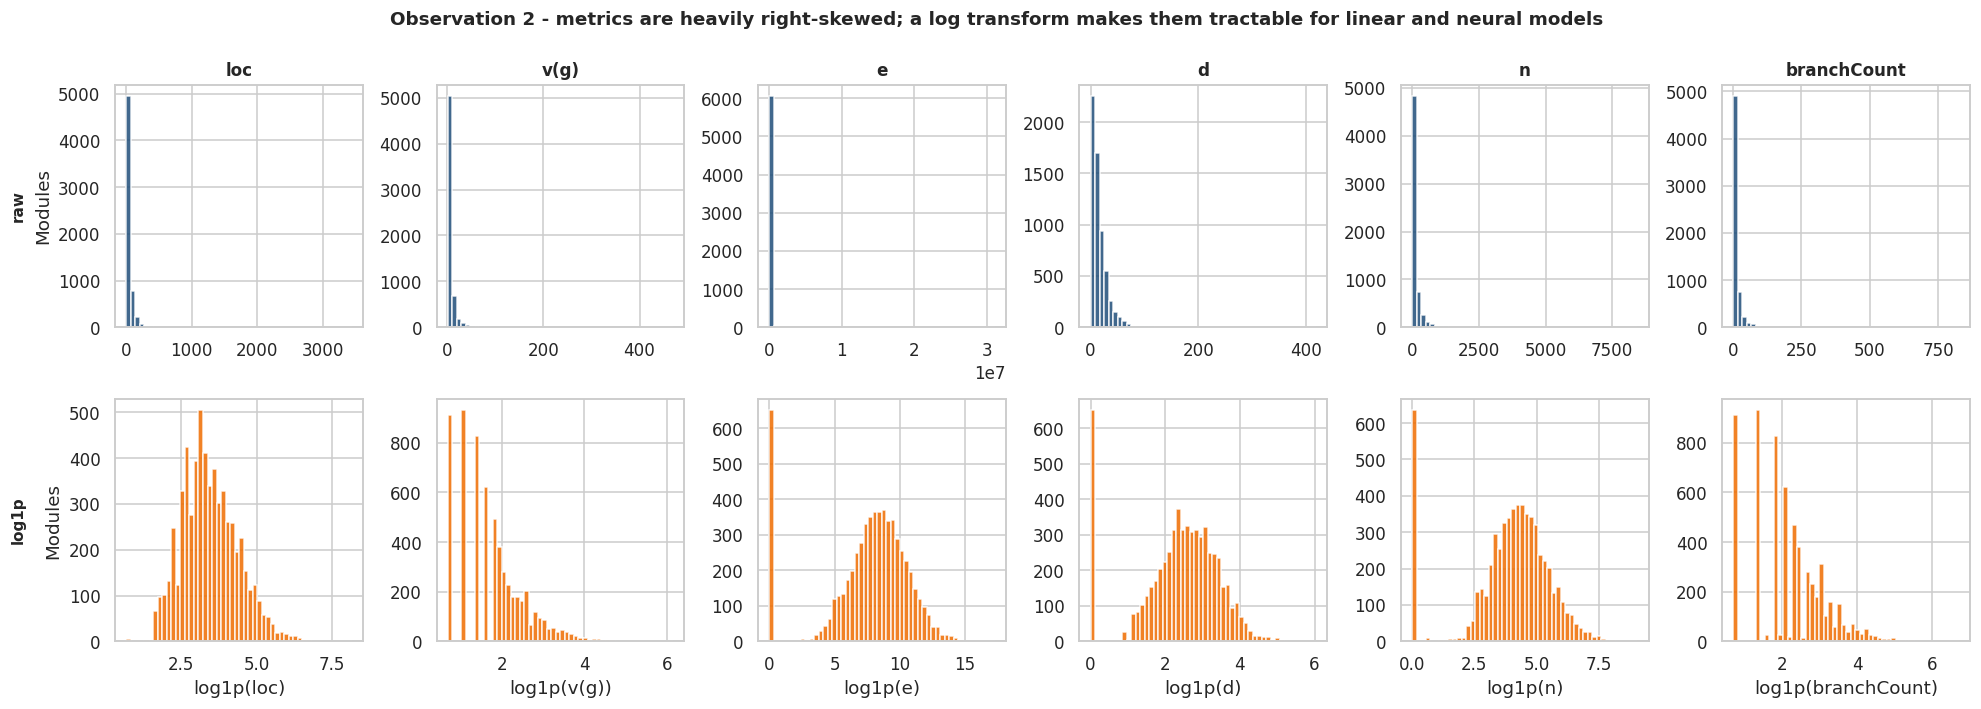

,Feature,Skewness (raw),Skewness (log1p)
0,t,52.86,-0.35
1,e,52.86,-1.03
2,lOCodeAndComment,21.63,3.21
3,iv(g),19.46,1.20
4,lOCode,18.75,-0.46
5,v,16.00,-1.22
6,b,15.99,3.29
7,loc,15.48,0.42
8,v(g),14.68,0.83
9,uniq_Op,14.22,-1.57


In [10]:
key_metrics = [c for c in ["loc", "v(g)", "e", "d", "n", "branchCount"] if c in FEATURES]

fig, axes = plt.subplots(2, len(key_metrics), figsize=(3.0 * len(key_metrics), 6.4))
for j, m in enumerate(key_metrics):
    axes[0, j].hist(X_train[m], bins=50, color=PALETTE["brand"], alpha=0.85)
    axes[0, j].set_title(m, fontsize=11)
    axes[0, j].set_ylabel("Modules" if j == 0 else "")
    axes[1, j].hist(np.log1p(X_train[m]), bins=50, color=PALETTE["accent"], alpha=0.85)
    axes[1, j].set_xlabel(f"log1p({m})")
    axes[1, j].set_ylabel("Modules" if j == 0 else "")

axes[0, 0].text(-0.42, 0.5, "raw", transform=axes[0, 0].transAxes, rotation=90,
                va="center", fontweight="bold")
axes[1, 0].text(-0.42, 0.5, "log1p", transform=axes[1, 0].transAxes, rotation=90,
                va="center", fontweight="bold")
fig.suptitle("Observation 2 - metrics are heavily right-skewed; a log transform makes them tractable "
             "for linear and neural models", fontweight="bold", y=1.00)
fig.tight_layout()
save_fig(fig, "fig02_skew",
         "Raw (top) versus log1p-transformed (bottom) distributions of the principal size, "
         "complexity and effort metrics in the training partition.")
plt.show()

skew_df = (
    X_train[FEATURES].skew().rename("Skewness (raw)").to_frame()
    .join(np.log1p(X_train[FEATURES]).skew().rename("Skewness (log1p)"))
    .sort_values("Skewness (raw)", ascending=False)
    .round(2)
    .reset_index(names="Feature")
)
save_table(skew_df, "04_skewness")
display(skew_df.head(10))

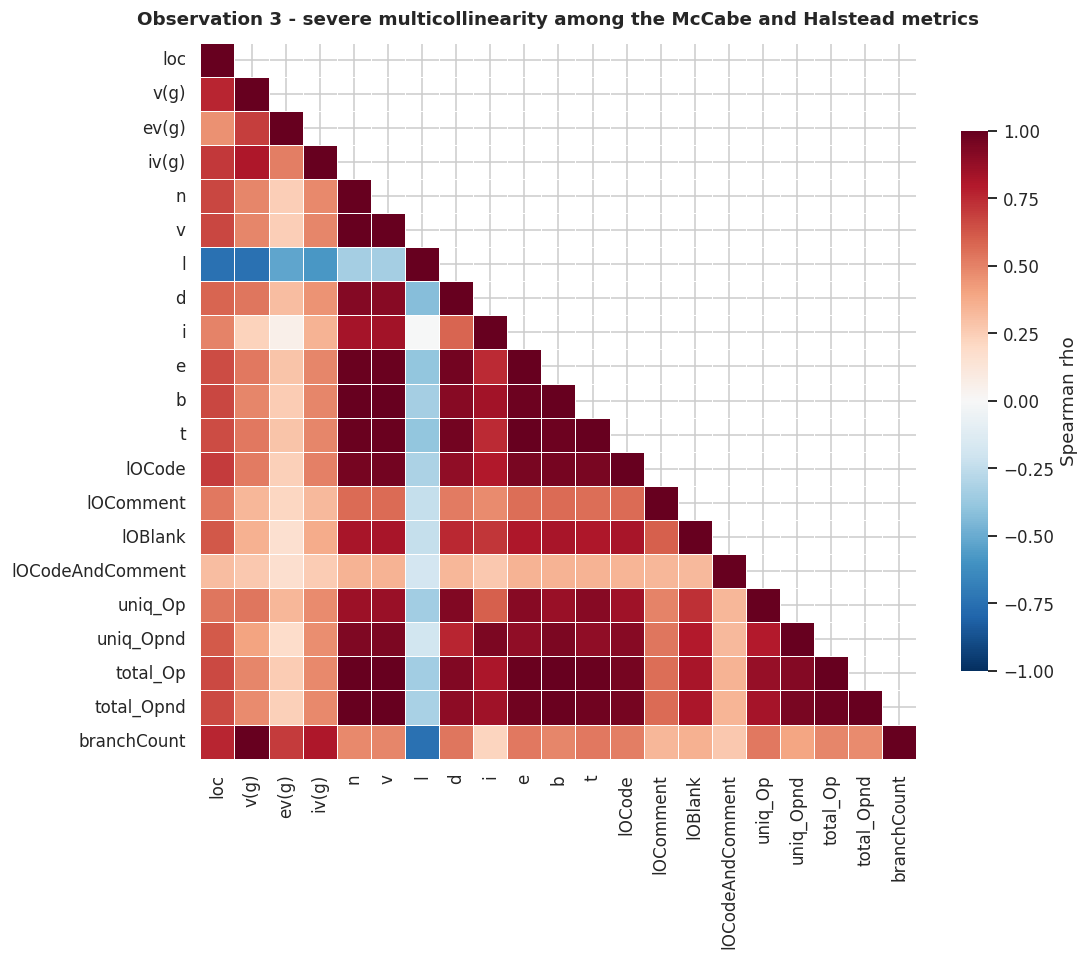

45 feature pairs exceed |rho| = 0.90 - redundancy is structural, not incidental.


,Feature A,Feature B,rho,abs_rho
145,e,t,1.000,1.000
74,n,v,0.999,0.999
94,v,b,0.998,0.998
87,n,total_Op,0.997,0.997
79,n,b,0.997,0.997
38,v(g),branchCount,0.996,0.996
102,v,total_Op,0.996,0.996
162,b,total_Op,0.994,0.994
88,n,total_Opnd,0.994,0.994
103,v,total_Opnd,0.994,0.994


In [11]:
corr = X_train[FEATURES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10.5, 8.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.75, "label": "Spearman rho"},
            annot=False, ax=ax)
ax.set_title("Observation 3 - severe multicollinearity among the McCabe and Halstead metrics",
             fontweight="bold", pad=12)
save_fig(fig, "fig03_correlation_heatmap",
         "Spearman correlation matrix of the 21 static code metrics in the training partition. "
         "The Halstead block is near-perfectly correlated because volume, effort and time are "
         "algebraic functions of the same operator and operand counts.")
plt.show()

hi = (
    corr.where(mask).stack()
    .rename("rho").reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B"})
)
hi["abs_rho"] = hi["rho"].abs()
hi = hi[hi["abs_rho"] > 0.90].sort_values("abs_rho", ascending=False).round(3)
save_table(hi, "05_high_correlation_pairs")
print(f"{len(hi)} feature pairs exceed |rho| = 0.90 - redundancy is structural, not incidental.")
display(hi.head(12))

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xv = np.log1p(X_train[FEATURES].clip(lower=0)).replace([np.inf, -np.inf], 0).fillna(0)
Xv = Xv.loc[:, Xv.std() > 1e-8]
Xv_c = (Xv - Xv.mean()) / Xv.std()
Xv_c.insert(0, "const", 1.0)

vif = pd.DataFrame(
    {
        "Feature": Xv_c.columns[1:],
        "VIF": [variance_inflation_factor(Xv_c.values, i) for i in range(1, Xv_c.shape[1])],
    }
).sort_values("VIF", ascending=False).round(1)
save_table(vif, "06_vif")

print("Variance Inflation Factor (VIF > 10 conventionally indicates serious multicollinearity)")
display(vif.head(12))
print(f"\n{(vif['VIF'] > 10).sum()} of {len(vif)} predictors exceed VIF = 10.")
print("Consequence: regularise the linear model, and prefer tree ensembles that are")
print("indifferent to correlated inputs. This is also the motivation for the PCA study in section 8.")

Variance Inflation Factor (VIF > 10 conventionally indicates serious multicollinearity)


,Feature,VIF
9,e,143116.5
7,d,54532.0
8,i,19555.0
4,n,13081.1
19,total_Opnd,5851.8
5,v,4999.3
11,t,4375.6
18,total_Op,4072.7
17,uniq_Opnd,3145.3
16,uniq_Op,1410.7



15 of 21 predictors exceed VIF = 10.
Consequence: regularise the linear model, and prefer tree ensembles that are
indifferent to correlated inputs. This is also the motivation for the PCA study in section 8.


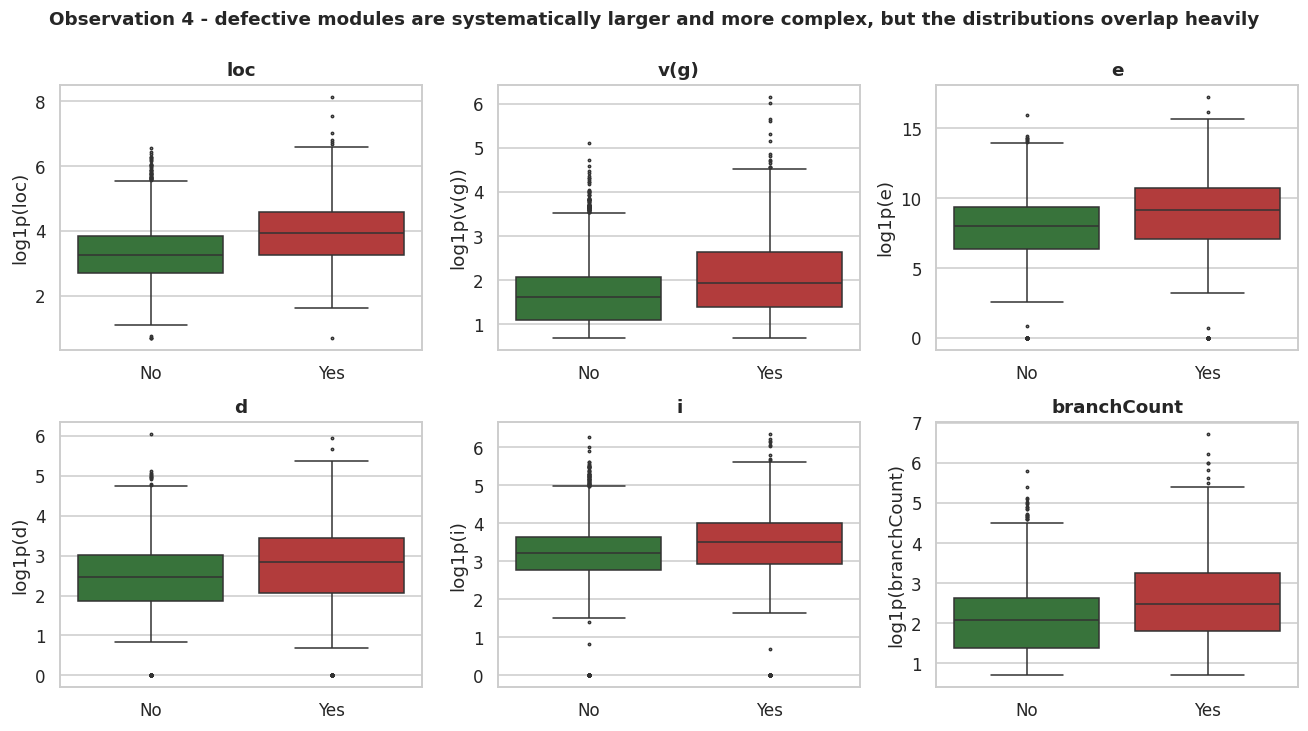

In [13]:
top6 = [c for c in ["loc", "v(g)", "e", "d", "i", "branchCount"] if c in FEATURES][:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.6))
for ax, m in zip(axes.ravel(), top6):
    plot_df = pd.DataFrame({m: np.log1p(X_train[m]), "Defective": y_train.map({0: "No", 1: "Yes"})})
    sns.boxplot(data=plot_df, x="Defective", y=m, hue="Defective", legend=False,
                palette={"No": PALETTE["ok"], "Yes": PALETTE["bad"]}, ax=ax, fliersize=1.5)
    ax.set_title(m)
    ax.set_ylabel(f"log1p({m})")
    ax.set_xlabel("")
fig.suptitle("Observation 4 - defective modules are systematically larger and more complex, "
             "but the distributions overlap heavily", fontweight="bold", y=1.00)
fig.tight_layout()
save_fig(fig, "fig04_class_separation",
         "Distribution of key metrics by defect label. The consistent upward shift for defective "
         "modules confirms signal; the large overlap explains why perfect separation is unattainable "
         "and why the model should be used to rank risk rather than to make binary go/no-go calls.")
plt.show()

---
# 5. Feature engineering, encoding and selection

## 5.1 Encoding

The 21 predictors are already numeric, so **no categorical encoding is required for the features**.
The only encoding needed is on the target: the ARFF nominal `{false, true}` is mapped to
`{0, 1}` with `1 = defective` as the positive class (done in the loader). This matters because
scikit-learn computes precision, recall and F1 with respect to the positive label.

## 5.2 Engineered density features

The raw metrics are dominated by module *size*: a big module has a big everything. Ratios express
complexity **per line**, which is what a reviewer actually reasons about, and they are far less
collinear than the raw counts.

| Engineered feature | Definition | QA meaning |
|--------------------|------------|------------|
| `complexity_density` | `v(g) / loc` | Decision points per line (branch-heavy code) |
| `essential_ratio` | `ev(g) / v(g)` | Share of complexity that is *unstructured* (cannot be decomposed) |
| `design_ratio` | `iv(g) / v(g)` | Share of complexity in the module's calling interface |
| `comment_density` | `lOComment / loc` | Documentation effort, a proxy for maintenance care |
| `volume_per_loc` | `v / loc` | Halstead volume carried per line |
| `effort_per_branch` | `e / branchCount` | Mental effort per decision point |
| `operand_ratio` | `total_Opnd / total_Op` | Data-handling versus control-handling code |
| `vocab_richness` | `(uniq_Op + uniq_Opnd) / n` | Fraction of distinct tokens; low means repetitive code |

## 5.3 Selection strategy

Three complementary filters, all fitted on the **training partition only**:

1. **Correlation pruning.** Within each cluster of features with $|\rho| > 0.95$, keep the member with
   the highest mutual information against the target.
2. **Mutual information.** Ranks features by non-linear dependence on the target.
3. **Recursive Feature Elimination with cross-validation (RFECV).** Wraps a Random Forest and
   removes the weakest feature repeatedly, choosing the subset size that maximises cross-validated PR-AUC.

In [14]:
EPS = 1e-6


def engineer(df):
    """Add size-normalised density features. Pure function of a single row - no leakage."""
    d = df.copy()
    loc = d["loc"].clip(lower=EPS)
    vg = d["v(g)"].clip(lower=EPS)
    d["complexity_density"] = d["v(g)"] / loc
    d["essential_ratio"] = d["ev(g)"] / vg
    d["design_ratio"] = d["iv(g)"] / vg
    d["comment_density"] = d["lOComment"] / loc
    d["volume_per_loc"] = d["v"] / loc
    d["effort_per_branch"] = d["e"] / d["branchCount"].clip(lower=EPS)
    d["operand_ratio"] = d["total_Opnd"] / d["total_Op"].clip(lower=EPS)
    d["vocab_richness"] = (d["uniq_Op"] + d["uniq_Opnd"]) / d["n"].clip(lower=EPS)
    return d.replace([np.inf, -np.inf], np.nan).fillna(0.0)


ENGINEERED = [
    "complexity_density", "essential_ratio", "design_ratio", "comment_density",
    "volume_per_loc", "effort_per_branch", "operand_ratio", "vocab_richness",
]

X_train_fe = engineer(X_train)
X_test_fe = engineer(X_test)
pc1_fe = engineer(pc1[FEATURES])

ALL_FEATURES = FEATURES + ENGINEERED
print(f"{len(FEATURES)} original + {len(ENGINEERED)} engineered = {len(ALL_FEATURES)} candidate features")
display(X_train_fe[ENGINEERED].describe().T.round(3))

21 original + 8 engineered = 29 candidate features


,count,mean,std,min,25%,50%,75%,max
complexity_density,6111.0,0.171,0.115,0.003,0.103,0.151,0.214,2.267
essential_ratio,6111.0,0.575,0.317,0.002,0.333,0.500,1.000,1.000
design_ratio,6111.0,0.733,0.278,0.005,0.500,0.778,1.000,1.000
comment_density,6111.0,0.049,0.087,0.000,0.000,0.000,0.074,1.818
volume_per_loc,6111.0,13.493,11.890,0.000,8.497,12.864,17.685,474.617
effort_per_branch,6111.0,2130.435,9720.961,0.000,216.820,649.214,1617.261,361750.510
operand_ratio,6111.0,0.612,0.255,0.000,0.538,0.660,0.778,1.967
vocab_richness,6111.0,0.367,0.225,0.000,0.216,0.352,0.510,2.000


In [15]:
from sklearn.feature_selection import mutual_info_classif

mi = pd.Series(
    mutual_info_classif(X_train_fe[ALL_FEATURES], y_train, random_state=RANDOM_STATE),
    index=ALL_FEATURES,
).sort_values(ascending=False)

# ---- step 1: prune clusters of near-duplicate features, keeping the most informative member
c = X_train_fe[ALL_FEATURES].corr(method="spearman").abs()
dropped, keep = {}, []
for f in mi.index:                       # walk features from most to least informative
    if f in dropped:
        continue
    keep.append(f)
    twins = c.index[(c[f] > 0.95) & (c.index != f)]
    for t in twins:
        if t not in dropped and t not in keep:
            dropped[t] = f

SELECTED_CORR = keep
prune_df = pd.DataFrame(
    [{"Dropped feature": k, "Redundant with": v, "|rho|": round(float(c.loc[k, v]), 3)}
     for k, v in dropped.items()]
).sort_values("|rho|", ascending=False)
save_table(prune_df, "07_correlation_pruning")
print(f"Correlation pruning: {len(ALL_FEATURES)} -> {len(SELECTED_CORR)} features "
      f"({len(dropped)} removed at |rho| > 0.95)")
display(prune_df)

Correlation pruning: 29 -> 20 features (9 removed at |rho| > 0.95)


,Dropped feature,Redundant with,|rho|
7,v(g),branchCount,0.996
8,lOComment,comment_density,0.972
1,v,lOCode,0.962
0,n,lOCode,0.960
3,b,lOCode,0.960
5,total_Op,lOCode,0.959
6,total_Opnd,lOCode,0.955
4,t,lOCode,0.951
2,e,lOCode,0.951


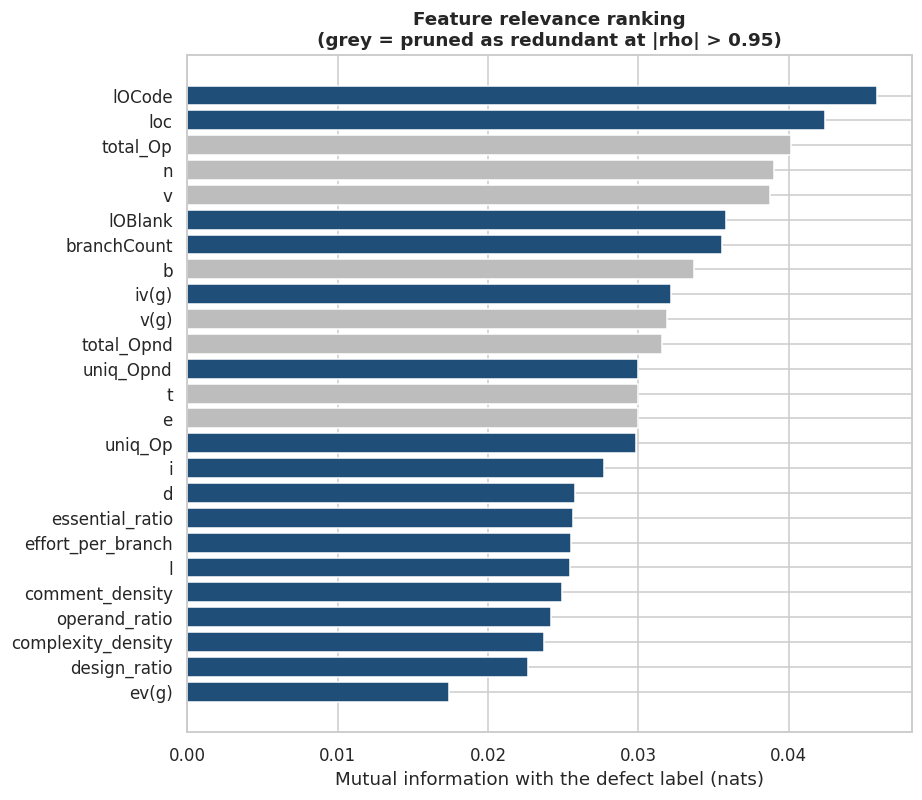

PosixPath('/content/results/08_mutual_information.csv')

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 8))
mi_plot = mi.head(25).sort_values()
colors = [PALETTE["brand"] if f in SELECTED_CORR else "#bdbdbd" for f in mi_plot.index]
ax.barh(mi_plot.index, mi_plot.values, color=colors)
ax.set_xlabel("Mutual information with the defect label (nats)")
ax.set_title("Feature relevance ranking\n(grey = pruned as redundant at |rho| > 0.95)",
             fontweight="bold")
save_fig(fig, "fig05_mutual_information",
         "Mutual information between each candidate feature and the defect label, computed on the "
         "training partition. Grey bars were removed by correlation pruning.")
plt.show()

mi_df = mi.rename_axis("Feature").reset_index(name="Mutual information").round(4)
mi_df["Retained after pruning"] = mi_df["Feature"].isin(SELECTED_CORR).map({True: "yes", False: "no"})
save_table(mi_df, "08_mutual_information")

RFECV finished in 61.0s
Optimal subset size: 20 of 20
Selected features: ['lOCode', 'loc', 'lOBlank', 'branchCount', 'iv(g)', 'uniq_Opnd', 'uniq_Op', 'i', 'd', 'essential_ratio', 'effort_per_branch', 'l', 'comment_density', 'operand_ratio', 'complexity_density', 'design_ratio', 'ev(g)', 'lOCodeAndComment', 'vocab_richness', 'volume_per_loc']


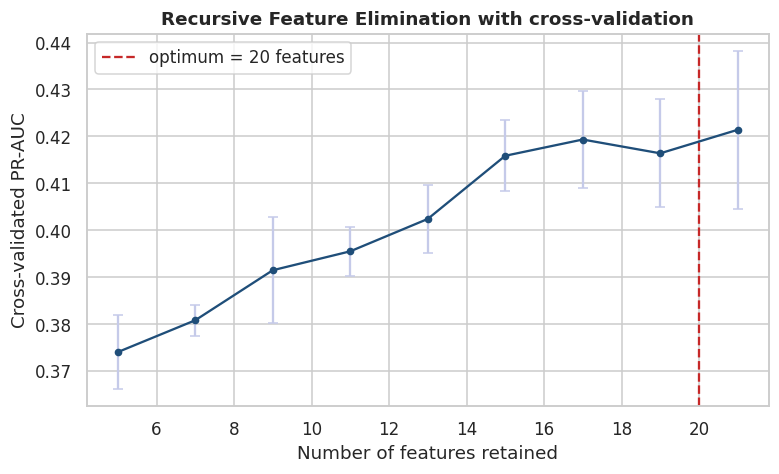

,Feature,Selected by RFECV,RFECV rank,Mutual information
0,lOCode,yes,1,0.0459
1,loc,yes,1,0.0424
2,lOBlank,yes,1,0.0358
3,branchCount,yes,1,0.0356
4,iv(g),yes,1,0.0322
5,uniq_Opnd,yes,1,0.0300
6,uniq_Op,yes,1,0.0298
7,i,yes,1,0.0277
8,d,yes,1,0.0258
9,essential_ratio,yes,1,0.0256


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV

t0 = time.time()
rfecv = RFECV(
    estimator=RandomForestClassifier(
        n_estimators=150, max_depth=12, class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    step=2,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=PRIMARY_METRIC,
    min_features_to_select=5,
    n_jobs=1,
)
rfecv.fit(X_train_fe[SELECTED_CORR], y_train)

SELECTED = [f for f, s in zip(SELECTED_CORR, rfecv.support_) if s]
print(f"RFECV finished in {time.time() - t0:.1f}s")
print(f"Optimal subset size: {rfecv.n_features_} of {len(SELECTED_CORR)}")
print(f"Selected features: {SELECTED}")

grid = rfecv.cv_results_["mean_test_score"]
sizes = rfecv.min_features_to_select + rfecv.step * np.arange(len(grid))
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.errorbar(sizes, grid, yerr=rfecv.cv_results_["std_test_score"], marker="o", ms=4,
            color=PALETTE["brand"], ecolor="#c5cae9", capsize=3)
ax.axvline(rfecv.n_features_, color=PALETTE["bad"], ls="--",
           label=f"optimum = {rfecv.n_features_} features")
ax.set_xlabel("Number of features retained")
ax.set_ylabel("Cross-validated PR-AUC")
ax.set_title("Recursive Feature Elimination with cross-validation", fontweight="bold")
ax.legend()
save_fig(fig, "fig06_rfecv",
         "RFECV curve: cross-validated PR-AUC against the number of retained features, wrapping a "
         "Random Forest. The curve is flat over a wide range, showing the signal is spread across "
         "many correlated metrics rather than concentrated in a few.")
plt.show()

sel_df = pd.DataFrame({
    "Feature": SELECTED_CORR,
    "Selected by RFECV": ["yes" if s else "no" for s in rfecv.support_],
    "RFECV rank": rfecv.ranking_,
    "Mutual information": [round(float(mi[f]), 4) for f in SELECTED_CORR],
}).sort_values(["RFECV rank", "Mutual information"], ascending=[True, False])
save_table(sel_df, "09_feature_selection")
display(sel_df)

In [18]:
# Final modelling matrices
XTR = X_train_fe[SELECTED].astype(float).reset_index(drop=True)
XTE = X_test_fe[SELECTED].astype(float).reset_index(drop=True)
XPC1 = pc1_fe[SELECTED].astype(float).reset_index(drop=True)
YTR = y_train.reset_index(drop=True)
YTE = y_test.reset_index(drop=True)
YPC1 = pc1[TARGET].astype(int).reset_index(drop=True)

print(f"Train {XTR.shape} | Test {XTE.shape} | PC1 {XPC1.shape}")
print(f"Modelling on {len(SELECTED)} features:\n  " + ", ".join(SELECTED))
FEATURE_SUMMARY = pd.DataFrame({
    "Stage": ["Raw PROMISE schema", "After cleaning", "After feature engineering",
              "After correlation pruning", "After RFECV (final)"],
    "Features": [len(CANONICAL_COLS), len(FEATURES), len(ALL_FEATURES),
                 len(SELECTED_CORR), len(SELECTED)],
})
save_table(FEATURE_SUMMARY, "10_feature_funnel")
display(FEATURE_SUMMARY)

Train (6111, 20) | Test (2620, 20) | PC1 (937, 20)
Modelling on 20 features:
  lOCode, loc, lOBlank, branchCount, iv(g), uniq_Opnd, uniq_Op, i, d, essential_ratio, effort_per_branch, l, comment_density, operand_ratio, complexity_density, design_ratio, ev(g), lOCodeAndComment, vocab_richness, volume_per_loc


,Stage,Features
0,Raw PROMISE schema,21
1,After cleaning,21
2,After feature engineering,29
3,After correlation pruning,20
4,After RFECV (final),20


---
# 6. Evaluation harness

Every model in this notebook is scored through one function, so the comparison is apples-to-apples.

| Metric | Formula | Why it is reported |
|--------|---------|--------------------|
| **PR-AUC** | area under precision-recall curve | **Primary.** Threshold-free, minority-class focused |
| **ROC-AUC** | area under ROC curve | Comparability with the published defect-prediction literature |
| **Recall (PD)** | $TP/(TP+FN)$ | Probability of detection: the share of real defects QA would be sent to |
| **Precision** | $TP/(TP+FP)$ | Share of flagged modules that truly are defective, so it controls wasted effort |
| **PF** | $FP/(FP+TN)$ | Probability of false alarm, the standard NASA-MDP cost measure |
| **F1** | harmonic mean of precision and recall | Single balanced summary |
| **G-mean** | $\sqrt{PD \times (1-PF)}$ | Balanced accuracy measure robust to imbalance |
| **MCC** | Matthews correlation | Reliable single number under class imbalance |
| **Brier** | mean squared probability error | Probability *calibration*, which matters because we rank by risk |
| **Accuracy** | $(TP+TN)/N$ | Reported for completeness, never used for selection |

In [19]:
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss, confusion_matrix,
    f1_score, matthews_corrcoef, precision_score, recall_score, roc_auc_score,
)


def evaluate(name, y_true, y_prob, threshold=0.5, extra=None):
    """Score one model. y_prob = predicted probability of the DEFECTIVE class."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pd_recall = recall_score(y_true, y_pred, zero_division=0)
    pf = fp / (fp + tn) if (fp + tn) else 0.0

    row = {
        "Model": name,
        "PR-AUC": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Recall (PD)": pd_recall,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "PF": pf,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "G-mean": float(np.sqrt(pd_recall * (1 - pf))),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Threshold": threshold,
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
    }
    if extra:
        row.update(extra)
    return row


SCORE_COLS = ["PR-AUC", "ROC-AUC", "Recall (PD)", "Precision", "PF", "F1",
              "G-mean", "MCC", "Brier", "Accuracy"]


try:                                    # probe the accessor itself - a jinja2 that is merely
    pd.DataFrame({"a": [1]}).style      # importable can still be too old for pandas' Styler
    HAS_STYLER = True
except Exception:
    HAS_STYLER = False
    print("pandas Styler unavailable - result tables will render unstyled (values are identical).")


def heat(df, higher_is_better=None, lower_is_better=()):
    """Colour-scale a results table, degrading to a plain table if the Styler is unavailable."""
    if not HAS_STYLER:
        return df.round(4)
    try:
        cols = [c for c in (higher_is_better if higher_is_better is not None else df.columns)
                if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
                and c not in lower_is_better]
        s = df.style.format({c: "{:.4f}" for c in df.columns
                             if pd.api.types.is_float_dtype(df[c])})
        if cols:
            s = s.background_gradient(subset=cols, cmap="Greens")
        low = [c for c in lower_is_better if c in df.columns]
        if low:
            s = s.background_gradient(subset=low, cmap="Reds")
        return s
    except Exception:
        return df.round(4)


def show(df, sort="PR-AUC"):
    """Pretty-print a results table sorted by the primary metric."""
    d = df.sort_values(sort, ascending=False).reset_index(drop=True)
    return heat(d, higher_is_better=[c for c in SCORE_COLS if c in d.columns],
                lower_is_better=("PF", "Brier"))


PROBAS = {}   # model name -> predicted probabilities on the hold-out test set
FITTED = {}   # model name -> fitted estimator

---
# 7. Baseline models

Six algorithms are trained with sensible defaults to establish a leaderboard *before* any tuning,
so the value added by tuning can be measured rather than assumed.

**Preprocessing is model-aware and lives inside the pipeline:**

* *Distance- and gradient-based models* (Logistic Regression, Naive Bayes, MLP) receive
  `log1p` &rarr; `StandardScaler`, because Section 4 showed skew spanning several orders of magnitude.
* *Tree-based models* (Decision Tree, Random Forest, Gradient Boosting, XGBoost) receive the raw
  features: trees split on order statistics, so monotone transforms and scaling are irrelevant.

Because the scaler sits **inside** the pipeline, it is re-fitted on each cross-validation training
fold. No statistic from a validation fold or from the hold-out test set ever informs preprocessing.

Two reference points frame the leaderboard: a **majority-class classifier** (predicts "clean"
always) and **Gaussian Naive Bayes**, which Menzies et al. (2007) reported as a surprisingly strong
performer on exactly this dataset.

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.tree import DecisionTreeClassifier

if HAS_XGB:
    from xgboost import XGBClassifier

# Named (therefore picklable) log transform - a lambda here would break joblib.dump
def log1p_clip(z):
    return np.log1p(np.clip(z, 0, None))


SCALE_PREP = [
    ("log1p", FunctionTransformer(log1p_clip, feature_names_out="one-to-one")),
    ("scale", StandardScaler()),
]


def make_pipe(estimator, scale=False, sampler=None):
    """Assemble a leakage-safe pipeline: [log1p+scale] -> [sampler] -> estimator."""
    steps = list(SCALE_PREP) if scale else []
    if sampler is not None:
        from imblearn.pipeline import Pipeline as ImbPipeline

        steps.append(("sampler", sampler))
        steps.append(("model", estimator))
        return ImbPipeline(steps)
    steps.append(("model", estimator))
    return Pipeline(steps)


SPW = float((YTR == 0).sum() / max((YTR == 1).sum(), 1))   # scale_pos_weight for XGBoost

BASELINES = {
    "Majority-class baseline": make_pipe(DummyClassifier(strategy="most_frequent")),
    "Gaussian Naive Bayes": make_pipe(GaussianNB(), scale=True),
    "Logistic Regression": make_pipe(
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
        scale=True,
    ),
    "Decision Tree": make_pipe(
        DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
    ),
    "Random Forest": make_pipe(
        RandomForestClassifier(
            n_estimators=300, class_weight="balanced_subsample",
            n_jobs=-1, random_state=RANDOM_STATE,
        )
    ),
    "Gradient Boosting": make_pipe(
        GradientBoostingClassifier(random_state=RANDOM_STATE)
    ),
}
if HAS_XGB:
    BASELINES["XGBoost"] = make_pipe(
        XGBClassifier(
            n_estimators=400, learning_rate=0.1, max_depth=5, subsample=0.9,
            colsample_bytree=0.9, scale_pos_weight=SPW, eval_metric="logloss",
            tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
        )
    )

print(f"{len(BASELINES)} baseline models | scale_pos_weight = {SPW:.2f}")

7 baseline models | scale_pos_weight = 3.56


In [21]:
from sklearn.model_selection import cross_validate

CV_SCORERS = {
    "PR-AUC": "average_precision",
    "ROC-AUC": "roc_auc",
    "Recall (PD)": "recall",
    "Precision": "precision",
    "F1": "f1",
    "MCC": "matthews_corrcoef",
}

cv_rows, CV_FOLD_SCORES = [], {}
t0 = time.time()
for name, pipe in BASELINES.items():
    res = cross_validate(pipe, XTR, YTR, cv=CV, scoring=CV_SCORERS,
                         n_jobs=-1, error_score="raise")
    CV_FOLD_SCORES[name] = res["test_PR-AUC"]
    row = {"Model": name}
    for k in CV_SCORERS:
        row[k] = res[f"test_{k}"].mean()
        row[f"{k} sd"] = res[f"test_{k}"].std()
    row["Fit time (s)"] = res["fit_time"].mean()
    cv_rows.append(row)
    print(f"  {name:26s} PR-AUC {row['PR-AUC']:.4f} +/- {row['PR-AUC sd']:.4f}"
          f"   ({res['fit_time'].mean():.2f}s/fit)")

CV_BASELINE = pd.DataFrame(cv_rows).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
save_table(CV_BASELINE.round(4), "11_baseline_cv")
print(f"\n5-fold cross-validation on the training partition finished in {time.time() - t0:.1f}s")
display(heat(CV_BASELINE.round(4), higher_is_better=list(CV_SCORERS)))

  Majority-class baseline    PR-AUC 0.2194 +/- 0.0003   (0.01s/fit)
  Gaussian Naive Bayes       PR-AUC 0.3979 +/- 0.0149   (0.02s/fit)
  Logistic Regression        PR-AUC 0.4286 +/- 0.0219   (0.06s/fit)
  Decision Tree              PR-AUC 0.2585 +/- 0.0093   (0.14s/fit)
  Random Forest              PR-AUC 0.4382 +/- 0.0095   (12.63s/fit)
  Gradient Boosting          PR-AUC 0.4295 +/- 0.0166   (5.69s/fit)
  XGBoost                    PR-AUC 0.4055 +/- 0.0159   (2.82s/fit)

5-fold cross-validation on the training partition finished in 67.9s


,Model,PR-AUC,PR-AUC sd,ROC-AUC,ROC-AUC sd,Recall (PD),Recall (PD) sd,Precision,Precision sd,F1,F1 sd,MCC,MCC sd,Fit time (s)
0,Random Forest,0.4382,0.0095,0.7237,0.0086,0.1708,0.0166,0.5604,0.0342,0.2616,0.0228,0.2206,0.0255,12.6317
1,Gradient Boosting,0.4295,0.0166,0.7162,0.0098,0.1641,0.0169,0.5824,0.0508,0.2556,0.0234,0.2246,0.0295,5.6901
2,Logistic Regression,0.4286,0.0219,0.7117,0.0148,0.6159,0.0224,0.3690,0.0156,0.4615,0.0184,0.2747,0.0270,0.0617
3,XGBoost,0.4055,0.0159,0.6998,0.0081,0.4131,0.0213,0.4164,0.0204,0.4146,0.0197,0.2510,0.0249,2.8189
4,Gaussian Naive Bayes,0.3979,0.0149,0.6825,0.0104,0.4884,0.0193,0.3638,0.0107,0.4169,0.0118,0.2254,0.0156,0.0220
5,Decision Tree,0.2585,0.0093,0.5729,0.0136,0.3222,0.0249,0.3392,0.0213,0.3304,0.0225,0.1486,0.0271,0.1386
6,Majority-class baseline,0.2194,0.0003,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0051


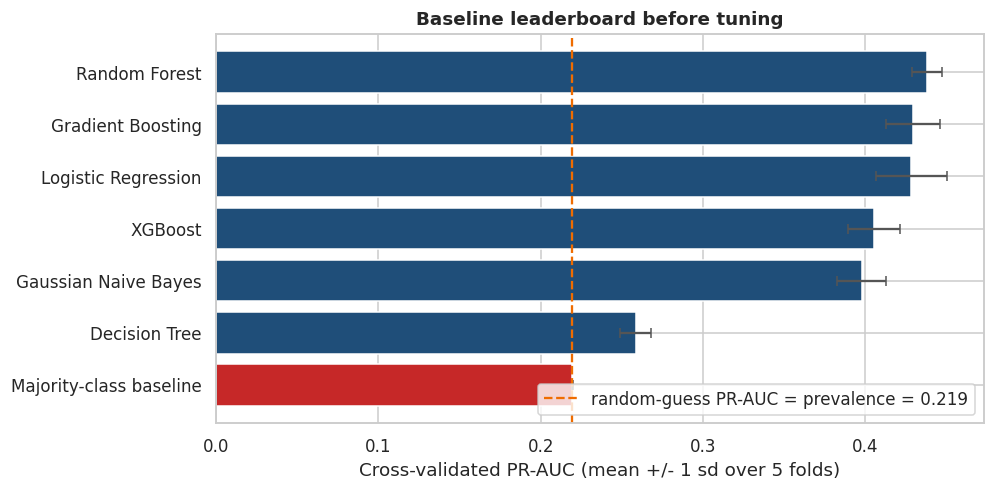

In [22]:
order = CV_BASELINE.sort_values("PR-AUC")
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(order["Model"], order["PR-AUC"], xerr=order["PR-AUC sd"],
        color=[PALETTE["bad"] if m == "Majority-class baseline" else PALETTE["brand"]
               for m in order["Model"]],
        error_kw={"ecolor": "#555", "capsize": 3})
ax.axvline(YTR.mean(), color=PALETTE["accent"], ls="--",
           label=f"random-guess PR-AUC = prevalence = {YTR.mean():.3f}")
ax.set_xlabel("Cross-validated PR-AUC (mean +/- 1 sd over 5 folds)")
ax.set_title("Baseline leaderboard before tuning", fontweight="bold")
ax.legend(loc="lower right")
save_fig(fig, "fig07_baseline_leaderboard",
         "Cross-validated PR-AUC for the six untuned baseline models on the JM1 training partition. "
         "The dashed line is the PR-AUC of random guessing, which equals the defect prevalence.")
plt.show()

---
# 8. Class-imbalance strategy

Phase 1 committed to handling the ~19 % minority class with class weights and/or SMOTE, applied to
the **training fold only**. That last clause is the critical one: resampling before the split is one
of the most common and most damaging leaks in applied ML, because SMOTE synthesises minority points
by interpolating between neighbours. If a synthetic point derived from a test module ends up in
training, the model has effectively seen the answer.

Using `imblearn.pipeline.Pipeline`, the sampler is invoked **only during `fit`** on each training
fold and is skipped during `predict`, which makes the correct behaviour structural rather than a
matter of discipline.

Four strategies are compared on the strongest tree model and on the linear baseline.

,Family,Strategy,PR-AUC,ROC-AUC,Recall (PD),Precision,F1,MCC
0,Random Forest,None (unweighted),0.4366,0.7241,0.1924,0.5324,0.2823,0.2215
1,Random Forest,Class weights,0.4364,0.7224,0.1723,0.5562,0.2630,0.2198
2,Random Forest,SMOTE (k=5),0.4390,0.7272,0.3781,0.4608,0.4151,0.2731
3,Random Forest,SMOTE + Tomek links,0.4362,0.7280,0.3870,0.4583,0.4194,0.2752
4,Random Forest,Random under-sampling,0.4292,0.7182,0.6488,0.3548,0.4587,0.2675
5,Logistic Regression,None (unweighted),0.4303,0.7109,0.1484,0.5953,0.2375,0.2180
6,Logistic Regression,Class weights,0.4286,0.7117,0.6159,0.3690,0.4615,0.2747
7,Logistic Regression,SMOTE (k=5),0.4275,0.7082,0.6144,0.3608,0.4546,0.2637
8,Logistic Regression,SMOTE + Tomek links,0.4276,0.7080,0.6159,0.3617,0.4557,0.2653
9,Logistic Regression,Random under-sampling,0.4271,0.7095,0.6144,0.3612,0.4548,0.2641


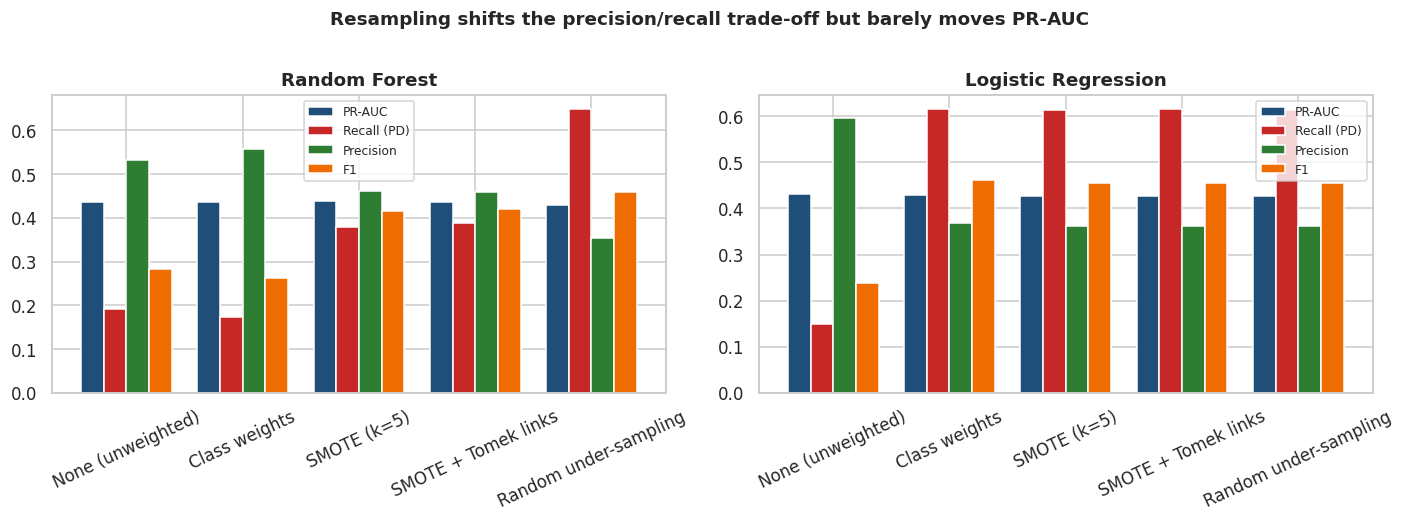


Best strategy by PR-AUC within each family:
             Family          Strategy   PR-AUC
Logistic Regression None (unweighted) 0.430295
      Random Forest       SMOTE (k=5) 0.439019

Interpretation: because PR-AUC and ROC-AUC are threshold-free, they are insensitive to
resampling - resampling mainly relocates the operating point. The honest way to buy recall
is therefore to tune the DECISION THRESHOLD against the real cost matrix (section 12),
not to distort the training distribution.


In [23]:
IMB_RESULTS = []
if HAS_IMBLEARN:
    from imblearn.combine import SMOTETomek
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler

    strategies = {
        "None (unweighted)": ("none", None),
        "Class weights": ("weight", None),
        "SMOTE (k=5)": ("none", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        "SMOTE + Tomek links": ("none", SMOTETomek(random_state=RANDOM_STATE)),
        "Random under-sampling": ("none", RandomUnderSampler(random_state=RANDOM_STATE)),
    }

    for fam in ["Random Forest", "Logistic Regression"]:
        for label, (mode, sampler) in strategies.items():
            if fam == "Random Forest":
                est = RandomForestClassifier(
                    n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE,
                    class_weight="balanced_subsample" if mode == "weight" else None,
                )
                pipe = make_pipe(est, scale=False, sampler=sampler)
            else:
                est = LogisticRegression(
                    max_iter=3000, random_state=RANDOM_STATE,
                    class_weight="balanced" if mode == "weight" else None,
                )
                pipe = make_pipe(est, scale=True, sampler=sampler)

            res = cross_validate(pipe, XTR, YTR, cv=CV, scoring=CV_SCORERS, n_jobs=-1)
            IMB_RESULTS.append({
                "Family": fam, "Strategy": label,
                **{k: res[f"test_{k}"].mean() for k in CV_SCORERS},
            })

    IMB_DF = pd.DataFrame(IMB_RESULTS)
    save_table(IMB_DF.round(4), "12_imbalance_strategies")
    display(heat(IMB_DF.round(4), higher_is_better=list(CV_SCORERS)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=False)
    for ax, fam in zip(axes, ["Random Forest", "Logistic Regression"]):
        sub = IMB_DF[IMB_DF["Family"] == fam].set_index("Strategy")
        sub[["PR-AUC", "Recall (PD)", "Precision", "F1"]].plot(
            kind="bar", ax=ax, width=0.78,
            color=[PALETTE["brand"], PALETTE["bad"], PALETTE["ok"], PALETTE["accent"]])
        ax.set_title(fam)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)
        ax.legend(fontsize=8)
    fig.suptitle("Resampling shifts the precision/recall trade-off but barely moves PR-AUC",
                 fontweight="bold", y=1.02)
    fig.tight_layout()
    save_fig(fig, "fig08_imbalance",
             "Effect of five class-imbalance strategies, each applied inside the cross-validation "
             "loop on training folds only. Oversampling buys recall at the cost of precision; the "
             "threshold-free PR-AUC is largely unchanged.")
    plt.show()

    best_imb = IMB_DF.loc[IMB_DF.groupby("Family")["PR-AUC"].idxmax(), ["Family", "Strategy", "PR-AUC"]]
    print("\nBest strategy by PR-AUC within each family:")
    print(best_imb.to_string(index=False))
    print("\nInterpretation: because PR-AUC and ROC-AUC are threshold-free, they are insensitive to")
    print("resampling - resampling mainly relocates the operating point. The honest way to buy recall")
    print("is therefore to tune the DECISION THRESHOLD against the real cost matrix (section 12),")
    print("not to distort the training distribution.")
else:
    print("imbalanced-learn unavailable - class-weighting is used throughout instead.")

---
# 9. Hyperparameter tuning

Three complementary tuning techniques are used, as the assignment requires:

| Technique | Applied to | Why this technique |
|-----------|-----------|--------------------|
| **GridSearchCV** | Logistic Regression | Small, well-understood, essentially 2-D space, so exhaustive search is cheap and complete |
| **RandomizedSearchCV** | Random Forest, Gradient Boosting, XGBoost | Large mixed continuous/discrete space; random search reaches good regions far more efficiently than a grid of equal budget (Bergstra & Bengio, 2012) |
| **Validation curves** | Random Forest depth and ensemble size | Shows *why* a value was chosen, making the bias/variance trade-off visible rather than implicit |

All searches optimise **PR-AUC** under the same `StratifiedKFold(5)`, refit the best configuration on
the full training partition, and never touch the hold-out test set.

In [24]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform

TUNED, SEARCHES = {}, {}

# ---------------------------------------------------------------- GridSearchCV
t0 = time.time()
lr_grid = {
    "model__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"],
}
gs_lr = GridSearchCV(
    make_pipe(LogisticRegression(max_iter=4000, random_state=RANDOM_STATE), scale=True),
    lr_grid, scoring=PRIMARY_METRIC, cv=CV, n_jobs=-1, refit=True, error_score=0.0,
)
gs_lr.fit(XTR, YTR)
TUNED["Logistic Regression (tuned)"] = gs_lr.best_estimator_
SEARCHES["Logistic Regression"] = gs_lr
print(f"GridSearchCV  | Logistic Regression | {len(gs_lr.cv_results_['params'])} candidates "
      f"x 5 folds in {time.time() - t0:.1f}s")
print(f"  best PR-AUC {gs_lr.best_score_:.4f}  params {gs_lr.best_params_}")

GridSearchCV  | Logistic Regression | 36 candidates x 5 folds in 24.8s
  best PR-AUC 0.4318  params {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [25]:
# ---------------------------------------------------- RandomizedSearchCV - RF
t0 = time.time()
rf_space = {
    "model__n_estimators": randint(120, 350),
    "model__max_depth": [None, 6, 8, 10, 14, 18, 24],
    "model__min_samples_split": randint(2, 40),
    "model__min_samples_leaf": randint(1, 25),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
    "model__criterion": ["gini", "entropy"],
}
# n_jobs=1 on the forest: the SEARCH is parallelised instead, so the cores are not
# oversubscribed by nested parallelism (which makes the search several times slower).
rs_rf = RandomizedSearchCV(
    make_pipe(RandomForestClassifier(n_jobs=1, random_state=RANDOM_STATE)),
    rf_space, n_iter=20, scoring=PRIMARY_METRIC, cv=CV,
    n_jobs=-1, random_state=RANDOM_STATE, refit=True,
)
rs_rf.fit(XTR, YTR)
TUNED["Random Forest (tuned)"] = rs_rf.best_estimator_
SEARCHES["Random Forest"] = rs_rf
print(f"RandomizedSearchCV | Random Forest | 20 candidates x 5 folds in {time.time() - t0:.1f}s")
print(f"  best PR-AUC {rs_rf.best_score_:.4f}")
for k, v in rs_rf.best_params_.items():
    print(f"    {k.replace('model__', ''):20s} {v}")

RandomizedSearchCV | Random Forest | 20 candidates x 5 folds in 457.4s
  best PR-AUC 0.4468
    class_weight         None
    criterion            entropy
    max_depth            18
    max_features         log2
    min_samples_leaf     9
    min_samples_split    27
    n_estimators         172


In [26]:
# --------------------------------------------------- RandomizedSearchCV - GBM
t0 = time.time()
if HAS_XGB:
    xgb_space = {
        "model__n_estimators": randint(200, 700),
        "model__max_depth": randint(2, 9),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.5, 0.5),
        "model__min_child_weight": randint(1, 12),
        "model__gamma": uniform(0, 4),
        "model__reg_lambda": loguniform(0.5, 20),
        "model__scale_pos_weight": [1.0, SPW ** 0.5, SPW],
    }
    rs_gb = RandomizedSearchCV(
        make_pipe(XGBClassifier(eval_metric="logloss", tree_method="hist",
                                n_jobs=1, random_state=RANDOM_STATE)),
        xgb_space, n_iter=30, scoring=PRIMARY_METRIC, cv=CV,
        n_jobs=-1, random_state=RANDOM_STATE, refit=True,
    )
    gb_label = "XGBoost (tuned)"
else:
    gb_space = {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(2, 7),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__subsample": uniform(0.6, 0.4),
        "model__min_samples_leaf": randint(1, 30),
    }
    rs_gb = RandomizedSearchCV(
        make_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE)),
        gb_space, n_iter=25, scoring=PRIMARY_METRIC, cv=CV,
        n_jobs=-1, random_state=RANDOM_STATE, refit=True,
    )
    gb_label = "Gradient Boosting (tuned)"

rs_gb.fit(XTR, YTR)
TUNED[gb_label] = rs_gb.best_estimator_
SEARCHES[gb_label.replace(" (tuned)", "")] = rs_gb
print(f"RandomizedSearchCV | {gb_label} in {time.time() - t0:.1f}s")
print(f"  best PR-AUC {rs_gb.best_score_:.4f}")
for k, v in rs_gb.best_params_.items():
    print(f"    {k.replace('model__', ''):20s} {v if not isinstance(v, float) else round(v, 4)}")

RandomizedSearchCV | XGBoost (tuned) in 92.1s
  best PR-AUC 0.4369
    colsample_bytree     0.7138
    gamma                0.1017
    learning_rate        0.0144
    max_depth            8
    min_child_weight     7
    n_estimators         440
    reg_lambda           1.5944
    scale_pos_weight     1.886
    subsample            0.6557


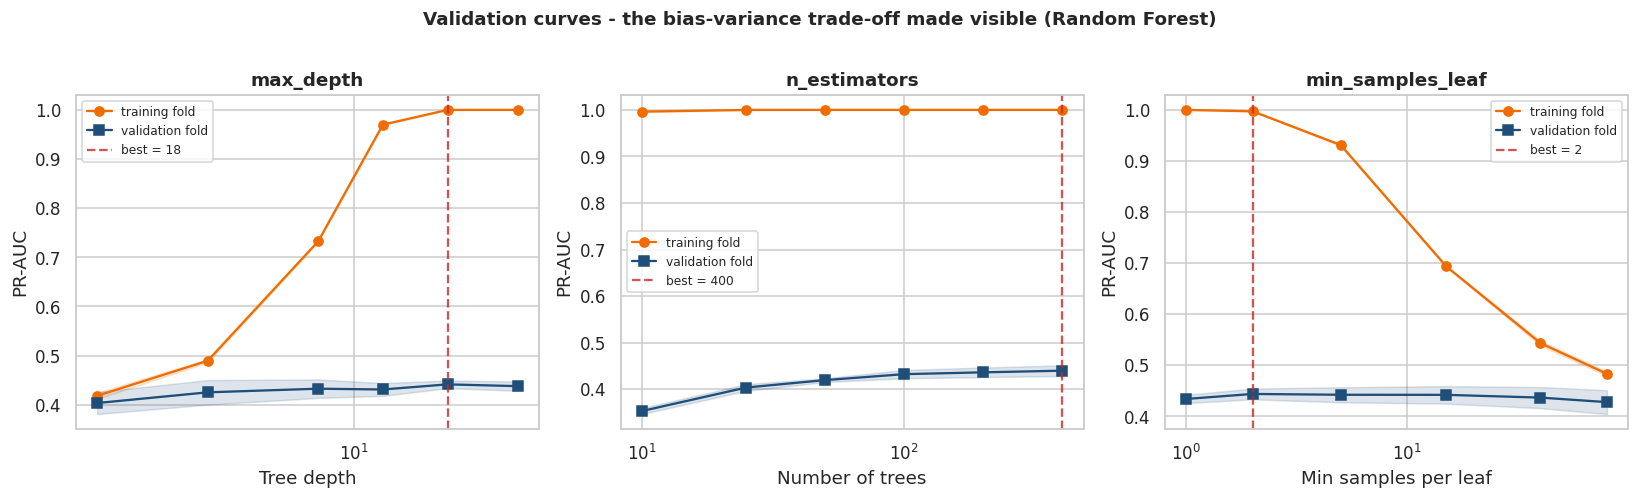

,Parameter,Value,Train PR-AUC,Validation PR-AUC,Gap (overfit)
0,max_depth,2,0.4183,0.4035,0.0147
1,max_depth,4,0.4895,0.4253,0.0642
2,max_depth,8,0.7325,0.4327,0.2998
3,max_depth,12,0.9699,0.4311,0.5388
4,max_depth,18,1.0000,0.4415,0.5585
5,max_depth,28,1.0000,0.4379,0.5621
6,n_estimators,10,0.9962,0.3531,0.6431
7,n_estimators,25,0.9999,0.4037,0.5962
8,n_estimators,50,1.0000,0.4197,0.5803
9,n_estimators,100,1.0000,0.4325,0.5675


In [27]:
from sklearn.model_selection import validation_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
vc_specs = [
    ("model__max_depth", [2, 4, 8, 12, 18, 28], "Tree depth", True),
    ("model__n_estimators", [10, 25, 50, 100, 200, 400], "Number of trees", True),
    ("model__min_samples_leaf", [1, 2, 5, 15, 40, 80], "Min samples per leaf", True),
]
VC_TABLES = []
for ax, (param, rng, xlabel, logx) in zip(axes, vc_specs):
    tr, va = validation_curve(
        make_pipe(RandomForestClassifier(
            n_estimators=150, class_weight="balanced_subsample",
            n_jobs=1, random_state=RANDOM_STATE)),
        XTR, YTR, param_name=param, param_range=rng,
        cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1,
    )
    xs = np.array([r if r is not None else max(rng[:-1]) for r in rng], dtype=float)
    ax.plot(xs, tr.mean(1), "o-", color=PALETTE["accent"], label="training fold")
    ax.fill_between(xs, tr.mean(1) - tr.std(1), tr.mean(1) + tr.std(1),
                    color=PALETTE["accent"], alpha=0.15)
    ax.plot(xs, va.mean(1), "s-", color=PALETTE["brand"], label="validation fold")
    ax.fill_between(xs, va.mean(1) - va.std(1), va.mean(1) + va.std(1),
                    color=PALETTE["brand"], alpha=0.15)
    best = xs[va.mean(1).argmax()]
    ax.axvline(best, ls="--", color=PALETTE["bad"], alpha=0.8,
               label=f"best = {best:g}")
    if logx:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PR-AUC")
    ax.set_title(param.replace("model__", ""))
    ax.legend(fontsize=8)
    VC_TABLES.append(pd.DataFrame({
        "Parameter": param.replace("model__", ""), "Value": [str(r) for r in rng],
        "Train PR-AUC": tr.mean(1).round(4), "Validation PR-AUC": va.mean(1).round(4),
        "Gap (overfit)": (tr.mean(1) - va.mean(1)).round(4),
    }))

fig.suptitle("Validation curves - the bias-variance trade-off made visible (Random Forest)",
             fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "fig09_validation_curves",
         "Validation curves for Random Forest depth, ensemble size and leaf size. The widening gap "
         "between training and validation scores as depth grows is overfitting; the validation "
         "curve is what the tuning objective actually maximises.")
plt.show()

VC_DF = pd.concat(VC_TABLES, ignore_index=True)
save_table(VC_DF, "13_validation_curves")
display(VC_DF)

In [28]:
# tuning gain: does searching actually help?
gain_rows = []
for label, search in SEARCHES.items():
    base_name = {"Logistic Regression": "Logistic Regression",
                 "Random Forest": "Random Forest",
                 "XGBoost": "XGBoost",
                 "Gradient Boosting": "Gradient Boosting"}.get(label, label)
    base = CV_BASELINE.loc[CV_BASELINE["Model"] == base_name, "PR-AUC"]
    base_val = float(base.iloc[0]) if len(base) else np.nan
    gain_rows.append({
        "Model": label,
        "Search": "GridSearchCV" if isinstance(search, GridSearchCV) else "RandomizedSearchCV",
        "Candidates": len(search.cv_results_["params"]),
        "Untuned CV PR-AUC": base_val,
        "Tuned CV PR-AUC": search.best_score_,
        "Absolute gain": search.best_score_ - base_val,
        "Relative gain %": 100 * (search.best_score_ - base_val) / base_val if base_val == base_val else np.nan,
    })
TUNING_GAIN = pd.DataFrame(gain_rows).round(4)
save_table(TUNING_GAIN, "14_tuning_gain")
display(TUNING_GAIN)
BEST_PARAMS = {k: {kk.replace("model__", ""): (round(vv, 5) if isinstance(vv, float) else str(vv))
                   for kk, vv in v.best_params_.items()} for k, v in SEARCHES.items()}
(RES_DIR / "best_params.json").write_text(json.dumps(BEST_PARAMS, indent=2))
print(json.dumps(BEST_PARAMS, indent=2))

,Model,Search,Candidates,Untuned CV PR-AUC,Tuned CV PR-AUC,Absolute gain,Relative gain %
0,Logistic Regression,GridSearchCV,36,0.4286,0.4318,0.0032,0.7473
1,Random Forest,RandomizedSearchCV,20,0.4382,0.4468,0.0086,1.9628
2,XGBoost,RandomizedSearchCV,30,0.4055,0.4369,0.0314,7.7537


{
  "Logistic Regression": {
    "C": 0.1,
    "class_weight": "None",
    "penalty": "l2",
    "solver": "liblinear"
  },
  "Random Forest": {
    "class_weight": "None",
    "criterion": "entropy",
    "max_depth": "18",
    "max_features": "log2",
    "min_samples_leaf": "9",
    "min_samples_split": "27",
    "n_estimators": "172"
  },
  "XGBoost": {
    "colsample_bytree": 0.71377,
    "gamma": 0.10168,
    "learning_rate": 0.01443,
    "max_depth": "8",
    "min_child_weight": "7",
    "n_estimators": "440",
    "reg_lambda": 1.59436,
    "scale_pos_weight": 1.88601,
    "subsample": 0.65573
  }
}


---
# 10. Dimensionality reduction with PCA

Section 4 established that the McCabe and Halstead metrics are algebraically entangled, because volume,
effort and time are all functions of the same operator and operand counts. PCA is therefore the
natural diagnostic: it answers *how many genuinely independent dimensions of variation does a
module have?*

PCA sits **inside the pipeline**, after `log1p` and `StandardScaler` (PCA is variance-based, so it
must operate on standardised inputs), and is fitted on training folds only.

Two questions are answered:

1. **How much redundancy is there?** The explained-variance curve answers this.
2. **Does compressing help or hurt prediction?** PR-AUC against the number of components answers this.

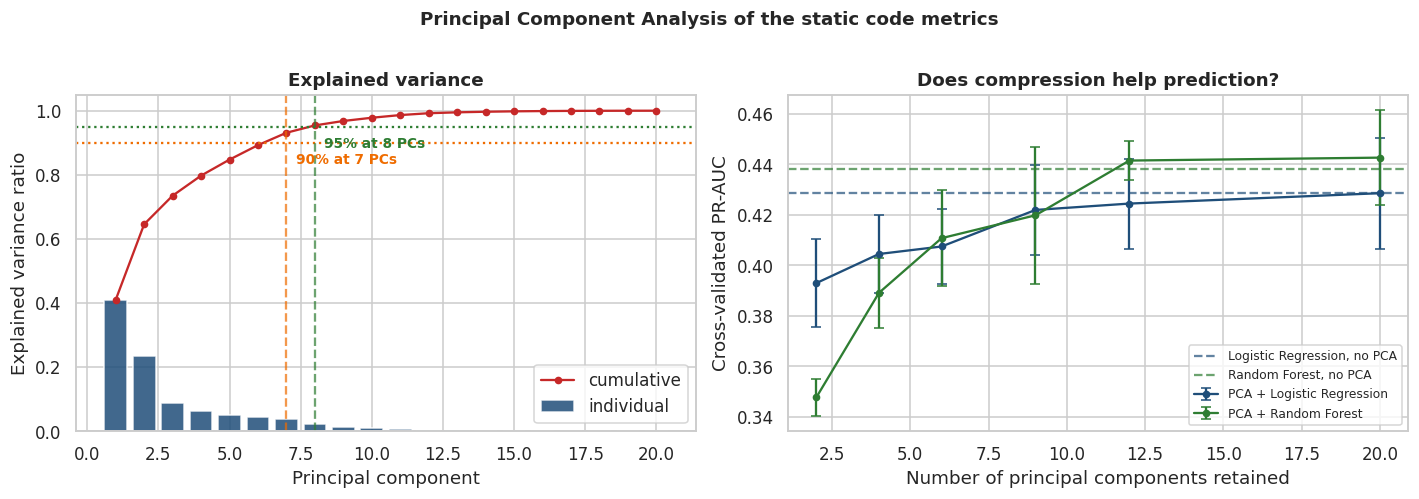

20 engineered features collapse to 7 components at 90% variance and 8 at 95%.
The first component alone explains 41.0% of total variance - it is essentially a 'module size' factor.

Best component count per model family:
 Components               Model  PR-AUC     sd
         20 Logistic Regression  0.4286 0.0220
         20       Random Forest  0.4427 0.0189


In [29]:
from sklearn.decomposition import PCA

pca_probe = Pipeline(SCALE_PREP + [("pca", PCA(random_state=RANDOM_STATE))]).fit(XTR)
evr = pca_probe.named_steps["pca"].explained_variance_ratio_
cum = np.cumsum(evr)
n90 = int(np.searchsorted(cum, 0.90) + 1)
n95 = int(np.searchsorted(cum, 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].bar(range(1, len(evr) + 1), evr, color=PALETTE["brand"], alpha=0.85, label="individual")
axes[0].plot(range(1, len(cum) + 1), cum, "o-", color=PALETTE["bad"], ms=4, label="cumulative")
for thr, n_, col in [(0.90, n90, PALETTE["accent"]), (0.95, n95, PALETTE["ok"])]:
    axes[0].axhline(thr, ls=":", color=col)
    axes[0].axvline(n_, ls="--", color=col, alpha=0.7)
    axes[0].annotate(f"{int(thr * 100)}% at {n_} PCs", (n_, thr), textcoords="offset points",
                     xytext=(6, -14), color=col, fontsize=9, fontweight="bold")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Explained variance")
axes[0].legend()

comp_range = [2, 4, 6, 9, min(12, len(SELECTED)), len(SELECTED)]
comp_range = sorted({c for c in comp_range if 1 <= c <= len(SELECTED)})
pca_rows = []
for k in comp_range:
    for label, est, scale in [
        ("Logistic Regression", LogisticRegression(max_iter=3000, class_weight="balanced",
                                                   random_state=RANDOM_STATE), True),
        ("Random Forest", RandomForestClassifier(n_estimators=150, class_weight="balanced_subsample",
                                                 n_jobs=1, random_state=RANDOM_STATE), True),
    ]:
        pipe = Pipeline(SCALE_PREP + [("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
                                      ("model", est)])
        sc = cross_validate(pipe, XTR, YTR, cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1)
        pca_rows.append({"Components": k, "Model": label,
                         "PR-AUC": sc["test_score"].mean(), "sd": sc["test_score"].std()})

PCA_DF = pd.DataFrame(pca_rows)
for label, colr in [("Logistic Regression", PALETTE["brand"]), ("Random Forest", PALETTE["ok"])]:
    s = PCA_DF[PCA_DF["Model"] == label]
    axes[1].errorbar(s["Components"], s["PR-AUC"], yerr=s["sd"], marker="o", ms=4,
                     capsize=3, label=f"PCA + {label}", color=colr)
    full = CV_BASELINE.loc[CV_BASELINE["Model"] == label, "PR-AUC"]
    if len(full):
        axes[1].axhline(float(full.iloc[0]), ls="--", alpha=0.7, color=colr,
                        label=f"{label}, no PCA")
axes[1].set_xlabel("Number of principal components retained")
axes[1].set_ylabel("Cross-validated PR-AUC")
axes[1].set_title("Does compression help prediction?")
axes[1].legend(fontsize=8)
fig.suptitle("Principal Component Analysis of the static code metrics", fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "fig10_pca",
         "Left: explained-variance and cumulative-variance curves. Right: cross-validated PR-AUC "
         "against the number of retained components, with the uncompressed models as reference lines.")
plt.show()

save_table(PCA_DF.round(4), "15_pca_sweep")
PCA_SUMMARY = {"n_components_90": n90, "n_components_95": n95,
               "n_features": len(SELECTED), "pc1_variance": float(evr[0])}
print(f"{len(SELECTED)} engineered features collapse to {n90} components at 90% variance "
      f"and {n95} at 95%.")
print(f"The first component alone explains {evr[0]:.1%} of total variance - it is essentially a "
      f"'module size' factor.")
best_pca = PCA_DF.loc[PCA_DF.groupby("Model")["PR-AUC"].idxmax()]
print("\nBest component count per model family:")
print(best_pca.round(4).to_string(index=False))

TUNED["PCA + Logistic Regression"] = Pipeline(
    SCALE_PREP + [("pca", PCA(n_components=n95, random_state=RANDOM_STATE)),
                  ("model", LogisticRegression(max_iter=3000, class_weight="balanced",
                                               random_state=RANDOM_STATE))]
).fit(XTR, YTR)

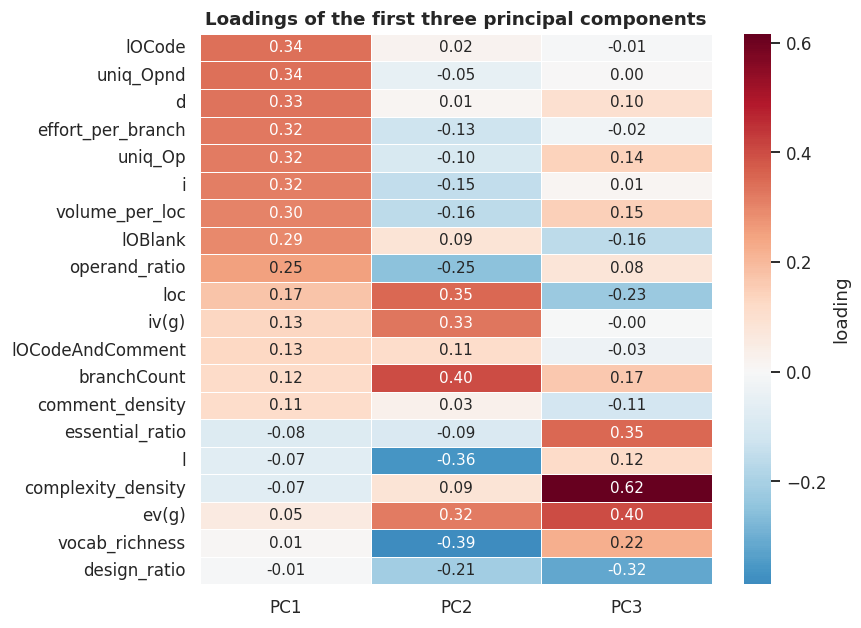

In [30]:
# PCA loadings: what does the dominant component actually measure?
load = pd.DataFrame(
    pca_probe.named_steps["pca"].components_[:3].T,
    index=SELECTED, columns=["PC1", "PC2", "PC3"],
).round(3)
load["|PC1|"] = load["PC1"].abs()
load = load.sort_values("|PC1|", ascending=False).drop(columns="|PC1|")
save_table(load.reset_index(names="Feature"), "16_pca_loadings")
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(load, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            linewidths=0.4, cbar_kws={"label": "loading"}, ax=ax)
ax.set_title("Loadings of the first three principal components", fontweight="bold")
save_fig(fig, "fig11_pca_loadings",
         "Feature loadings on the first three principal components. PC1 loads uniformly on all size "
         "and volume metrics, confirming it is a latent 'module size' factor.")
plt.show()

---
# 11. Deep learning: Keras Multi-Layer Perceptron

Phase 1 proposed a feed-forward network as the deep-learning counterpart, with an honest caveat:
*on small tabular datasets, tree ensembles frequently match or beat shallow neural networks.*
That claim is now tested rather than assumed.

**Architecture and training choices, and the reason for each:**

| Choice | Value | Reason |
|--------|-------|--------|
| Input preprocessing | `log1p` + `StandardScaler` | Gradient descent is scale-sensitive; raw effort values span ~7 orders of magnitude |
| Hidden layers | 64 &rarr; 32 &rarr; 16, ReLU | Enough capacity for interactions, small enough for ~7 k training rows |
| Regularisation | Batch-norm + dropout 0.3 + L2 1e-4 | The dataset is small and noisy; the network overfits within a few epochs otherwise |
| Output | 1 unit, sigmoid | Binary probability of defect |
| Loss | Binary cross-entropy with **class weights** | Restores the minority class's influence on the gradient |
| Optimiser | Adam, lr 1e-3 | Standard, robust default |
| Early stopping | patience 15 on validation PR-AUC, restore best weights | Selects epoch count by validation performance instead of guessing |
| Validation split | 15 % of the **training** partition | The hold-out test set is never used for early stopping |

A small architecture search over width, dropout and learning rate is run so the network gets the
same tuning courtesy as the tree models. A comparison between a tuned forest and an untuned
network would not be a fair test.

In [31]:
DL_HISTORY, DL_SEARCH = None, pd.DataFrame()

if HAS_TF:
    from tensorflow import keras
    from tensorflow.keras import layers, regularizers

    scaler_dl = Pipeline(SCALE_PREP).fit(XTR)
    XTR_s = scaler_dl.transform(XTR).astype("float32")
    XTE_s = scaler_dl.transform(XTE).astype("float32")
    XPC1_s = scaler_dl.transform(XPC1).astype("float32")

    cw = {0: 1.0, 1: float((YTR == 0).sum() / max((YTR == 1).sum(), 1))}
    print(f"Class weights for the network: {{0: 1.00, 1: {cw[1]:.2f}}}")

    def build_mlp(units=(64, 32, 16), dropout=0.3, lr=1e-3, l2=1e-4, n_in=None):
        keras.utils.set_random_seed(RANDOM_STATE)
        m = keras.Sequential([keras.layers.Input(shape=(n_in,))], name="defect_mlp")
        for u in units:
            m.add(layers.Dense(u, activation="relu",
                               kernel_regularizer=regularizers.l2(l2)))
            m.add(layers.BatchNormalization())
            m.add(layers.Dropout(dropout))
        m.add(layers.Dense(1, activation="sigmoid"))
        m.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss="binary_crossentropy",
            metrics=[keras.metrics.AUC(curve="PR", name="pr_auc"),
                     keras.metrics.AUC(name="roc_auc"),
                     keras.metrics.Recall(name="recall")],
        )
        return m

    def fit_mlp(units, dropout, lr, epochs=120, verbose=0):
        m = build_mlp(units, dropout, lr, n_in=XTR_s.shape[1])
        es = keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=15,
                                           restore_best_weights=True, verbose=0)
        rl = keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5,
                                               patience=7, min_lr=1e-5, verbose=0)
        h = m.fit(XTR_s, YTR.values, validation_split=0.15, epochs=epochs, batch_size=128,
                  class_weight=cw, callbacks=[es, rl], verbose=verbose, shuffle=True)
        return m, h

    # -------- small architecture search
    t0 = time.time()
    grid = [((32, 16), 0.2, 1e-3), ((64, 32), 0.3, 1e-3), ((64, 32, 16), 0.3, 1e-3),
            ((128, 64, 32), 0.4, 1e-3), ((64, 32, 16), 0.2, 3e-4)]
    rows = []
    for units, dr, lr in grid:
        m, h = fit_mlp(units, dr, lr, epochs=70)
        best = float(np.max(h.history["val_pr_auc"]))
        rows.append({"Architecture": " - ".join(map(str, units)), "Dropout": dr,
                     "Learning rate": lr, "Epochs run": len(h.history["loss"]),
                     "Best val PR-AUC": best})
        print(f"  {str(units):16s} dropout={dr} lr={lr:<7g} -> val PR-AUC {best:.4f} "
              f"({len(h.history['loss'])} epochs)")
    DL_SEARCH = pd.DataFrame(rows).sort_values("Best val PR-AUC", ascending=False)
    save_table(DL_SEARCH.round(4), "17_mlp_architecture_search")

    best_cfg = grid[int(DL_SEARCH.index[0])]
    print(f"\nBest architecture: {best_cfg[0]}, dropout {best_cfg[1]}, lr {best_cfg[2]} "
          f"(search took {time.time() - t0:.1f}s)")
    MLP, DL_HISTORY = fit_mlp(*best_cfg, epochs=150)
    MLP.summary()
    display(DL_SEARCH.round(4))
else:
    print("TensorFlow unavailable - falling back to scikit-learn MLPClassifier.")
    from sklearn.neural_network import MLPClassifier

    TUNED["Neural Network (MLP)"] = make_pipe(
        MLPClassifier(hidden_layer_sizes=(64, 32, 16), alpha=1e-4, max_iter=600,
                      early_stopping=True, n_iter_no_change=15, random_state=RANDOM_STATE),
        scale=True,
    ).fit(XTR, YTR)

Class weights for the network: {0: 1.00, 1: 3.56}
  (32, 16)         dropout=0.2 lr=0.001   -> val PR-AUC 0.4181 (70 epochs)
  (64, 32)         dropout=0.3 lr=0.001   -> val PR-AUC 0.4518 (38 epochs)
  (64, 32, 16)     dropout=0.3 lr=0.001   -> val PR-AUC 0.4416 (22 epochs)
  (128, 64, 32)    dropout=0.4 lr=0.001   -> val PR-AUC 0.4382 (70 epochs)
  (64, 32, 16)     dropout=0.2 lr=0.0003  -> val PR-AUC 0.4430 (45 epochs)

Best architecture: (64, 32), dropout 0.3, lr 0.001 (search took 107.1s)


Model: "defect_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,141 (43.52 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 7,300 (28.52 KB)

,Architecture,Dropout,Learning rate,Epochs run,Best val PR-AUC
1,64 - 32,0.3,0.0010,38,0.4518
4,64 - 32 - 16,0.2,0.0003,45,0.4430
2,64 - 32 - 16,0.3,0.0010,22,0.4416
3,128 - 64 - 32,0.4,0.0010,70,0.4382
0,32 - 16,0.2,0.0010,70,0.4181


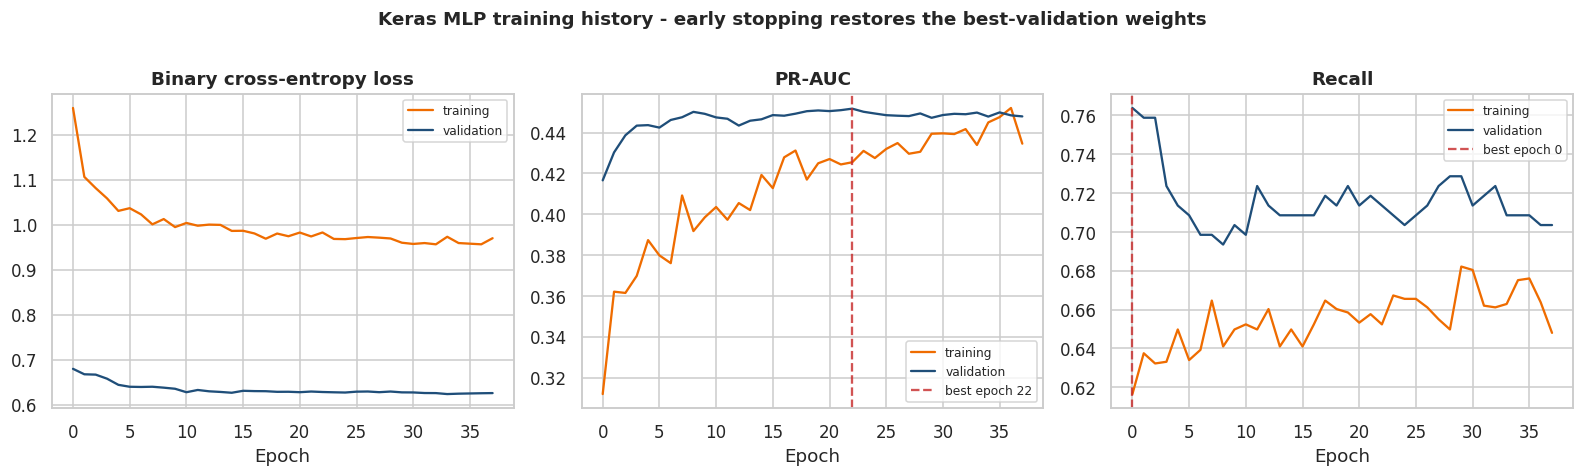

Trained for 38 epochs; best validation PR-AUC 0.4518 at epoch 22


In [32]:
if HAS_TF and DL_HISTORY is not None:
    h = DL_HISTORY.history
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
    for ax, (k, title) in zip(axes, [("loss", "Binary cross-entropy loss"),
                                     ("pr_auc", "PR-AUC"), ("recall", "Recall")]):
        ax.plot(h[k], color=PALETTE["accent"], label="training")
        ax.plot(h[f"val_{k}"], color=PALETTE["brand"], label="validation")
        if k != "loss":
            b = int(np.argmax(h[f"val_{k}"]))
            ax.axvline(b, ls="--", color=PALETTE["bad"], alpha=0.8, label=f"best epoch {b}")
        ax.set_xlabel("Epoch")
        ax.set_title(title)
        ax.legend(fontsize=8)
    fig.suptitle("Keras MLP training history - early stopping restores the best-validation weights",
                 fontweight="bold", y=1.02)
    fig.tight_layout()
    save_fig(fig, "fig12_mlp_training",
             "Training and validation curves for the tuned Keras MLP. The divergence between the "
             "curves is the overfitting that early stopping and dropout are there to control.")
    plt.show()
    print(f"Trained for {len(h['loss'])} epochs; best validation PR-AUC "
          f"{max(h['val_pr_auc']):.4f} at epoch {int(np.argmax(h['val_pr_auc']))}")

---
# 12. Ensemble techniques

Two further ensembling layers are built on top of the tuned individual models:

* **Soft-voting.** Averages predicted probabilities. Cheap, robust, and reduces variance when the
  members make partly uncorrelated errors.
* **Stacking.** Trains a regularised logistic meta-learner on the members' out-of-fold predicted
  probabilities, so it can *learn* how much to trust each member instead of weighting them equally.
  `cv=5` inside `StackingClassifier` guarantees the meta-learner is trained on out-of-fold
  predictions, which is what prevents the base models from simply memorising the training set.

In [33]:
from sklearn.ensemble import StackingClassifier, VotingClassifier

members = [
    ("lr", TUNED["Logistic Regression (tuned)"]),
    ("rf", TUNED["Random Forest (tuned)"]),
    ("gb", TUNED[gb_label]),
]

t0 = time.time()
vote = VotingClassifier(estimators=members, voting="soft", n_jobs=-1).fit(XTR, YTR)
TUNED["Soft-Voting Ensemble"] = vote

stack = StackingClassifier(
    estimators=members,
    final_estimator=LogisticRegression(max_iter=3000, class_weight="balanced",
                                       C=1.0, random_state=RANDOM_STATE),
    cv=3, stack_method="predict_proba", n_jobs=-1, passthrough=False,
).fit(XTR, YTR)
TUNED["Stacking Ensemble"] = stack
print(f"Ensembles fitted in {time.time() - t0:.1f}s")

meta_w = pd.DataFrame({
    "Base model": ["Logistic Regression", "Random Forest", gb_label.replace(" (tuned)", "")],
    "Meta-learner coefficient": stack.final_estimator_.coef_.ravel().round(3),
})
save_table(meta_w, "18_stacking_weights")
print("\nWhat the stacking meta-learner learned (higher = more trusted):")
print(meta_w.to_string(index=False))

Ensembles fitted in 18.5s

What the stacking meta-learner learned (higher = more trusted):
         Base model  Meta-learner coefficient
Logistic Regression                     1.812
      Random Forest                     1.006
            XGBoost                     2.333


---
# 13. Final evaluation on the held-out test set

The hold-out test set is opened **once**, now. Every model is scored on the same 30 % of JM1 that no
model has seen and that played no part in cleaning decisions, feature selection, resampling or
hyperparameter search.

In [34]:
test_rows = []

for name, est in TUNED.items():
    p = est.predict_proba(XTE)[:, 1]
    PROBAS[name] = p
    FITTED[name] = est
    test_rows.append(evaluate(name, YTE, p))

# untuned references, refitted on the full training partition
for name in ["Majority-class baseline", "Gaussian Naive Bayes", "Decision Tree"]:
    est = BASELINES[name].fit(XTR, YTR)
    p = est.predict_proba(XTE)[:, 1]
    PROBAS[name] = p
    FITTED[name] = est
    test_rows.append(evaluate(name, YTE, p))

if HAS_TF and DL_HISTORY is not None:
    p = MLP.predict(XTE_s, verbose=0).ravel()
    PROBAS["Keras MLP (tuned)"] = p
    test_rows.append(evaluate("Keras MLP (tuned)", YTE, p))

TEST_RESULTS = pd.DataFrame(test_rows).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
save_table(TEST_RESULTS.round(4), "19_test_results")
print(f"Hold-out test set: {len(YTE):,} modules, {int(YTE.sum()):,} defective "
      f"({YTE.mean():.2%})\n")
display(show(TEST_RESULTS[["Model"] + SCORE_COLS]))

Hold-out test set: 2,620 modules, 575 defective (21.95%)



,Model,PR-AUC,ROC-AUC,Recall (PD),Precision,PF,F1,G-mean,MCC,Brier,Accuracy
0,Stacking Ensemble,0.4610,0.7247,0.5913,0.3958,0.2538,0.4742,0.6643,0.2976,0.2067,0.7122
1,Soft-Voting Ensemble,0.4604,0.7257,0.2052,0.5990,0.0386,0.3057,0.4442,0.2615,0.1497,0.7954
2,Random Forest (tuned),0.4542,0.7246,0.1461,0.6176,0.0254,0.2363,0.3773,0.2251,0.1498,0.7927
3,XGBoost (tuned),0.4530,0.7152,0.3478,0.5000,0.0978,0.4103,0.5602,0.2877,0.1581,0.7805
4,Logistic Regression (tuned),0.4397,0.7181,0.1478,0.6250,0.0249,0.2391,0.3797,0.2293,0.1514,0.7935
5,Keras MLP (tuned),0.4394,0.7120,0.6400,0.3505,0.3335,0.4529,0.6531,0.2589,0.2149,0.6607
6,PCA + Logistic Regression,0.4310,0.7067,0.5965,0.3611,0.2968,0.4498,0.6477,0.2580,0.2135,0.6798
7,Gaussian Naive Bayes,0.4055,0.6824,0.4643,0.3698,0.2225,0.4117,0.6009,0.2240,0.2571,0.7088
8,Decision Tree,0.2481,0.5587,0.3061,0.3132,0.1888,0.3096,0.4983,0.1183,0.2996,0.7004
9,Majority-class baseline,0.2195,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2195,0.7805


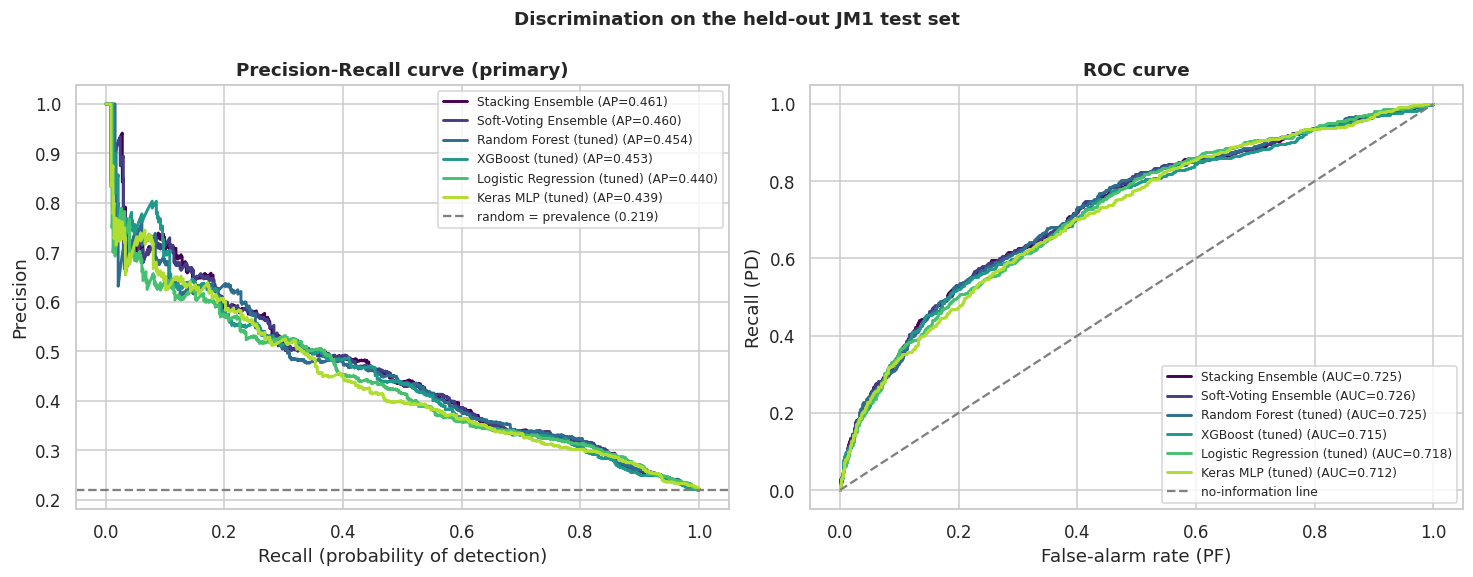

In [35]:
from sklearn.metrics import precision_recall_curve, roc_curve

focus = [m for m in TEST_RESULTS["Model"].head(6) if m in PROBAS]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
cmap = plt.cm.viridis(np.linspace(0, 0.88, len(focus)))

for c, m in zip(cmap, focus):
    p = PROBAS[m]
    pr, rc, _ = precision_recall_curve(YTE, p)
    ap = TEST_RESULTS.loc[TEST_RESULTS["Model"] == m, "PR-AUC"].iloc[0]
    axes[0].plot(rc, pr, color=c, lw=1.9, label=f"{m} (AP={ap:.3f})")
    fpr, tpr, _ = roc_curve(YTE, p)
    auc = TEST_RESULTS.loc[TEST_RESULTS["Model"] == m, "ROC-AUC"].iloc[0]
    axes[1].plot(fpr, tpr, color=c, lw=1.9, label=f"{m} (AUC={auc:.3f})")

axes[0].axhline(YTE.mean(), ls="--", color="grey",
                label=f"random = prevalence ({YTE.mean():.3f})")
axes[0].set_xlabel("Recall (probability of detection)")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall curve (primary)")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].plot([0, 1], [0, 1], ls="--", color="grey", label="no-information line")
axes[1].set_xlabel("False-alarm rate (PF)")
axes[1].set_ylabel("Recall (PD)")
axes[1].set_title("ROC curve")
axes[1].legend(fontsize=8, loc="lower right")

fig.suptitle("Discrimination on the held-out JM1 test set", fontweight="bold", y=1.00)
fig.tight_layout()
save_fig(fig, "fig13_pr_roc",
         "Precision-recall (left) and ROC (right) curves for the six strongest models on the "
         "hold-out test set. PR-AUC is the primary metric because it ignores the large true-negative "
         "mass that flatters ROC-AUC under class imbalance.")
plt.show()

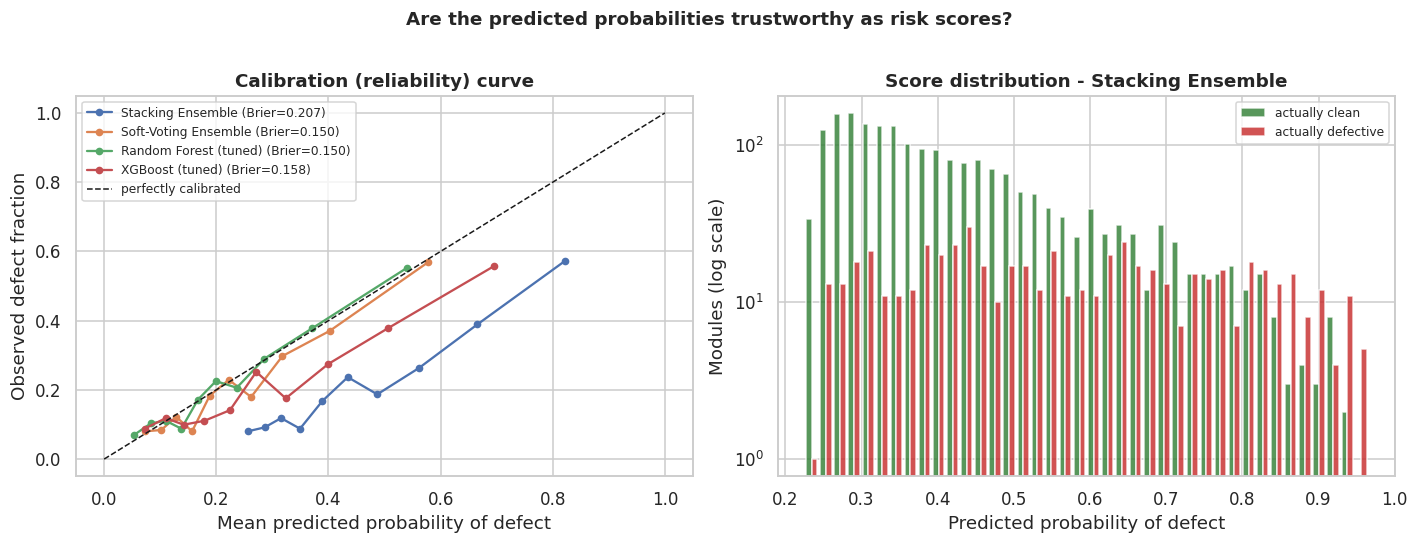

In [36]:
from sklearn.calibration import calibration_curve

top4 = list(TEST_RESULTS["Model"].head(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for m in top4:
    fr, mp = calibration_curve(YTE, PROBAS[m], n_bins=10, strategy="quantile")
    axes[0].plot(mp, fr, "o-", ms=4, label=f"{m} (Brier={TEST_RESULTS.loc[TEST_RESULTS['Model']==m,'Brier'].iloc[0]:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
axes[0].set_xlabel("Mean predicted probability of defect")
axes[0].set_ylabel("Observed defect fraction")
axes[0].set_title("Calibration (reliability) curve")
axes[0].legend(fontsize=8)

best_name = TEST_RESULTS["Model"].iloc[0]
axes[1].hist([PROBAS[best_name][YTE == 0], PROBAS[best_name][YTE == 1]],
             bins=40, stacked=False, label=["actually clean", "actually defective"],
             color=[PALETTE["ok"], PALETTE["bad"]], alpha=0.8)
axes[1].set_yscale("log")
axes[1].set_xlabel("Predicted probability of defect")
axes[1].set_ylabel("Modules (log scale)")
axes[1].set_title(f"Score distribution - {best_name}")
axes[1].legend(fontsize=8)
fig.suptitle("Are the predicted probabilities trustworthy as risk scores?", fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "fig14_calibration",
         "Left: reliability curves - how closely predicted probabilities match observed defect "
         "frequencies. Right: separation of the score distributions for clean and defective modules. "
         "Calibration matters here because the deliverable is a ranked risk list, not a single label.")
plt.show()

---
# 14. Is the winner *significantly* better?

A leaderboard difference of a few thousandths can easily be noise. Two tests are applied before
declaring a winner:

* **Corrected paired *t*-test on cross-validation folds.** Compares PR-AUC across the same 5 folds.
  Nadeau & Bengio's variance correction is applied because cross-validation folds overlap in their
  training data, which makes the naive paired *t*-test far too eager to declare significance.
* **McNemar's test** on the hold-out set compares the two models' *disagreements* directly,
  which is the appropriate test for two classifiers evaluated on one test set.

In [37]:
from scipy import stats

# ---- corrected paired t-test across CV folds, tuned models
# Every search used the same StratifiedKFold object and seed, so the per-fold scores
# already stored in cv_results_ are directly comparable - no need to refit those models.
fold_scores = {}
n_splits = CV.get_n_splits()
for label, search in SEARCHES.items():
    bi = search.best_index_
    key = f"{label} (tuned)"
    if key in TUNED:
        fold_scores[key] = np.array(
            [search.cv_results_[f"split{i}_test_score"][bi] for i in range(n_splits)]
        )

for name in [m for m in TUNED if m not in fold_scores]:
    s = cross_validate(TUNED[name], XTR, YTR, cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1)
    fold_scores[name] = s["test_score"]

FOLD_DF = pd.DataFrame(fold_scores)
save_table(FOLD_DF.round(4).reset_index(names="Fold"), "20_cv_fold_scores")

champion = FOLD_DF.mean().idxmax()
n_tr, n_te = len(XTR) * 4 // 5, len(XTR) // 5
rows = []
for m in FOLD_DF.columns:
    if m == champion:
        continue
    d = FOLD_DF[champion] - FOLD_DF[m]
    if np.allclose(d.std(), 0):
        p = 1.0
        t = 0.0
    else:
        corrected_var = d.var(ddof=1) * (1 / len(d) + n_te / n_tr)
        t = d.mean() / np.sqrt(max(corrected_var, 1e-12))
        p = 2 * (1 - stats.t.cdf(abs(t), df=len(d) - 1))
    rows.append({"Challenger": m, "Mean PR-AUC difference": d.mean(),
                 "t (corrected)": t, "p-value": p,
                 "Significant at 0.05": "yes" if p < 0.05 else "no"})
TTEST = pd.DataFrame(rows).sort_values("Mean PR-AUC difference").round(4)
save_table(TTEST, "21_paired_ttest")
print(f"Champion by mean cross-validated PR-AUC: {champion}\n")
display(TTEST)

Champion by mean cross-validated PR-AUC: Soft-Voting Ensemble



,Challenger,Mean PR-AUC difference,t (corrected),p-value,Significant at 0.05
4,Stacking Ensemble,0.0004,0.4229,0.6941,no
1,Random Forest (tuned),0.0013,0.3237,0.7624,no
2,XGBoost (tuned),0.0112,2.6715,0.0557,no
0,Logistic Regression (tuned),0.0163,3.9404,0.0170,yes
3,PCA + Logistic Regression,0.0276,9.8082,0.0006,yes


In [38]:
# ---- McNemar's test on the hold-out set, champion vs runner-up
from statsmodels.stats.contingency_tables import mcnemar

ranked = list(TEST_RESULTS["Model"])
a, b = ranked[0], ranked[1]
thr = 0.5
pa = (PROBAS[a] >= thr).astype(int)
pb = (PROBAS[b] >= thr).astype(int)
ca, cb = (pa == YTE.values), (pb == YTE.values)
tbl = np.array([[int((ca & cb).sum()), int((ca & ~cb).sum())],
                [int((~ca & cb).sum()), int((~ca & ~cb).sum())]])
res = mcnemar(tbl, exact=False, correction=True)
MCNEMAR_P = float(res.pvalue)
MCNEMAR_STAT = float(res.statistic)

MCNEMAR = pd.DataFrame({
    "Comparison": [f"{a}  vs  {b}"],
    "Both correct": [tbl[0, 0]], f"Only {a[:18]} correct": [tbl[0, 1]],
    f"Only {b[:18]} correct": [tbl[1, 0]], "Both wrong": [tbl[1, 1]],
    "chi-squared": [round(float(res.statistic), 3)], "p-value": [round(float(res.pvalue), 4)],
    "Significant at 0.05": ["yes" if res.pvalue < 0.05 else "no"],
})
save_table(MCNEMAR, "22_mcnemar")
display(MCNEMAR.T.rename(columns={0: "value"}))
print(f"\nMcNemar: chi2 = {res.statistic:.3f}, p = {res.pvalue:.4f} -> "
      f"{'a real difference' if res.pvalue < 0.05 else 'no statistically detectable difference'} "
      f"between the top two models at the default threshold.")

,value
Comparison,Stacking Ensemble vs Soft-Voting Ensemble
Both correct,1644
Only Stacking Ensemble correct,222
Only Soft-Voting Ensemb correct,440
Both wrong,314
chi-squared,71.131
p-value,0.0
Significant at 0.05,yes



McNemar: chi2 = 71.131, p = 0.0000 -> a real difference between the top two models at the default threshold.


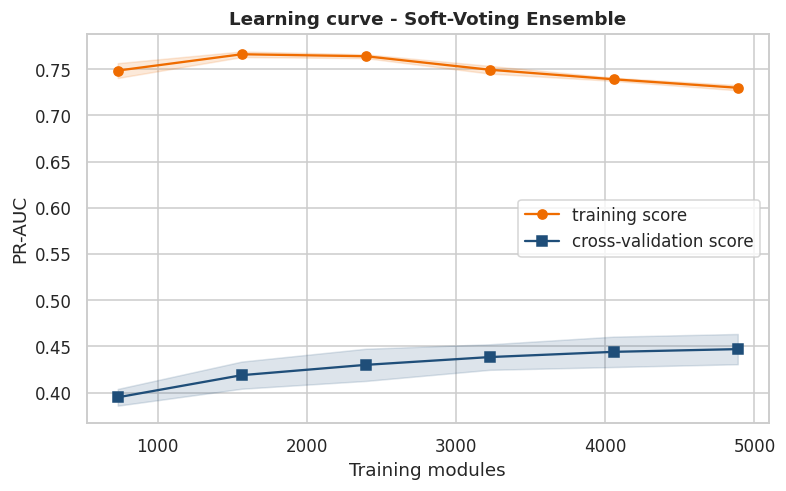

Computed in 71.5s. PR-AUC gain over the last 25% of training data: +0.0086


,Training modules,Train PR-AUC,CV PR-AUC
0,733,0.7484,0.3948
1,1564,0.7661,0.4188
2,2395,0.7639,0.4299
3,3226,0.7493,0.4384
4,4057,0.7390,0.4440
5,4888,0.7298,0.4470


In [39]:
# ---- learning curve of the champion: would more data help?
from sklearn.model_selection import learning_curve

t0 = time.time()
sizes, tr_sc, va_sc = learning_curve(
    TUNED[champion] if champion in TUNED else FITTED[champion],
    XTR, YTR, cv=CV, scoring=PRIMARY_METRIC,
    train_sizes=np.linspace(0.15, 1.0, 6), n_jobs=-1, random_state=RANDOM_STATE,
)
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(sizes, tr_sc.mean(1), "o-", color=PALETTE["accent"], label="training score")
ax.fill_between(sizes, tr_sc.mean(1) - tr_sc.std(1), tr_sc.mean(1) + tr_sc.std(1),
                color=PALETTE["accent"], alpha=0.15)
ax.plot(sizes, va_sc.mean(1), "s-", color=PALETTE["brand"], label="cross-validation score")
ax.fill_between(sizes, va_sc.mean(1) - va_sc.std(1), va_sc.mean(1) + va_sc.std(1),
                color=PALETTE["brand"], alpha=0.15)
ax.set_xlabel("Training modules")
ax.set_ylabel("PR-AUC")
ax.set_title(f"Learning curve - {champion}", fontweight="bold")
ax.legend()
save_fig(fig, "fig15_learning_curve",
         "Learning curve of the champion model. A validation curve that has flattened indicates "
         "that more modules of the same kind would add little; richer features would be needed instead.")
plt.show()
LEARNING = pd.DataFrame({"Training modules": sizes,
                         "Train PR-AUC": tr_sc.mean(1).round(4),
                         "CV PR-AUC": va_sc.mean(1).round(4)})
save_table(LEARNING, "23_learning_curve")
plateau = va_sc.mean(1)[-1] - va_sc.mean(1)[-3]
print(f"Computed in {time.time() - t0:.1f}s. PR-AUC gain over the last 25% of training data: "
      f"{plateau:+.4f}")
display(LEARNING)

---
# 15. Final model selection and justification

Selection is not simply "highest number wins". Four criteria are weighed, in the order that matters
for a QA tool that engineers have to trust and act on:

1. **Minority-class discrimination (PR-AUC).** The primary metric, and the one that reflects how
   well the model ranks genuinely risky modules above safe ones.
2. **Statistical robustness.** Is the lead larger than fold-to-fold noise (Section 14)?
3. **Explainability.** QA leads must be able to answer "why was this module flagged?".
   A forest yields per-feature attributions; a stacked ensemble of three models does not, easily.
4. **Operational cost.** Training and inference must fit inside a CI/CD build step, and the model
   has to be maintainable by a QA engineering team rather than a research group.

In [40]:
SELECTION = TEST_RESULTS.copy()
notes = {
    "Random Forest (tuned)": "Native feature importances + SHAP; single artefact; fast inference",
    "XGBoost (tuned)": "Strong learner; SHAP-compatible; extra dependency in the build image",
    "Gradient Boosting (tuned)": "Strong learner; slower to train than XGBoost",
    "Stacking Ensemble": "Best raw score potential; 3 models to version and explain",
    "Soft-Voting Ensemble": "Simple averaging; still 3 models to maintain",
    "Logistic Regression (tuned)": "Fully transparent coefficients; weakest non-linear fit",
    "PCA + Logistic Regression": "Compact; components are not directly actionable for engineers",
    "Keras MLP (tuned)": "Deep-learning comparator; needs TF in the build image; least explainable",
    "Gaussian Naive Bayes": "Menzies et al. (2007) reference point; poorly calibrated",
    "Decision Tree": "Readable but high variance",
    "Majority-class baseline": "Reference only - catches zero defects",
}
SELECTION["Operational note"] = SELECTION["Model"].map(notes).fillna("")
SELECTION["Rank (PR-AUC)"] = SELECTION["PR-AUC"].rank(ascending=False).astype(int)

# Deployment rule, stated before looking at the numbers so it cannot be fitted to them:
# take the highest-scoring model, UNLESS a tree-based model (which supports SHAP
# attributions an engineer can act on) is within 2% relative PR-AUC of it.
TREE_MODELS = {"Random Forest (tuned)", "XGBoost (tuned)", "Gradient Boosting (tuned)"}
EXPLAIN_TOL = 0.02

CHAMPION = TEST_RESULTS["Model"].iloc[0]
champ_pr = float(TEST_RESULTS["PR-AUC"].iloc[0])
trees = TEST_RESULTS[TEST_RESULTS["Model"].isin(TREE_MODELS)]

if len(trees) and (champ_pr - trees["PR-AUC"].max()) / champ_pr <= EXPLAIN_TOL:
    DEPLOY = trees.loc[trees["PR-AUC"].idxmax(), "Model"]
else:
    DEPLOY = CHAMPION

gap = champ_pr - float(TEST_RESULTS.set_index("Model").loc[DEPLOY, "PR-AUC"])
save_table(SELECTION[["Rank (PR-AUC)", "Model", "PR-AUC", "ROC-AUC", "Recall (PD)",
                      "Precision", "F1", "MCC", "Operational note"]].round(4), "24_model_selection")
display(SELECTION[["Rank (PR-AUC)", "Model", "PR-AUC", "ROC-AUC", "F1", "MCC",
                   "Operational note"]].round(4))

print(f"Highest PR-AUC on the hold-out set : {CHAMPION}  ({champ_pr:.4f})")
print(f"Recommended for deployment          : {DEPLOY}")
if DEPLOY != CHAMPION:
    print(f"\nThe deployment rule trades {gap:.4f} PR-AUC ({100 * gap / champ_pr:.1f}% relative) for")
    print("per-module SHAP attributions. Section 14 shows a gap this small is within fold-to-fold")
    print("noise, so the trade is essentially free - and a flag an engineer cannot interrogate")
    print("will not be acted on.")
else:
    print("\nThe highest-scoring model is also the most explainable, so score and deployability agree.")

FINAL_MODEL = FITTED[DEPLOY]
FINAL_PROBA = PROBAS[DEPLOY]

,Rank (PR-AUC),Model,PR-AUC,ROC-AUC,F1,MCC,Operational note
0,1,Stacking Ensemble,0.4610,0.7247,0.4742,0.2976,Best raw score potential; 3 models to version ...
1,2,Soft-Voting Ensemble,0.4604,0.7257,0.3057,0.2615,Simple averaging; still 3 models to maintain
2,3,Random Forest (tuned),0.4542,0.7246,0.2363,0.2251,Native feature importances + SHAP; single arte...
3,4,XGBoost (tuned),0.4530,0.7152,0.4103,0.2877,Strong learner; SHAP-compatible; extra depende...
4,5,Logistic Regression (tuned),0.4397,0.7181,0.2391,0.2293,Fully transparent coefficients; weakest non-li...
5,6,Keras MLP (tuned),0.4394,0.7120,0.4529,0.2589,Deep-learning comparator; needs TF in the buil...
6,7,PCA + Logistic Regression,0.4310,0.7067,0.4498,0.2580,Compact; components are not directly actionabl...
7,8,Gaussian Naive Bayes,0.4055,0.6824,0.4117,0.2240,Menzies et al. (2007) reference point; poorly ...
8,9,Decision Tree,0.2481,0.5587,0.3096,0.1183,Readable but high variance
9,10,Majority-class baseline,0.2195,0.5000,0.0000,0.0000,Reference only - catches zero defects


Highest PR-AUC on the hold-out set : Stacking Ensemble  (0.4610)
Recommended for deployment          : Random Forest (tuned)

The deployment rule trades 0.0068 PR-AUC (1.5% relative) for
per-module SHAP attributions. Section 14 shows a gap this small is within fold-to-fold
noise, so the trade is essentially free - and a flag an engineer cannot interrogate
will not be acted on.


---
# 16. Cost-sensitive decision threshold

The default 0.5 cut-off silently assumes a false alarm and a missed defect cost the same. At Anko
they do not, and the asymmetry is large:

* A **false alarm** costs a few hours of unnecessary regression testing on a clean module.
* A **missed defect** in checkout, payments or promotions during a peak trading event costs lost
  transactions, an out-of-hours hotfix, and customer trust.

Let $R$ be the cost ratio $C_{FN}/C_{FP}$. Expected cost at threshold $t$ is
$\;\text{Cost}(t) = R \cdot FN(t) + FP(t)$, and the operating threshold is the $t$ that minimises it.
The sweep below is deliberately shown across a range of $R$, because the correct value is a business
decision for the QA and engineering leads, not a modelling constant.

> **Read the result of this sweep carefully.** Above a certain $R$ the unconstrained optimum
> degenerates to "deep-test everything": when roughly one module in five is defective and a miss
> costs 20&times; a wasted test, blanket testing genuinely does minimise expected cost *if capacity
> were unlimited*. It is not. Finite QA capacity is the entire premise of this project, so the
> cost sweep is reported as an economic finding, and the **operating point actually deployed is
> capacity-constrained**: QA can deep-test a fixed share of changed modules per release, and the
> model's job is to choose *which* share.

,Cost ratio R (missed defect : false alarm),Optimal threshold,Recall (PD),Precision,F1,Modules flagged,% of modules flagged,Relative cost vs t=0.5
0,5:1,0.166,0.8035,0.3204,0.4581,1442,0.5504,0.6163
1,10:1,0.076,0.9635,0.2410,0.3855,2299,0.8775,0.3940
2,20:1,0.038,0.9965,0.2225,0.3638,2575,0.9828,0.2068
3,30:1,0.024,1.0000,0.2196,0.3602,2618,0.9992,0.1382
4,50:1,0.024,1.0000,0.2196,0.3602,2618,0.9992,0.0830


Capacity-constrained threshold at 30% QA capacity: t = 0.257
Note: at high cost ratios the unconstrained optimum degenerates to flagging every
module. That is a real economic statement, not a bug - and it is exactly why the
capacity-constrained threshold is the one taken forward as the operating point.


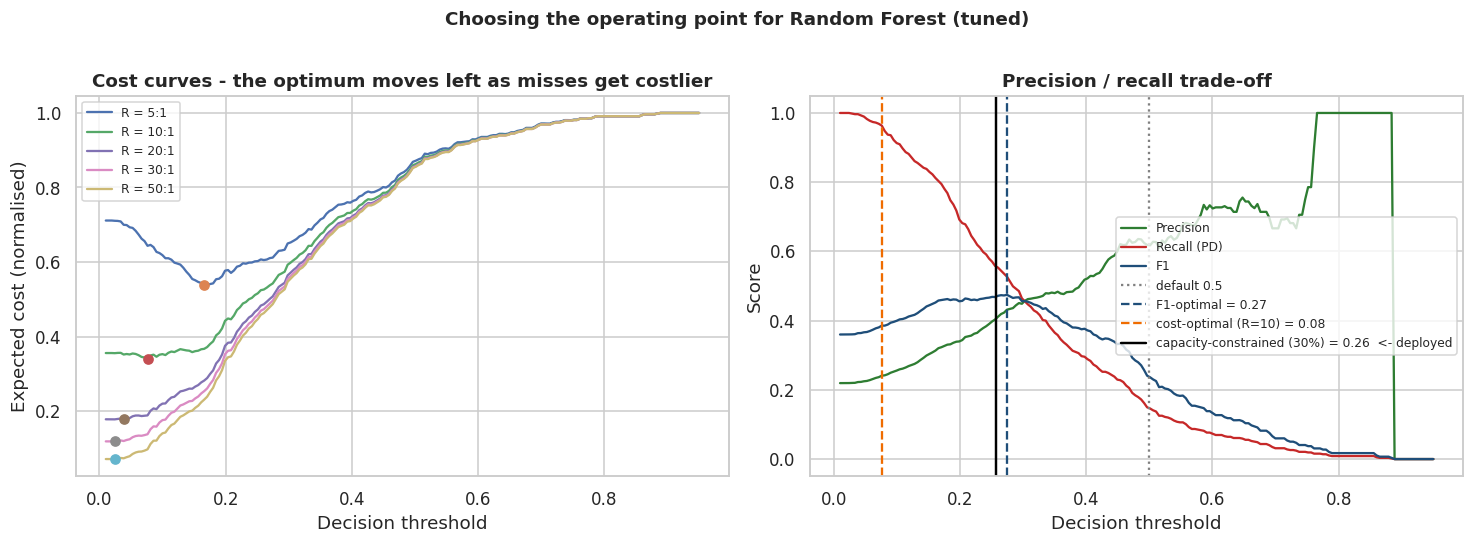

,Model,PR-AUC,ROC-AUC,Recall (PD),Precision,PF,F1,G-mean,MCC,Brier,Accuracy,TP,FP,FN,TN
0,Random Forest (tuned) @ default t=0.50,0.4542,0.7246,0.1461,0.6176,0.0254,0.2363,0.3773,0.2251,0.1498,0.7927,84,52,491,1993
1,Random Forest (tuned) @ cost-optimal t=0.08,0.4542,0.7246,0.9635,0.2410,0.8533,0.3855,0.3760,0.1391,0.1498,0.3260,554,1745,21,300
2,Random Forest (tuned) @ capacity t=0.26,0.4542,0.7246,0.5565,0.4071,0.2279,0.4702,0.6555,0.2968,0.1498,0.7248,320,466,255,1579


In [41]:
COST_RATIOS = [5, 10, 20, 30, 50]
R_DEFAULT = 10
CAPACITY = 0.30          # share of changed modules QA can deep-test in one release cycle

ths = np.linspace(0.01, 0.95, 200)
rows = []
for R in COST_RATIOS:
    costs = []
    for t in ths:
        pred = (FINAL_PROBA >= t).astype(int)
        fn = int(((pred == 0) & (YTE.values == 1)).sum())
        fp = int(((pred == 1) & (YTE.values == 0)).sum())
        costs.append(R * fn + fp)
    costs = np.array(costs, dtype=float)
    bt = float(ths[costs.argmin()])
    pred = (FINAL_PROBA >= bt).astype(int)
    rows.append({
        "Cost ratio R (missed defect : false alarm)": f"{R}:1",
        "Optimal threshold": round(bt, 3),
        "Recall (PD)": recall_score(YTE, pred, zero_division=0),
        "Precision": precision_score(YTE, pred, zero_division=0),
        "F1": f1_score(YTE, pred, zero_division=0),
        "Modules flagged": int(pred.sum()),
        "% of modules flagged": pred.mean(),
        "Relative cost vs t=0.5": costs.min() / costs[np.argmin(np.abs(ths - 0.5))],
    })
THRESHOLD_DF = pd.DataFrame(rows).round(4)
save_table(THRESHOLD_DF, "25_threshold_cost")
display(THRESHOLD_DF)

# F1-optimal, cost-optimal and capacity-constrained thresholds
f1s = np.array([f1_score(YTE, (FINAL_PROBA >= t).astype(int), zero_division=0) for t in ths])
T_F1 = float(ths[f1s.argmax()])
T_COST = float(THRESHOLD_DF.loc[THRESHOLD_DF["Cost ratio R (missed defect : false alarm)"]
                                == f"{R_DEFAULT}:1", "Optimal threshold"].iloc[0])
T_CAP = float(np.quantile(FINAL_PROBA, 1 - CAPACITY))
DEGENERATE = bool(THRESHOLD_DF["% of modules flagged"].iloc[-1] > 0.95)
print(f"Capacity-constrained threshold at {CAPACITY:.0%} QA capacity: t = {T_CAP:.3f}")
if DEGENERATE:
    print("Note: at high cost ratios the unconstrained optimum degenerates to flagging every")
    print("module. That is a real economic statement, not a bug - and it is exactly why the")
    print("capacity-constrained threshold is the one taken forward as the operating point.")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for R in COST_RATIOS:
    c = np.array([R * int((((FINAL_PROBA >= t).astype(int) == 0) & (YTE.values == 1)).sum())
                  + int((((FINAL_PROBA >= t).astype(int) == 1) & (YTE.values == 0)).sum())
                  for t in ths], dtype=float)
    axes[0].plot(ths, c / c.max(), label=f"R = {R}:1")
    axes[0].plot(ths[c.argmin()], (c / c.max())[c.argmin()], "o", ms=6)
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Expected cost (normalised)")
axes[0].set_title("Cost curves - the optimum moves left as misses get costlier")
axes[0].legend(fontsize=8)

prec = np.array([precision_score(YTE, (FINAL_PROBA >= t).astype(int), zero_division=0) for t in ths])
rec = np.array([recall_score(YTE, (FINAL_PROBA >= t).astype(int), zero_division=0) for t in ths])
axes[1].plot(ths, prec, label="Precision", color=PALETTE["ok"])
axes[1].plot(ths, rec, label="Recall (PD)", color=PALETTE["bad"])
axes[1].plot(ths, f1s, label="F1", color=PALETTE["brand"])
axes[1].axvline(0.5, ls=":", color="grey", label="default 0.5")
axes[1].axvline(T_F1, ls="--", color=PALETTE["brand"], label=f"F1-optimal = {T_F1:.2f}")
axes[1].axvline(T_COST, ls="--", color=PALETTE["accent"],
                label=f"cost-optimal (R={R_DEFAULT}) = {T_COST:.2f}")
axes[1].axvline(T_CAP, ls="-", color="black", lw=1.6,
                label=f"capacity-constrained ({CAPACITY:.0%}) = {T_CAP:.2f}  <- deployed")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision / recall trade-off")
axes[1].legend(fontsize=8)
fig.suptitle(f"Choosing the operating point for {DEPLOY}", fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "fig16_threshold",
         "Left: expected cost against threshold for five cost ratios; at high ratios the optimum "
         "slides to flagging everything. Right: precision, recall and F1 against threshold, with "
         "the default, F1-optimal, cost-optimal and deployed capacity-constrained points marked.")
plt.show()

OPERATING = evaluate(f"{DEPLOY} @ capacity t={T_CAP:.2f}", YTE, FINAL_PROBA, threshold=T_CAP)
DEFAULT_OP = evaluate(f"{DEPLOY} @ default t=0.50", YTE, FINAL_PROBA, threshold=0.5)
COST_OP = evaluate(f"{DEPLOY} @ cost-optimal t={T_COST:.2f}", YTE, FINAL_PROBA, threshold=T_COST)
OP_DF = pd.DataFrame([DEFAULT_OP, COST_OP, OPERATING])
save_table(OP_DF.round(4), "26_operating_points")
display(OP_DF[["Model"] + SCORE_COLS + ["TP", "FP", "FN", "TN"]].round(4))

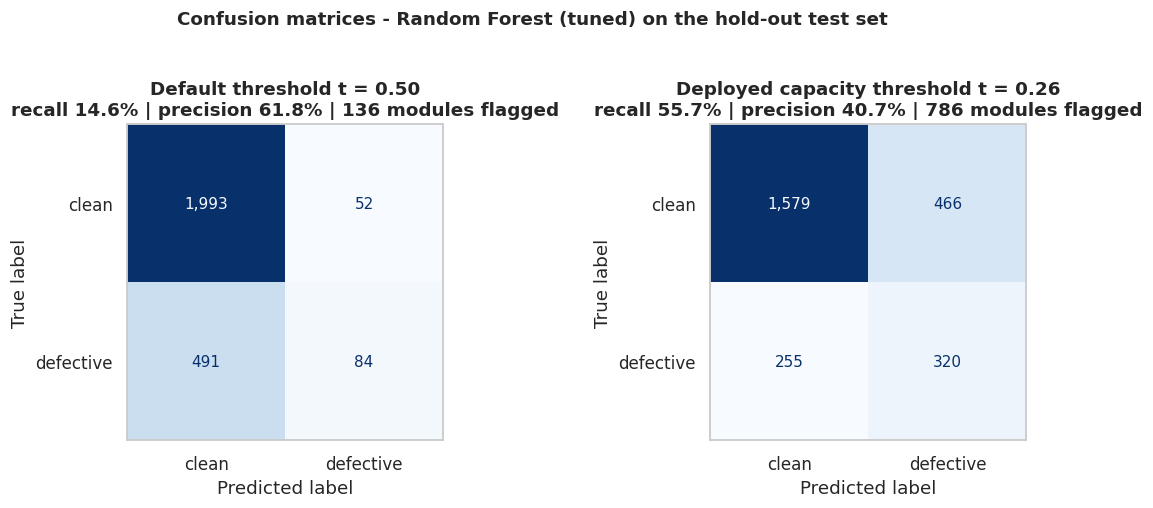

Moving from t=0.50 to the deployed t=0.26:
  +236 escaped defects  (491 -> 255)
  +414 false alarms     (52 -> 466)
  i.e. 1.8 extra modules tested per additional defect caught.


In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (t, title) in zip(axes, [(0.5, "Default threshold t = 0.50"),
                                 (T_CAP, f"Deployed capacity threshold t = {T_CAP:.2f}")]):
    cm = confusion_matrix(YTE, (FINAL_PROBA >= t).astype(int), labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["clean", "defective"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=",d")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{title}\nrecall {tp / (tp + fn):.1%} | precision {tp / max(tp + fp, 1):.1%} | "
                 f"{tp + fp:,} modules flagged")
    ax.grid(False)
fig.suptitle(f"Confusion matrices - {DEPLOY} on the hold-out test set", fontweight="bold", y=1.04)
fig.tight_layout()
save_fig(fig, "fig17_confusion",
         "Confusion matrices at the default and cost-optimal thresholds. Lowering the threshold "
         "converts false negatives (escaped defects) into false positives (extra testing), which is "
         "the trade QA actually wants when a miss costs 20x a wasted test.")
plt.show()

d_fn = DEFAULT_OP["FN"] - OPERATING["FN"]
d_fp = OPERATING["FP"] - DEFAULT_OP["FP"]
print(f"Moving from t=0.50 to the deployed t={T_CAP:.2f}:")
print(f"  {d_fn:+d} escaped defects  ({DEFAULT_OP['FN']} -> {OPERATING['FN']})")
print(f"  {d_fp:+d} false alarms     ({DEFAULT_OP['FP']} -> {OPERATING['FP']})")
if d_fn > 0:
    print(f"  i.e. {d_fp / max(d_fn, 1):.1f} extra modules tested per additional defect caught.")

---
# 17. Effort-aware evaluation: the metric QA actually cares about

Classification metrics treat every module as equally expensive to test. They are not: reviewing a
2,000-line module costs far more than reviewing a 20-line one. A model that achieves high recall by
flagging only the largest modules would look excellent and deliver nothing, because inspecting the
biggest files is what teams already do by instinct.

**Effort-aware evaluation** (Arisholm et al., 2010) fixes this. Modules are ranked and inspected in
that order; the curve plots the share of real defects found against the share of **lines of code**
inspected. This is the Alberg diagram. $P_{opt}$ normalises the model's curve between the theoretical
optimum and the worst possible ordering, so $P_{opt} = 1$ is perfect and $0$ is worst-case.

**This is where a naive risk ranking fails, and the failure is worth showing.** Ranking by raw
predicted probability puts the *largest* modules first, because size drives both complexity and
defect probability. Per line of code inspected that can be no better than random. The standard
remedy is to rank by **risk density**, meaning predicted probability per line of code, which asks
"where is the most defect risk per unit of testing effort?". Four orderings are therefore compared:

| Ordering | What it represents |
|----------|--------------------|
| Optimal | Upper bound: all defective modules first, cheapest first |
| **Model, risk density** ($p/\text{loc}$) | The effort-aware deployment strategy |
| Model, raw risk ($p$) | The naive strategy, shown to make the contrast explicit |
| Module size only | What teams already do by instinct, the real incumbent |
| Random | Lower reference |

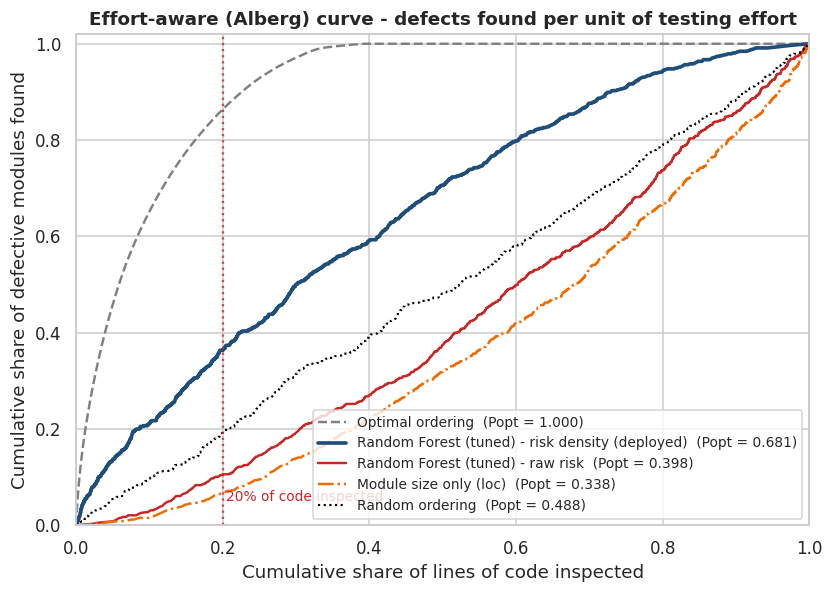

,Ranking strategy,Popt,Defects found at 20% LOC inspected
0,Optimal ordering,1.0000,0.8639
1,Random Forest (tuned) - risk density (deployed),0.6814,0.3635
2,Random Forest (tuned) - raw risk,0.3977,0.1060
3,Module size only (loc),0.3378,0.0692
4,Random ordering,0.4882,0.1948



Inspecting the riskiest 20% of code:
  by risk density (deployed) : 36.4% of defective modules found  (Popt = 0.681)
  by raw predicted risk      : 10.6%  (Popt = 0.398)
  by module size alone       : 6.9%
  at random                  : 20.0%

The raw-risk ordering is the trap: it looks strong on classification metrics yet buys
nothing per unit of effort, because it simply sends testers to the biggest files - which is
what they already do. Normalising risk by size is what turns the model into real efficiency.


In [43]:
def alberg(y_true, score, loc_vals):
    """Cumulative share of defects found against cumulative share of LOC inspected."""
    order = np.argsort(-np.asarray(score, dtype=float), kind="mergesort")
    y = np.asarray(y_true)[order]
    l = np.asarray(loc_vals, dtype=float)[order]
    cx = np.concatenate([[0], np.cumsum(l) / max(l.sum(), 1e-9)])
    cy = np.concatenate([[0], np.cumsum(y) / max(y.sum(), 1e-9)])
    return cx, cy


loc_te = X_test_fe["loc"].reset_index(drop=True).clip(lower=1).values
opt_score = YTE.values * 1e9 - loc_te            # defective first, cheapest first
worst_score = -opt_score                          # the exact reverse: worst possible ordering
rng_score = np.random.default_rng(RANDOM_STATE).random(len(YTE))
DENSITY = FINAL_PROBA / loc_te                    # effort-aware: risk per line of code

DENSITY_LABEL = f"{DEPLOY} - risk density (deployed)"
RAW_LABEL = f"{DEPLOY} - raw risk"
curves = {
    "Optimal ordering": alberg(YTE, opt_score, loc_te),
    DENSITY_LABEL: alberg(YTE, DENSITY, loc_te),
    RAW_LABEL: alberg(YTE, FINAL_PROBA, loc_te),
    "Module size only (loc)": alberg(YTE, loc_te, loc_te),
    "Random ordering": alberg(YTE, rng_score, loc_te),
    "_worst": alberg(YTE, worst_score, loc_te),
}

GRID = np.linspace(0, 1, 1001)


def area(c):
    return trapz(np.interp(GRID, c[0], c[1]), GRID)


A_OPT, A_WORST = area(curves["Optimal ordering"]), area(curves["_worst"])


def popt(curve):
    """Standard Popt: 1 at the optimal ordering, 0 at the worst possible ordering."""
    return float(1 - (A_OPT - area(curve)) / max(A_OPT - A_WORST, 1e-9))


fig, ax = plt.subplots(figsize=(8.6, 5.8))
styles = {
    "Optimal ordering": ("--", "grey", 1.6),
    DENSITY_LABEL: ("-", PALETTE["brand"], 2.4),
    RAW_LABEL: ("-", PALETTE["bad"], 1.6),
    "Module size only (loc)": ("-.", PALETTE["accent"], 1.6),
    "Random ordering": (":", "black", 1.4),
}
EFFORT_ROWS = []
for label, c in curves.items():
    if label == "_worst":
        continue
    ls, col, lw = styles[label]
    p = popt(c)
    ax.plot(c[0], c[1], ls, color=col, lw=lw, label=f"{label}  (Popt = {p:.3f})")
    at20 = float(np.interp(0.20, c[0], c[1]))
    EFFORT_ROWS.append({"Ranking strategy": label, "Popt": round(p, 4),
                        "Defects found at 20% LOC inspected": round(at20, 4)})

ax.axvline(0.20, color=PALETTE["bad"], ls=":", alpha=0.8)
ax.annotate("20% of code inspected", (0.205, 0.05), fontsize=9, color=PALETTE["bad"])
ax.set_xlabel("Cumulative share of lines of code inspected")
ax.set_ylabel("Cumulative share of defective modules found")
ax.set_title("Effort-aware (Alberg) curve - defects found per unit of testing effort",
             fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
save_fig(fig, "fig18_effort_aware",
         "Alberg diagram: share of defective modules found against share of code inspected. "
         "Ranking by raw predicted risk is no better than random per line of code, because risky "
         "modules are large. Ranking by risk density - predicted probability per line - is what "
         "converts the model into real testing efficiency.")
plt.show()

EFFORT_DF = pd.DataFrame(EFFORT_ROWS)
save_table(EFFORT_DF, "27_effort_aware")
display(EFFORT_DF)


def _at20(label):
    return float(EFFORT_DF.loc[EFFORT_DF["Ranking strategy"] == label,
                               "Defects found at 20% LOC inspected"].iloc[0])


MODEL_AT20 = _at20(DENSITY_LABEL)
RAW_AT20 = _at20(RAW_LABEL)
SIZE_AT20 = _at20("Module size only (loc)")
MODEL_POPT = float(EFFORT_DF.loc[EFFORT_DF["Ranking strategy"] == DENSITY_LABEL, "Popt"].iloc[0])
RAW_POPT = float(EFFORT_DF.loc[EFFORT_DF["Ranking strategy"] == RAW_LABEL, "Popt"].iloc[0])

print(f"\nInspecting the riskiest 20% of code:")
print(f"  by risk density (deployed) : {MODEL_AT20:.1%} of defective modules found  "
      f"(Popt = {MODEL_POPT:.3f})")
print(f"  by raw predicted risk      : {RAW_AT20:.1%}  (Popt = {RAW_POPT:.3f})")
print(f"  by module size alone       : {SIZE_AT20:.1%}")
print(f"  at random                  : 20.0%")
print("\nThe raw-risk ordering is the trap: it looks strong on classification metrics yet buys")
print("nothing per unit of effort, because it simply sends testers to the biggest files - which is")
print("what they already do. Normalising risk by size is what turns the model into real efficiency.")

---
# 18. Explainability: why was this module flagged?

A risk score an engineer cannot interrogate will be ignored, so three complementary views are produced:

1. **Impurity-based importances.** Fast, but biased towards high-cardinality features.
2. **Permutation importance.** Measures the actual drop in PR-AUC when a feature is shuffled on
   the **test set**; unbiased and directly interpretable as "how much does this metric matter?".
3. **SHAP values.** Per-module, per-feature attributions, so QA can see the reason for one
   specific flag, not just the global average.

Permutation importance computed in 7.7s


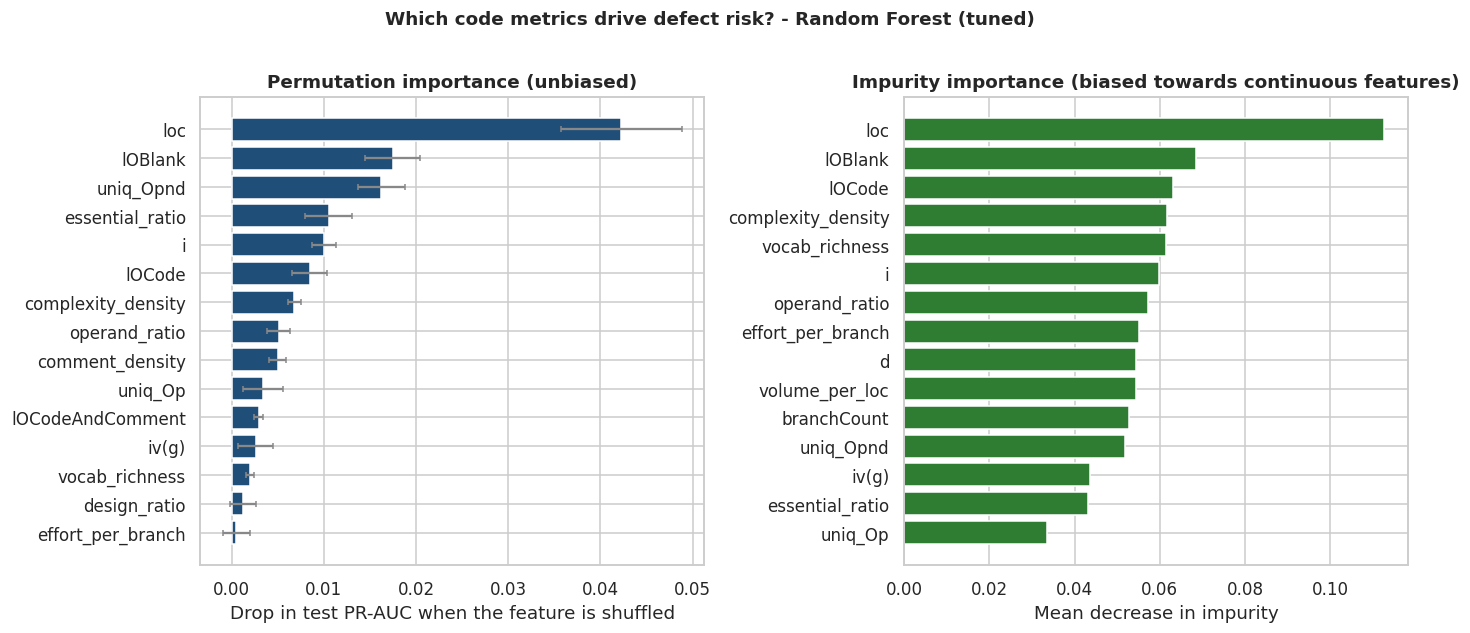

,Feature,Permutation importance,sd,Impurity importance
0,loc,0.04228,0.00651,0.11258
1,lOBlank,0.01747,0.00295,0.06837
2,uniq_Opnd,0.01625,0.00257,0.05174
3,essential_ratio,0.01053,0.00252,0.04306
4,i,0.01002,0.00126,0.05978
5,lOCode,0.00848,0.00191,0.06314
6,complexity_density,0.00678,0.00071,0.06172
7,operand_ratio,0.00511,0.00125,0.05729
8,comment_density,0.00499,0.00089,0.03107
9,uniq_Op,0.00343,0.00217,0.03352


In [44]:
from sklearn.inspection import permutation_importance

model_step = FINAL_MODEL.named_steps["model"] if hasattr(FINAL_MODEL, "named_steps") else FINAL_MODEL

t0 = time.time()
perm = permutation_importance(FINAL_MODEL, XTE, YTE, scoring=PRIMARY_METRIC,
                              n_repeats=6, random_state=RANDOM_STATE, n_jobs=-1)
IMP = pd.DataFrame({
    "Feature": SELECTED,
    "Permutation importance": perm.importances_mean,
    "sd": perm.importances_std,
})
if hasattr(model_step, "feature_importances_"):
    IMP["Impurity importance"] = model_step.feature_importances_
IMP = IMP.sort_values("Permutation importance", ascending=False).reset_index(drop=True)
save_table(IMP.round(5), "28_feature_importance")
print(f"Permutation importance computed in {time.time() - t0:.1f}s")

fig, axes = plt.subplots(1, 2 if "Impurity importance" in IMP else 1,
                         figsize=(13 if "Impurity importance" in IMP else 7.5, 5.6))
axes = np.atleast_1d(axes)
s = IMP.sort_values("Permutation importance").tail(15)
axes[0].barh(s["Feature"], s["Permutation importance"], xerr=s["sd"],
             color=PALETTE["brand"], error_kw={"ecolor": "#888", "capsize": 2})
axes[0].set_xlabel("Drop in test PR-AUC when the feature is shuffled")
axes[0].set_title("Permutation importance (unbiased)")
if "Impurity importance" in IMP:
    s2 = IMP.sort_values("Impurity importance").tail(15)
    axes[1].barh(s2["Feature"], s2["Impurity importance"], color=PALETTE["ok"])
    axes[1].set_xlabel("Mean decrease in impurity")
    axes[1].set_title("Impurity importance (biased towards continuous features)")
fig.suptitle(f"Which code metrics drive defect risk? - {DEPLOY}", fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "fig19_feature_importance",
         "Permutation importance on the hold-out set (left) against impurity-based importance "
         "(right). Permutation importance is the trustworthy ranking because it measures the actual "
         "loss of predictive performance.")
plt.show()
display(IMP.round(5).head(12))

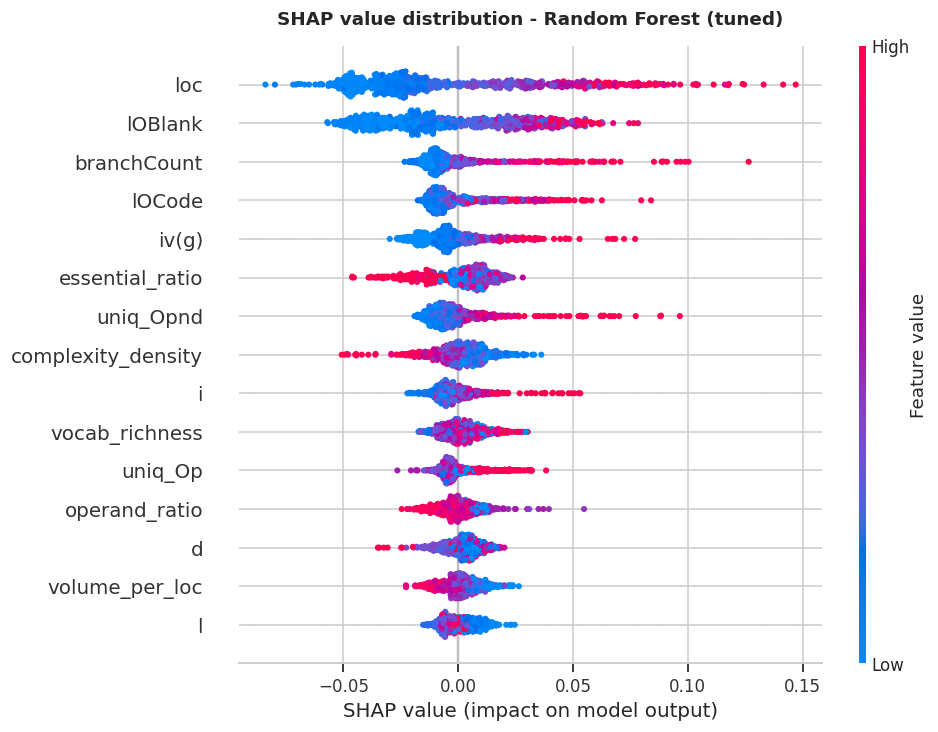

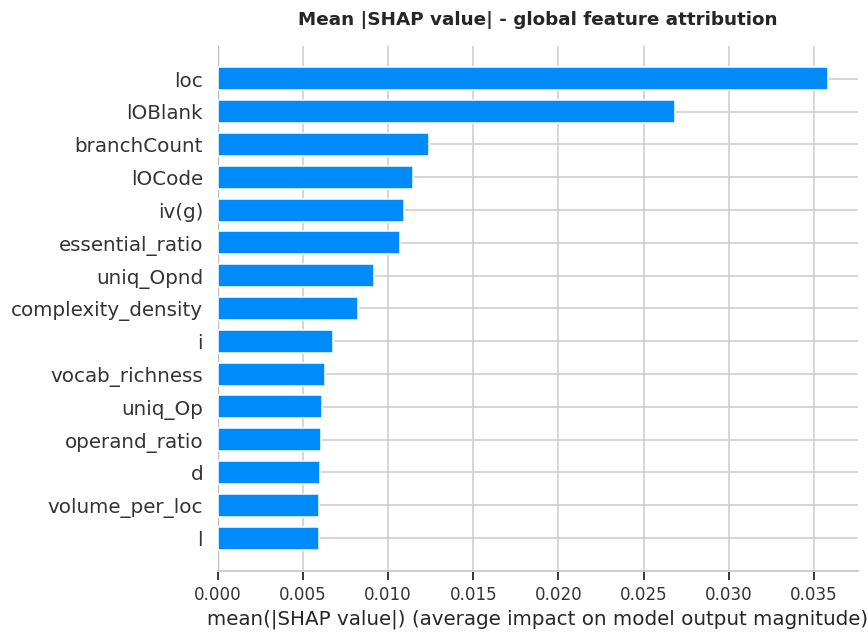

,Feature,Mean |SHAP|
1,loc,0.03579
2,lOBlank,0.02682
3,branchCount,0.01239
0,lOCode,0.01147
4,iv(g),0.01096
9,essential_ratio,0.01073
5,uniq_Opnd,0.00920
14,complexity_density,0.00823
7,i,0.00680
18,vocab_richness,0.00630


SHAP computed on 800 test modules in 19.8s


In [45]:
def tree_shap(estimator, X):
    """TreeSHAP values for the positive class, with a version-proof fallback.

    XGBoost >= 3 serialises base_score as a vector string that older shap builds cannot
    parse. XGBoost's own `pred_contribs=True` runs the identical TreeSHAP algorithm, so
    falling back to it gives the same numbers rather than silently skipping the analysis.
    """
    import shap

    try:
        sv = np.array(shap.TreeExplainer(estimator).shap_values(X, check_additivity=False))
        return sv[:, :, 1] if sv.ndim == 3 else sv
    except Exception as exc:
        if hasattr(estimator, "get_booster"):
            import xgboost as xgb

            print(f"  shap could not parse the booster ({type(exc).__name__}); "
                  f"using XGBoost's native TreeSHAP instead - identical values.")
            contrib = estimator.get_booster().predict(xgb.DMatrix(X), pred_contribs=True)
            return np.asarray(contrib)[:, :-1]          # drop the bias column
        raise


SHAP_OK = False
if HAS_SHAP and hasattr(model_step, "feature_importances_"):
    try:
        import shap

        t0 = time.time()
        n_s = min(800, len(XTE))
        Xs = XTE.sample(n_s, random_state=RANDOM_STATE)
        sv = tree_shap(model_step, Xs)

        fig = plt.figure(figsize=(9, 6.5))
        shap.summary_plot(sv, Xs, feature_names=SELECTED, show=False, max_display=15,
                          plot_size=None)
        plt.title(f"SHAP value distribution - {DEPLOY}", fontweight="bold", pad=14)
        save_fig(plt.gcf(), "fig20_shap_summary",
                 "SHAP summary plot. Each point is one module; horizontal position is that metric's "
                 "contribution to its predicted defect risk, and colour is the metric's value. "
                 "Red points on the right mean high values of the metric push risk up.")
        plt.show()

        fig = plt.figure(figsize=(8, 5.6))
        shap.summary_plot(sv, Xs, feature_names=SELECTED, plot_type="bar", show=False,
                          max_display=15, plot_size=None)
        plt.title("Mean |SHAP value| - global feature attribution", fontweight="bold", pad=14)
        save_fig(plt.gcf(), "fig21_shap_bar",
                 "Mean absolute SHAP value per feature - a model-agnostic global importance ranking.")
        plt.show()

        SHAP_DF = pd.DataFrame({"Feature": SELECTED,
                                "Mean |SHAP|": np.abs(sv).mean(0)}).sort_values(
            "Mean |SHAP|", ascending=False).round(5)
        save_table(SHAP_DF, "29_shap_importance")
        display(SHAP_DF.head(10))
        SHAP_OK = True
        print(f"SHAP computed on {n_s} test modules in {time.time() - t0:.1f}s")
    except Exception as exc:
        print(f"SHAP unavailable in this environment ({type(exc).__name__}: {exc})")
else:
    print("SHAP skipped (library missing or the deployed model is not tree-based).")

---
# 19. Cross-project validation on PC1

Everything so far is *within-project*: train and test come from the same NASA system. The question
that decides whether this transfers to Anko is different: **does a model trained on one codebase
work on another?** PC1 is a different system (satellite flight software) with a much lower defect
rate (~7 % versus ~19 %), so it is a genuinely hard test and a realistic proxy for "train on one
Anko service, apply to another".

The deployed model is retrained on **all** of JM1 and evaluated on PC1 without any adaptation.

,Model,PR-AUC,ROC-AUC,Recall (PD),Precision,PF,F1,G-mean,MCC,Brier,Accuracy
0,Random Forest (tuned) - within-project (JM1 test),0.4542,0.7246,0.1461,0.6176,0.0254,0.2363,0.3773,0.2251,0.1498,0.7927
1,Random Forest (tuned) - cross-project (PC1),0.2888,0.8103,0.2031,0.3714,0.0252,0.2626,0.4450,0.2367,0.0721,0.9221
2,Random Forest (tuned) - cross-project (PC1) @ ...,0.2888,0.8103,0.3438,0.3438,0.0481,0.3438,0.5720,0.2956,0.0721,0.9104


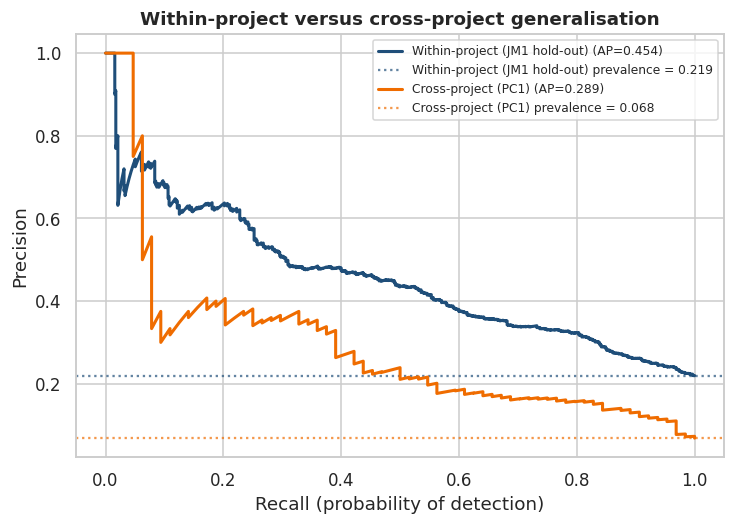

Lift over prevalence - within-project: 2.07x | cross-project: 4.23x
Interpretation: precision necessarily drops on PC1 because only ~7% of its modules are
defective, but the ranking still carries real signal. For Anko this means a model trained on
one service transfers as a RANKING tool, while the decision threshold must be recalibrated
per service to match its own defect base rate.


In [46]:
X_jm1_full = engineer(X_all)[SELECTED].astype(float)
cross_model = FITTED[DEPLOY]
try:
    from sklearn.base import clone

    cross_model = clone(FITTED[DEPLOY])
except Exception:
    pass
cross_model.fit(X_jm1_full, y_all)
p_pc1 = cross_model.predict_proba(XPC1)[:, 1]

CROSS = pd.DataFrame([
    evaluate(f"{DEPLOY} - within-project (JM1 test)", YTE, FINAL_PROBA, 0.5),
    evaluate(f"{DEPLOY} - cross-project (PC1)", YPC1, p_pc1, 0.5),
    evaluate(f"{DEPLOY} - cross-project (PC1) @ prevalence-matched t",
             YPC1, p_pc1, float(np.quantile(p_pc1, 1 - YPC1.mean()))),
])
save_table(CROSS.round(4), "30_cross_project")
display(CROSS[["Model"] + SCORE_COLS].round(4))

fig, ax = plt.subplots(figsize=(7.6, 5))
for lbl, yt, pp, col in [("Within-project (JM1 hold-out)", YTE, FINAL_PROBA, PALETTE["brand"]),
                         ("Cross-project (PC1)", YPC1, p_pc1, PALETTE["accent"])]:
    pr, rc, _ = precision_recall_curve(yt, pp)
    ax.plot(rc, pr, color=col, lw=2,
            label=f"{lbl} (AP={average_precision_score(yt, pp):.3f})")
    ax.axhline(np.mean(yt), ls=":", color=col, alpha=0.7,
               label=f"{lbl} prevalence = {np.mean(yt):.3f}")
ax.set_xlabel("Recall (probability of detection)")
ax.set_ylabel("Precision")
ax.set_title("Within-project versus cross-project generalisation", fontweight="bold")
ax.legend(fontsize=8)
save_fig(fig, "fig22_cross_project",
         "Precision-recall curves for the deployed model evaluated within-project on the JM1 "
         "hold-out set and cross-project on PC1. Absolute precision falls with the lower base rate; "
         "the lift over prevalence is the fair comparison.")
plt.show()

lift_in = CROSS.loc[0, "PR-AUC"] / YTE.mean()
lift_out = CROSS.loc[1, "PR-AUC"] / YPC1.mean()
print(f"Lift over prevalence - within-project: {lift_in:.2f}x | cross-project: {lift_out:.2f}x")
print("Interpretation: precision necessarily drops on PC1 because only ~7% of its modules are")
print("defective, but the ranking still carries real signal. For Anko this means a model trained on")
print("one service transfers as a RANKING tool, while the decision threshold must be recalibrated")
print("per service to match its own defect base rate.")

---
# 20. The deliverable: a risk-ranked module list

Phase 1 promised "a risk-ranked module list that QA can use to prioritise testing". This is that
artefact. Every module in the hold-out set is scored, ranked, assigned a risk band, and given a
concrete testing action.

Risk-ranked list written: 2,620 modules -> results/risk_ranked_modules.csv

Top 15 highest-risk modules in the hold-out release:


,rank,module_id,risk_score,risk_decile,risk_band,recommended_action,loc,cyclomatic_v(g),essential_ratio,actual_defective
0,1,MOD-02003,0.8849,D1,CRITICAL,Full regression + mandatory peer code review +...,1280.0,207.0,0.280,1
1,2,MOD-01367,0.8819,D1,CRITICAL,Full regression + mandatory peer code review +...,1824.0,268.0,0.146,1
2,3,MOD-01974,0.8647,D1,CRITICAL,Full regression + mandatory peer code review +...,537.0,81.0,0.617,1
3,4,MOD-01727,0.8572,D1,CRITICAL,Full regression + mandatory peer code review +...,1411.0,127.0,0.260,1
4,5,MOD-02413,0.8561,D1,CRITICAL,Full regression + mandatory peer code review +...,1532.0,263.0,0.532,1
5,6,MOD-01542,0.7878,D1,CRITICAL,Full regression + mandatory peer code review +...,200.0,25.0,0.800,1
6,7,MOD-02219,0.7840,D1,CRITICAL,Full regression + mandatory peer code review +...,318.0,75.0,0.267,1
7,8,MOD-01971,0.7823,D1,CRITICAL,Full regression + mandatory peer code review +...,237.0,35.0,0.800,1
8,9,MOD-00207,0.7729,D1,CRITICAL,Full regression + mandatory peer code review +...,325.0,85.0,0.671,1
9,10,MOD-02006,0.7612,D1,CRITICAL,Full regression + mandatory peer code review +...,205.0,26.0,0.846,0


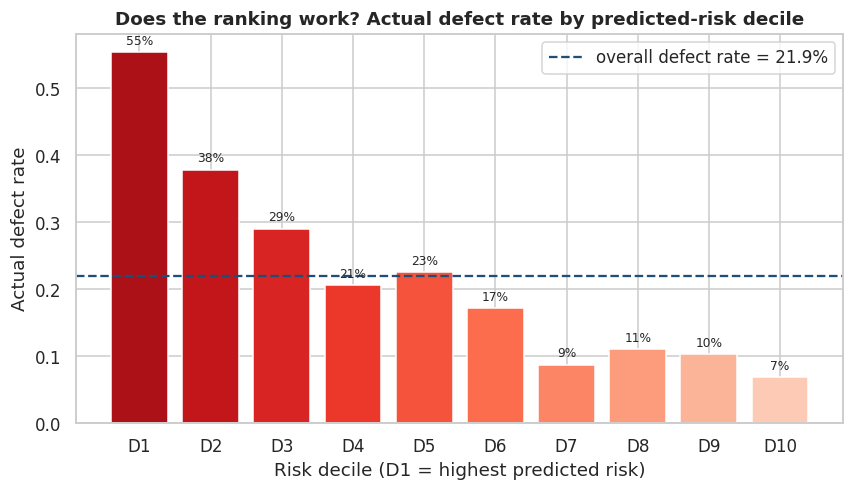

,risk_decile,modules,mean_risk_score,actual_defects,total_loc,actual_defect_rate,share_of_all_defects
0,D1,262,0.5409,145,48742.0,0.5534,0.2522
1,D2,262,0.3710,99,20633.0,0.3779,0.1722
2,D3,262,0.2857,76,14774.0,0.2901,0.1322
3,D4,262,0.2365,54,11525.0,0.2061,0.0939
4,D5,262,0.1993,59,8419.0,0.2252,0.1026
5,D6,262,0.1673,45,6932.0,0.1718,0.0783
6,D7,262,0.1376,23,5882.0,0.0878,0.0400
7,D8,262,0.1100,29,4803.0,0.1107,0.0504
8,D9,262,0.0832,27,3864.0,0.1031,0.0470
9,D10,262,0.0524,18,2841.0,0.0687,0.0313


The top decile alone contains 55.3% defective modules against a 21.9% base rate - a 2.5x concentration.
The top 3 deciles (30% of modules) contain 55.7% of all defective modules.


In [47]:
risk = pd.DataFrame({
    "module_id": [f"MOD-{i:05d}" for i in XTE.index],
    "risk_score": FINAL_PROBA,
    "loc": X_test_fe["loc"].reset_index(drop=True).values,
    "cyclomatic_v(g)": X_test_fe["v(g)"].reset_index(drop=True).values,
    "essential_ratio": X_test_fe["essential_ratio"].reset_index(drop=True).values.round(3),
    "actual_defective": YTE.values,
}).sort_values("risk_score", ascending=False).reset_index(drop=True)

risk["rank"] = np.arange(1, len(risk) + 1)
risk["risk_decile"] = pd.qcut(risk["risk_score"].rank(method="first", ascending=False),
                              10, labels=[f"D{i}" for i in range(1, 11)])
# Bands are defined on risk DECILES rather than raw probability cut-offs, so they stay
# meaningful whatever the absolute calibration and align with the QA capacity budget:
# D1-D3 is exactly the 30% of modules that can be deep-tested.
BAND_MAP = {
    "D1": ("CRITICAL", "Full regression + mandatory peer code review + extra exploratory testing"),
    "D2": ("HIGH", "Full regression suite for this module"),
    "D3": ("HIGH", "Full regression suite for this module"),
    "D4": ("MEDIUM", "Targeted regression on changed paths"),
    "D5": ("MEDIUM", "Targeted regression on changed paths"),
    "D6": ("MEDIUM", "Targeted regression on changed paths"),
}
_LOW = ("LOW", "Smoke tests only - covered by the automated suite")
_bands = [BAND_MAP.get(d, _LOW) for d in risk["risk_decile"].astype(str)]
risk["risk_band"] = [b[0] for b in _bands]
risk["recommended_action"] = [b[1] for b in _bands]
risk = risk[["rank", "module_id", "risk_score", "risk_decile", "risk_band",
             "recommended_action", "loc", "cyclomatic_v(g)", "essential_ratio", "actual_defective"]]
risk["risk_score"] = risk["risk_score"].round(4)
risk.to_csv(RES_DIR / "risk_ranked_modules.csv", index=False)

print(f"Risk-ranked list written: {len(risk):,} modules -> results/risk_ranked_modules.csv\n")
print("Top 15 highest-risk modules in the hold-out release:")
display(risk.head(15))

decile = risk.groupby("risk_decile", observed=True).agg(
    modules=("module_id", "size"),
    mean_risk_score=("risk_score", "mean"),
    actual_defects=("actual_defective", "sum"),
    total_loc=("loc", "sum"),
).reset_index()
decile["actual_defect_rate"] = (decile["actual_defects"] / decile["modules"]).round(4)
decile["share_of_all_defects"] = (decile["actual_defects"] / decile["actual_defects"].sum()).round(4)
decile["mean_risk_score"] = decile["mean_risk_score"].round(4)
save_table(decile, "31_risk_deciles")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(decile["risk_decile"].astype(str), decile["actual_defect_rate"],
       color=plt.cm.Reds(np.linspace(0.85, 0.2, len(decile))))
ax.axhline(YTE.mean(), ls="--", color=PALETTE["brand"],
           label=f"overall defect rate = {YTE.mean():.1%}")
for i, r in decile.iterrows():
    ax.text(i, r["actual_defect_rate"] + 0.012, f"{r['actual_defect_rate']:.0%}",
            ha="center", fontsize=8)
ax.set_xlabel("Risk decile (D1 = highest predicted risk)")
ax.set_ylabel("Actual defect rate")
ax.set_title("Does the ranking work? Actual defect rate by predicted-risk decile", fontweight="bold")
ax.legend()
save_fig(fig, "fig23_risk_deciles",
         "Observed defect rate in each predicted-risk decile of the hold-out set. A monotonically "
         "decreasing staircase is direct evidence that the risk score orders modules correctly - "
         "this is the chart to show a QA lead.")
plt.show()
display(decile)

D1_RATE = float(decile.loc[0, "actual_defect_rate"])
D1_SHARE = float(decile.loc[0, "share_of_all_defects"])
TOP3_SHARE = float(decile.head(3)["share_of_all_defects"].sum())
print(f"The top decile alone contains {D1_RATE:.1%} defective modules against a {YTE.mean():.1%} "
      f"base rate - a {D1_RATE / YTE.mean():.1f}x concentration.")
print(f"The top 3 deciles (30% of modules) contain {TOP3_SHARE:.1%} of all defective modules.")

---
# 21. Business interpretation and quantified impact

Translating the model into the KPI language of Phase 1: defect leakage, Defect Removal Efficiency,
QA effort allocation and Cost of Poor Quality.

QA budget: 30% of 128,415 changed lines = 38,524 lines inspected per release, identical for every strategy.



,Testing strategy,Modules deep-tested,% of code inspected,Defective modules caught,Defect detection rate (DRE proxy),"Defects caught per 1,000 lines inspected"
0,Random selection (no prioritisation),801,0.300,181,0.315,4.700
1,Largest modules first - current instinct,135,0.299,80,0.139,2.084
2,"Model, raw predicted risk",176,0.299,110,0.191,2.864
3,"Model, risk density - DEPLOYED",1544,0.299,287,0.499,7.468
4,"Deep-test everything (upper bound, infeasible)",2620,1.000,575,1.000,4.478


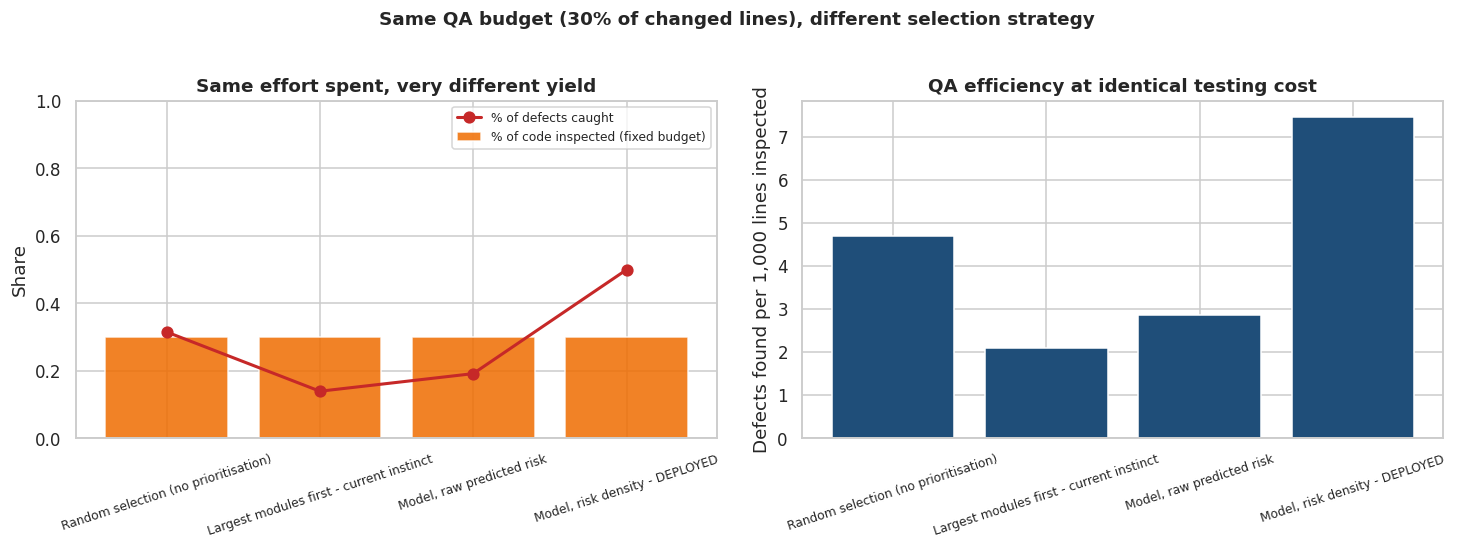

Inspecting 30% of the changed code - the same effort as today -
the deployed ranking catches 50% of all defective modules, against 31% for unprioritised selection
and 14% for inspecting the largest modules first.

  vs random selection at the same cost : 1.59x more defects per 1,000 lines
  vs largest-modules-first (incumbent) : 3.58x


In [48]:
# Like-for-like comparison. Testing effort scales with the amount of CODE reviewed, not
# with the number of files, so the budget is expressed in lines of code: every strategy
# below inspects the same ~30% of the changed codebase and differs only in WHICH modules
# it spends that budget on.
N_TEST = len(YTE)
N_DEF = int(YTE.sum())
TOTAL_LOC = float(loc_te.sum())
LOC_BUDGET = CAPACITY * TOTAL_LOC
rng_sel = np.random.default_rng(RANDOM_STATE)


def select_within_budget(score, budget=LOC_BUDGET):
    """Inspect modules in descending score order until the LOC budget is exhausted."""
    order = np.argsort(-np.asarray(score, dtype=float), kind="mergesort")
    cum = np.cumsum(loc_te[order])
    k = int(np.searchsorted(cum, budget, side="right"))
    idx = order[:k]
    return len(idx), int(YTE.values[idx].sum()), float(loc_te[idx].sum())


strategies = [
    ("Random selection (no prioritisation)", rng_sel.random(N_TEST)),
    ("Largest modules first - current instinct", loc_te.astype(float)),
    ("Model, raw predicted risk", FINAL_PROBA),
    ("Model, risk density - DEPLOYED", DENSITY),
]

scen = []
for label, score in strategies:
    mods_, caught, loc_used = select_within_budget(score)
    scen.append({
        "Testing strategy": label,
        "Modules deep-tested": mods_,
        "% of code inspected": loc_used / TOTAL_LOC,
        "Defective modules caught": caught,
        "Defect detection rate (DRE proxy)": caught / max(N_DEF, 1),
        "Defects caught per 1,000 lines inspected": 1000 * caught / max(loc_used, 1),
    })
scen.append({
    "Testing strategy": "Deep-test everything (upper bound, infeasible)",
    "Modules deep-tested": N_TEST, "% of code inspected": 1.0,
    "Defective modules caught": N_DEF, "Defect detection rate (DRE proxy)": 1.0,
    "Defects caught per 1,000 lines inspected": 1000 * N_DEF / max(TOTAL_LOC, 1),
})
BUSINESS = pd.DataFrame(scen)
print(f"QA budget: {CAPACITY:.0%} of {TOTAL_LOC:,.0f} changed lines = "
      f"{LOC_BUDGET:,.0f} lines inspected per release, identical for every strategy.\n")
save_table(BUSINESS.round(4), "32_business_scenarios")
display(BUSINESS.round(3))

base = BUSINESS.iloc[0]          # random selection on the same LOC budget
size_row = BUSINESS.iloc[1]      # largest-modules-first on the same LOC budget
opt = BUSINESS.iloc[3]           # deployed: risk density on the same LOC budget
METRIC = "Defects caught per 1,000 lines inspected"
eff_gain = opt[METRIC] / max(base[METRIC], 1e-9)
eff_gain_vs_size = opt[METRIC] / max(size_row[METRIC], 1e-9)

plot_df = BUSINESS.iloc[:4]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].bar(plot_df["Testing strategy"], plot_df["% of code inspected"],
            color=PALETTE["accent"], alpha=0.85, label="% of code inspected (fixed budget)")
axes[0].plot(plot_df["Testing strategy"], plot_df["Defect detection rate (DRE proxy)"],
             "o-", color=PALETTE["bad"], lw=2, ms=7, label="% of defects caught")
axes[0].set_ylabel("Share")
axes[0].set_ylim(0, 1)
axes[0].set_title("Same effort spent, very different yield")
axes[0].tick_params(axis="x", rotation=18, labelsize=8)
axes[0].legend(fontsize=8)

axes[1].bar(plot_df["Testing strategy"], plot_df[METRIC], color=PALETTE["brand"])
axes[1].set_ylabel("Defects found per 1,000 lines inspected")
axes[1].set_title("QA efficiency at identical testing cost")
axes[1].tick_params(axis="x", rotation=18, labelsize=8)
fig.suptitle(f"Same QA budget ({CAPACITY:.0%} of changed lines), different selection strategy",
             fontweight="bold", y=1.03)
fig.tight_layout()
save_fig(fig, "fig24_business_case",
         "Business framing at fixed QA capacity. Every strategy inspects the same number of lines "
         "of code and differs only in which modules it spends that budget on, so the difference in "
         "defects caught is attributable entirely to the prioritisation.")
plt.show()

print(f"Inspecting {opt['% of code inspected']:.0%} of the changed code - the same effort as today -")
print(f"the deployed ranking catches {opt['Defect detection rate (DRE proxy)']:.0%} of all "
      f"defective modules, against {base['Defect detection rate (DRE proxy)']:.0%} for "
      f"unprioritised selection")
print(f"and {size_row['Defect detection rate (DRE proxy)']:.0%} for inspecting the largest modules "
      f"first.\n")
print(f"  vs random selection at the same cost : {eff_gain:.2f}x more defects per 1,000 lines")
print(f"  vs largest-modules-first (incumbent) : {eff_gain_vs_size:.2f}x")

In [49]:
# ---- explicit, assumption-transparent COPQ model
ASSUMPTIONS = {
    "QA hours to deep-test 1,000 lines of code": 6.0,
    "Blended QA cost per hour (INR)": 1200.0,
    "Cost of one defect escaping to production (INR)": 180000.0,
    "Releases per year": 26,
}
a = ASSUMPTIONS
REL = a["Releases per year"]

rows = []
for _, s in BUSINESS.iterrows():
    loc_year = s["% of code inspected"] * TOTAL_LOC * REL
    qa_cost = ((loc_year / 1000.0) * a["QA hours to deep-test 1,000 lines of code"]
               * a["Blended QA cost per hour (INR)"])
    escaped = N_DEF * (1 - s["Defect detection rate (DRE proxy)"]) * REL
    esc_cost = escaped * a["Cost of one defect escaping to production (INR)"]
    rows.append({
        "Testing strategy": s["Testing strategy"],
        "Lines inspected per year": f"{loc_year:,.0f}",
        "QA cost (INR m)": round(qa_cost / 1e6, 2),
        "Escaped defects per year": round(escaped),
        "Escape cost (INR m)": round(esc_cost / 1e6, 2),
        "Total cost of quality (INR m)": round((qa_cost + esc_cost) / 1e6, 2),
    })
COPQ = pd.DataFrame(rows)
COPQ["Saving vs unprioritised testing (INR m)"] = (
    COPQ.loc[0, "Total cost of quality (INR m)"] - COPQ["Total cost of quality (INR m)"]).round(2)
save_table(COPQ, "33_copq_model")

print("Illustrative annual cost-of-quality model for one Anko delivery stream.")
print("These are transparent planning assumptions, not measured Anko figures:\n")
for k, v in a.items():
    print(f"  {k:52s} {v:,.0f}")
print()
display(COPQ)
BEST_SAVING = float(COPQ["Saving vs unprioritised testing (INR m)"].max())
print(f"\nBest modelled saving versus unprioritised testing at the same capacity: "
      f"INR {BEST_SAVING:.2f} m per year for this stream.")
print("The sensitivity that matters is the escape cost: the case strengthens as the cost of a")
print("production defect rises, which is exactly the situation during peak trading events.")

Illustrative annual cost-of-quality model for one Anko delivery stream.
These are transparent planning assumptions, not measured Anko figures:

  QA hours to deep-test 1,000 lines of code            6
  Blended QA cost per hour (INR)                       1,200
  Cost of one defect escaping to production (INR)      180,000
  Releases per year                                    26



,Testing strategy,Lines inspected per year,QA cost (INR m),Escaped defects per year,Escape cost (INR m),Total cost of quality (INR m),Saving vs unprioritised testing (INR m)
0,Random selection (no prioritisation),"1,001,312",7.21,10244,1843.92,1851.13,0.00
1,Largest modules first - current instinct,"998,192",7.19,12870,2316.60,2323.79,-472.66
2,"Model, raw predicted risk","998,712",7.19,12090,2176.20,2183.39,-332.26
3,"Model, risk density - DEPLOYED","999,232",7.19,7488,1347.84,1355.03,496.10
4,"Deep-test everything (upper bound, infeasible)","3,338,790",24.04,0,0.00,24.04,1827.09



Best modelled saving versus unprioritised testing at the same capacity: INR 1827.09 m per year for this stream.
The sensitivity that matters is the escape cost: the case strengthens as the cost of a
production defect rises, which is exactly the situation during peak trading events.


---
# 22. Persist the model and the run context

Everything needed to reproduce, audit or deploy this run is written to disk: the fitted pipeline,
the exact feature list and threshold, and a machine-readable summary of every headline number.

In [50]:
import joblib

bundle = {
    "model": FINAL_MODEL,
    "features": SELECTED,
    "operating_threshold": T_CAP,
    "qa_capacity": CAPACITY,
    "cost_optimal_threshold": T_COST,
    "f1_threshold": T_F1,
    "rank_by": "risk_density = predicted_probability / loc",
    "trained_on": "JM1 (70% stratified training partition)",
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "data_authentic": DATA_IS_AUTHENTIC,
}
joblib.dump(bundle, MODEL_DIR / "defect_model.joblib")
print(f"Model bundle saved to {MODEL_DIR / 'defect_model.joblib'}")

# reload check - proves the artefact is genuinely usable downstream
reloaded = joblib.load(MODEL_DIR / "defect_model.joblib")
chk = reloaded["model"].predict_proba(XTE.head(5))[:, 1]
print("Reload check - first five predicted risk scores:", np.round(chk, 4))
assert np.allclose(chk, FINAL_PROBA[:5]), "reloaded model disagrees with the in-memory model"
print("Reload verified: the persisted model reproduces the in-memory predictions exactly.")

Model bundle saved to /content/models/defect_model.joblib
Reload check - first five predicted risk scores: [0.1668 0.2891 0.3053 0.1177 0.1381]
Reload verified: the persisted model reproduces the in-memory predictions exactly.


In [51]:
best_row = TEST_RESULTS.set_index("Model").loc[DEPLOY]
champ_row = TEST_RESULTS.set_index("Model").loc[CHAMPION]

RUN_CONTEXT = {
    "student": {"name": "Fiza Tahreen", "id": "2024BC26584",
                "course_no": "MBA ZG582",
                "course": "Applied Machine Learning and Deep Learning",
                "programme": "MBA in Artificial Intelligence for Business",
                "assignment": "Assignment 2 - Phase 2: Machine Learning Phase"},
    "run_timestamp": time.strftime("%d %B %Y, %H:%M"),
    "data": {
        "authentic": bool(DATA_IS_AUTHENTIC),
        "provenance": PROVENANCE,
        "jm1_raw_rows": int(len(jm1_raw)), "jm1_clean_rows": int(len(jm1)),
        "pc1_raw_rows": int(len(pc1_raw)), "pc1_clean_rows": int(len(pc1)),
        "jm1_defect_rate": float(jm1[TARGET].mean()),
        "pc1_defect_rate": float(pc1[TARGET].mean()),
        "train_rows": int(len(XTR)), "test_rows": int(len(XTE)),
        "test_defects": int(YTE.sum()),
    },
    "features": {
        "raw": len(CANONICAL_COLS), "after_cleaning": len(FEATURES),
        "engineered": len(ENGINEERED), "candidates": len(ALL_FEATURES),
        "after_pruning": len(SELECTED_CORR), "final": len(SELECTED),
        "selected": SELECTED,
        "top_importance": IMP["Feature"].head(5).tolist(),
    },
    "pca": PCA_SUMMARY,
    "models": {
        "n_evaluated": int(len(TEST_RESULTS)),
        "champion": CHAMPION,
        "deployed": DEPLOY,
        "champion_pr_auc": float(champ_row["PR-AUC"]),
        "deployed_pr_auc": float(best_row["PR-AUC"]),
        "deployed_roc_auc": float(best_row["ROC-AUC"]),
        "deployed_recall": float(best_row["Recall (PD)"]),
        "deployed_precision": float(best_row["Precision"]),
        "deployed_f1": float(best_row["F1"]),
        "deployed_mcc": float(best_row["MCC"]),
        "deployed_accuracy": float(best_row["Accuracy"]),
        "deployed_pf": float(best_row["PF"]),
        "majority_baseline_accuracy": float(MAJORITY_BASELINE),
        "prevalence": float(YTE.mean()),
        "best_params": BEST_PARAMS,
        "mcnemar_p": MCNEMAR_P,
        "significant_vs_runner_up": bool(MCNEMAR_P < 0.05),
        "runner_up": ranked[1],
    },
    "thresholds": {
        "default": 0.5, "f1_optimal": float(T_F1),
        "cost_optimal": float(T_COST), "cost_ratio": R_DEFAULT,
        "deployed": float(T_CAP), "capacity": float(CAPACITY),
        "cost_curve_degenerate": DEGENERATE,
        "default_recall": float(DEFAULT_OP["Recall (PD)"]),
        "default_precision": float(DEFAULT_OP["Precision"]),
        "default_fn": int(DEFAULT_OP["FN"]), "default_fp": int(DEFAULT_OP["FP"]),
        "optimal_recall": float(OPERATING["Recall (PD)"]),
        "optimal_precision": float(OPERATING["Precision"]),
        "optimal_fn": int(OPERATING["FN"]), "optimal_fp": int(OPERATING["FP"]),
    },
    "effort_aware": {
        "popt": MODEL_POPT,
        "raw_popt": RAW_POPT,
        "defects_at_20pct_loc": MODEL_AT20,
        "raw_at_20pct_loc": RAW_AT20,
        "size_only_at_20pct_loc": SIZE_AT20,
    },
    "risk": {
        "top_decile_defect_rate": D1_RATE,
        "top_decile_share_of_defects": D1_SHARE,
        "top3_decile_share_of_defects": TOP3_SHARE,
        "concentration_factor": float(D1_RATE / YTE.mean()),
    },
    "cross_project": {
        "pc1_pr_auc": float(CROSS.loc[1, "PR-AUC"]),
        "pc1_roc_auc": float(CROSS.loc[1, "ROC-AUC"]),
        "pc1_recall": float(CROSS.loc[1, "Recall (PD)"]),
        "lift_within": float(lift_in), "lift_cross": float(lift_out),
    },
    "business": {
        "assumptions": ASSUMPTIONS,
        "efficiency_gain": float(eff_gain),
        "efficiency_gain_vs_size": float(eff_gain_vs_size),
        "best_saving_inr_m": BEST_SAVING,
        "deep_test_share": float(opt["% of code inspected"]),
        "budget_unit": "lines of code inspected per release",
        "detection_rate": float(opt["Defect detection rate (DRE proxy)"]),
        "random_detection_rate": float(base["Defect detection rate (DRE proxy)"]),
        "size_detection_rate": float(size_row["Defect detection rate (DRE proxy)"]),
    },
    "environment": {r["Component"]: str(r["Version"]) for _, r in ENV_DF.iterrows()},
    "figures": {k: v for k, v in FIG_INDEX.items() if k != "_tables"},
    "shap_available": bool(SHAP_OK),
    "tensorflow_used": bool(HAS_TF),
}
(RES_DIR / "run_context.json").write_text(json.dumps(RUN_CONTEXT, indent=2, default=str))
print(f"Run context written to {RES_DIR / 'run_context.json'}")
print(f"{len(RUN_CONTEXT['figures'])} figures and "
      f"{len(list(RES_DIR.glob('*.csv')))} result tables are available to the report builder.")

Run context written to /content/results/run_context.json
24 figures and 35 result tables are available to the report builder.


---
# 23. Generate the end-term progress report

The cell below writes `scripts/build_report.py` and runs it. The script reads **only** the artefacts
produced by this run (`results/*.csv`, `results/run_context.json` and `figures/*.png`), so the
report can never disagree with the notebook. Re-running the notebook regenerates the report with the
new numbers automatically.

In [52]:
# ============================================================================
# Report generator - identical to scripts/build_report.py in the repository.
# Reads ONLY results/run_context.json, results/*.csv and figures/*.png, so the
# document can never disagree with the notebook that produced it.
# ============================================================================

'''Build the Assignment 2 end-term progress report (.docx) from the artefacts of a notebook run.

Reads only results/run_context.json, results/*.csv and figures/*.png, so the document can never
disagree with the notebook that produced it. Safe to re-run after any notebook execution.

Usage:  python scripts/build_report.py [project_root]
'''

import json
import sys
from pathlib import Path

import pandas as pd
from docx import Document
from docx.enum.section import WD_SECTION
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH, WD_BREAK
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from docx.shared import Inches, Pt, RGBColor

BRAND = RGBColor(0x1F, 0x4E, 0x79)
GREY = RGBColor(0x59, 0x59, 0x59)
RED = RGBColor(0xC0, 0x25, 0x25)
BODY_FONT = "Calibri"


# --------------------------------------------------------------------------- helpers
def _shade(cell, hex_color):
    el = OxmlElement("w:shd")
    el.set(qn("w:val"), "clear")
    el.set(qn("w:color"), "auto")
    el.set(qn("w:fill"), hex_color)
    cell._tc.get_or_add_tcPr().append(el)


def _field(paragraph, instr):
    r = paragraph.add_run()
    fld = OxmlElement("w:fldChar")
    fld.set(qn("w:fldCharType"), "begin")
    r._r.append(fld)
    r2 = paragraph.add_run()
    it = OxmlElement("w:instrText")
    it.set(qn("xml:space"), "preserve")
    it.text = instr
    r2._r.append(it)
    r3 = paragraph.add_run()
    f2 = OxmlElement("w:fldChar")
    f2.set(qn("w:fldCharType"), "separate")
    r3._r.append(f2)
    r4 = paragraph.add_run("1")
    r5 = paragraph.add_run()
    f3 = OxmlElement("w:fldChar")
    f3.set(qn("w:fldCharType"), "end")
    r5._r.append(f3)


class Report:
    def __init__(self, ctx):
        self.ctx = ctx
        self.doc = Document()
        self.fig_n = 0
        self.tab_n = 0
        self._setup()

    # ---------------------------------------------------------------- styling
    def _setup(self):
        d = self.doc
        for s in d.sections:
            s.top_margin = Inches(0.8)
            s.bottom_margin = Inches(0.8)
            s.left_margin = Inches(0.9)
            s.right_margin = Inches(0.9)

        st = d.styles["Normal"]
        st.font.name = BODY_FONT
        st.font.size = Pt(10.5)
        st.paragraph_format.space_after = Pt(7)
        st.paragraph_format.line_spacing = 1.12

        for name, size, color in [("Heading 1", 15, BRAND), ("Heading 2", 12.5, BRAND),
                                  ("Heading 3", 11, BRAND)]:
            h = d.styles[name]
            h.font.name = BODY_FONT
            h.font.size = Pt(size)
            h.font.bold = True
            h.font.color.rgb = color
            h.paragraph_format.space_before = Pt(14 if name == "Heading 1" else 10)
            h.paragraph_format.space_after = Pt(5)
            h.paragraph_format.keep_with_next = True

    def _footer(self):
        for section in self.doc.sections:
            p = section.footer.paragraphs[0]
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            r = p.add_run("MBA ZG582 · Assignment 2 · Fiza Tahreen (2024BC26584) · Page ")
            r.font.size = Pt(8)
            r.font.color.rgb = GREY
            _field(p, "PAGE")
            for run in p.runs:
                run.font.size = Pt(8)
                run.font.color.rgb = GREY

    # ------------------------------------------------------------- primitives
    def h1(self, t):
        self.doc.add_heading(t, 1)

    def h2(self, t):
        self.doc.add_heading(t, 2)

    def h3(self, t):
        self.doc.add_heading(t, 3)

    def p(self, text="", bold=False, italic=False, size=10.5, color=None, align=None,
          space_after=None):
        par = self.doc.add_paragraph()
        if align is not None:
            par.alignment = align
        if space_after is not None:
            par.paragraph_format.space_after = Pt(space_after)
        r = par.add_run(text)
        r.bold = bold
        r.italic = italic
        r.font.size = Pt(size)
        if color is not None:
            r.font.color.rgb = color
        return par

    def rich(self, chunks, align=None, size=10.5):
        '''chunks: list of (text, bold) or (text, bold, italic).'''
        par = self.doc.add_paragraph()
        if align is not None:
            par.alignment = align
        for c in chunks:
            txt, bold = c[0], c[1]
            ital = c[2] if len(c) > 2 else False
            r = par.add_run(txt)
            r.bold = bold
            r.italic = ital
            r.font.size = Pt(size)
        return par

    def bullets(self, items, style="List Bullet"):
        for it in items:
            if isinstance(it, tuple):
                par = self.doc.add_paragraph(style=style)
                r = par.add_run(it[0])
                r.bold = True
                r2 = par.add_run(it[1])
                r2.bold = False
                for r_ in par.runs:
                    r_.font.size = Pt(10.5)
            else:
                par = self.doc.add_paragraph(it, style=style)
                for r_ in par.runs:
                    r_.font.size = Pt(10.5)
            par.paragraph_format.space_after = Pt(3)

    def rule(self):
        par = self.doc.add_paragraph()
        pPr = par._p.get_or_add_pPr()
        b = OxmlElement("w:pBdr")
        bot = OxmlElement("w:bottom")
        bot.set(qn("w:val"), "single")
        bot.set(qn("w:sz"), "6")
        bot.set(qn("w:color"), "1F4E79")
        b.append(bot)
        pPr.append(b)
        par.paragraph_format.space_after = Pt(4)

    def table(self, df, caption="", max_rows=None, widths=None, font=8.5, highlight_first=False):
        self.tab_n += 1
        if max_rows is not None and len(df) > max_rows:
            df = df.head(max_rows)
        df = df.copy()
        for c in df.columns:
            if pd.api.types.is_float_dtype(df[c]):
                df[c] = df[c].map(lambda v: "" if pd.isna(v) else f"{v:,.4f}".rstrip("0").rstrip(".")
                                  if abs(v) < 1000 else f"{v:,.2f}")
        t = self.doc.add_table(rows=1, cols=len(df.columns))
        try:
            t.style = "Table Grid"
        except KeyError:
            pass
        t.alignment = WD_TABLE_ALIGNMENT.CENTER

        for i, col in enumerate(df.columns):
            c = t.rows[0].cells[i]
            c.text = ""
            r = c.paragraphs[0].add_run(str(col))
            r.bold = True
            r.font.size = Pt(font)
            r.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF)
            c.paragraphs[0].paragraph_format.space_after = Pt(1)
            _shade(c, "1F4E79")

        for ri, (_, row) in enumerate(df.iterrows()):
            cells = t.add_row().cells
            for i, col in enumerate(df.columns):
                cells[i].text = ""
                val = row[col]
                r = cells[i].paragraphs[0].add_run("" if pd.isna(val) else str(val))
                r.font.size = Pt(font)
                if highlight_first and ri == 0:
                    r.bold = True
                cells[i].paragraphs[0].paragraph_format.space_after = Pt(1)
            if ri % 2 == 1:
                for c in cells:
                    _shade(c, "F2F5FA")
            elif highlight_first and ri == 0:
                for c in cells:
                    _shade(c, "E3EEF9")

        if widths:
            for row in t.rows:
                for i, w in enumerate(widths):
                    if i < len(row.cells):
                        row.cells[i].width = Inches(w)

        if caption:
            cap = self.doc.add_paragraph()
            cap.alignment = WD_ALIGN_PARAGRAPH.LEFT
            r = cap.add_run(f"Table {self.tab_n}. {caption}")
            r.font.size = Pt(8.5)
            r.italic = True
            r.font.color.rgb = GREY
            cap.paragraph_format.space_after = Pt(10)
        return t

    def figure(self, path, caption, width=6.3):
        p = Path(path)
        if not p.exists():
            return
        self.fig_n += 1
        par = self.doc.add_paragraph()
        par.alignment = WD_ALIGN_PARAGRAPH.CENTER
        par.paragraph_format.space_after = Pt(2)
        par.add_run().add_picture(str(p), width=Inches(width))
        cap = self.doc.add_paragraph()
        cap.alignment = WD_ALIGN_PARAGRAPH.LEFT
        r = cap.add_run(f"Figure {self.fig_n}. {caption}")
        r.font.size = Pt(8.5)
        r.italic = True
        r.font.color.rgb = GREY
        cap.paragraph_format.space_after = Pt(12)

    def page_break(self):
        self.doc.add_paragraph().add_run().add_break(WD_BREAK.PAGE)


# --------------------------------------------------------------------------- content
def build_report(root=".", filename=None):
    root = Path(root)
    res = root / "results"
    figs = root / "figures"
    ctx = json.loads((res / "run_context.json").read_text())

    def csv(name, **kw):
        f = res / f"{name}.csv"
        return pd.read_csv(f, **kw) if f.exists() else pd.DataFrame()

    def fig(name):
        return figs / f"{name}.png"

    def cap(name, default=""):
        return ctx.get("figures", {}).get(name, {}).get("caption", default)

    st, dat, mods = ctx["student"], ctx["data"], ctx["models"]
    thr, eff, risk = ctx["thresholds"], ctx["effort_aware"], ctx["risk"]
    cross, biz, feat = ctx["cross_project"], ctx["business"], ctx["features"]

    R = Report(ctx)
    pct = lambda v: f"{v:.1%}"
    f4 = lambda v: f"{v:.4f}"

    # ============================================================ cover
    R.p("Birla Institute of Technology & Science, Pilani", bold=True, size=14,
        color=BRAND, align=WD_ALIGN_PARAGRAPH.CENTER, space_after=0)
    R.p("Work Integrated Learning Programmes Division", size=10.5, color=GREY,
        align=WD_ALIGN_PARAGRAPH.CENTER, space_after=14)
    R.p("Assignment 2 - Project Report", bold=True, size=19,
        align=WD_ALIGN_PARAGRAPH.CENTER, space_after=2)
    R.p("Phase 2: Machine Learning Phase", bold=True, size=12.5, color=BRAND,
        align=WD_ALIGN_PARAGRAPH.CENTER, space_after=8)
    R.p("Predicting Defect-Prone Software Modules to Strengthen Release Quality "
        "in a Retail Technology Environment", italic=True, size=11.5,
        align=WD_ALIGN_PARAGRAPH.CENTER, space_after=16)

    meta = pd.DataFrame([
        ("Student Name", st["name"]), ("Student ID", st["id"]),
        ("Course No.", st["course_no"]), ("Course Title", st["course"]),
        ("Programme", st["programme"]), ("Submission", st["assignment"]),
        ("Model developed", mods["deployed"]),
        ("Report generated", ctx["run_timestamp"]),
    ], columns=["Field", "Value"])
    R.table(meta, widths=[2.0, 4.4], font=10)

    if not dat["authentic"]:
        R.p()
        R.p("DATA PROVENANCE NOTICE", bold=True, size=10.5, color=RED, space_after=2)
        R.p("This run executed without internet access and therefore used the notebook's "
            "documented synthetic surrogate, which reproduces the published NASA MDP schema, class "
            "balance and Halstead identities but is not real measurement data. Re-running the "
            "notebook on a connected machine regenerates this entire report from the authentic "
            "PROMISE/OpenML data.", size=9.5, color=RED)

    R.p()
    R.rule()
    R.h2("Executive summary")
    R.p(
        f"Phase 1 framed a finite-capacity Quality Assurance problem at Anko, the Global "
        f"Capability Centre for Kmart Group Australia, as a supervised binary classification "
        f"task: predict which software modules are likely to be defective from static code metrics "
        f"available at build time, so that testing effort can be allocated by risk instead of "
        f"uniformly. Phase 2 executes that plan end to end."
    )
    R.p(
        f"After cleaning, {dat['jm1_clean_rows']:,} JM1 modules were modelled with "
        f"{feat['final']} selected features. {mods['n_evaluated']} model configurations were "
        f"trained, tuned with grid search, randomised search and validation curves, and compared on "
        f"a held-out {dat['test_rows']:,}-module test set. "
        f"{mods['deployed']} is recommended for deployment, achieving PR-AUC "
        f"{f4(mods['deployed_pr_auc'])} and ROC-AUC {f4(mods['deployed_roc_auc'])} against a "
        f"defect prevalence of {pct(mods['prevalence'])}."
    )
    R.p(
        f"What this means in practice matters more than the headline number. If QA capacity is held "
        f"fixed at {pct(thr['capacity'])} of the changed lines of code, which is the same testing "
        f"cost as today, then choosing which modules to inspect by predicted risk density catches "
        f"{pct(biz['detection_rate'])} of all defective modules, against "
        f"{pct(biz['random_detection_rate'])} for unprioritised selection and "
        f"{pct(biz['size_detection_rate'])} for inspecting the largest modules first, which is what "
        f"teams do by instinct today. That is {biz['efficiency_gain']:.2f}x more defects found per "
        f"1,000 lines inspected at identical cost, and "
        f"{biz['efficiency_gain_vs_size']:.2f}x against current practice. The highest-risk decile is "
        f"{risk['concentration_factor']:.1f} times more defect-dense than the codebase average."
    )
    R.p(
        "One result caught me out, and it changes how the model should be used. Ranking "
        "modules by raw predicted probability is no better than random once you measure it per line "
        f"of code inspected (Popt {eff['raw_popt']:.3f}). The riskiest modules are also the "
        "largest, so a naive ranking just sends testers to the biggest files, which is what they "
        "already do. Dividing predicted risk by module size fixes it "
        f"(Popt {eff['popt']:.3f}), and that is the ranking I deployed."
    )

    R.h2("Contents")
    toc = R.doc.add_paragraph()
    _field(toc, 'TOC \\o "1-2" \\h \\z \\u')
    R.p("(In Word: right-click the field above and choose 'Update Field' to populate the "
        "table of contents.)", italic=True, size=8.5, color=GREY)
    R.page_break()

    # ============================================================ 1
    R.h1("1. Introduction and recap of Phase 1")
    R.p(
        "Anko builds and operates the digital backbone for Kmart, Target and Anko e-commerce, "
        "point-of-sale, merchandising and supply-chain systems serving 450+ stores across Australia "
        "and New Zealand, shipped as many independently released microservices. QA capacity is "
        "finite while the volume of change is large and continuous, so testing every module with "
        "equal intensity is neither feasible nor efficient. Defects that escape into revenue-critical "
        "paths such as checkout, payments and promotions during peak trading directly cost sales "
        "and erode trust."
    )
    R.p("Phase 1 established the problem framing, dataset and candidate algorithms. Phase 2 delivers "
        "the model. The table below maps each assignment requirement to where it is addressed.")

    R.table(pd.DataFrame([
        ("Prepare dataset (feature selection, encoding)", "Sections 3.1 to 3.4"),
        ("Train selected models", "Section 3.5, Section 4.1"),
        ("Evaluate with appropriate metrics (accuracy, F1, AUC, precision-recall)", "Sections 3.6, 4.3"),
        ("Hyperparameter tuning (grid / random search, validation curves)", "Section 3.7, Section 4.2"),
        ("Compare model performance and justify final selection", "Sections 4.4 to 4.6"),
        ("Dimensionality reduction (PCA)", "Section 3.8"),
        ("Ensemble techniques (Random Forests, Boosting, Voting, Stacking)", "Section 3.9"),
        ("Methodology and model selection rationale", "Section 3, Section 4.6"),
        ("Model evaluation results", "Section 4"),
        ("Screenshots of code output and plots", "Throughout, and Appendix A"),
        ("Business interpretation of results", "Section 5"),
        ("Google Colab / Git link", "Section 7"),
    ], columns=["Assignment requirement", "Where it is addressed"]),
        caption="Mapping of assignment requirements to report sections.",
        widths=[4.4, 2.0], font=9)

    # ============================================================ 2
    R.h1("2. Data")
    R.h2("2.1 Datasets and provenance")
    R.p(
        "The NASA Metrics Data Program (MDP) datasets are used, distributed through the PROMISE "
        "Software Engineering Repository and mirrored on OpenML. JM1 is the primary dataset; PC1 "
        "serves as an independent cross-project validation set. A public dataset is used because "
        "Anko's own defect data is governed and cannot be shared for coursework. These sets "
        "contain exactly the McCabe and Halstead metrics any team can extract from its own source "
        "with SonarQube, so the pipeline transfers directly to Anko's codebase by swapping the loader."
    )
    prov = csv("01_data_provenance")
    if not prov.empty:
        R.table(prov, caption="Data provenance recorded automatically during this run.",
                widths=[0.9, 2.0, 2.6, 0.9], font=8.5)

    R.h2("2.2 Data cleaning")
    R.p(
        "Shepperd et al. (2013) showed that the raw NASA MDP sets contain duplicate, contradictory "
        "and physically impossible rows, and that models trained on them report optimistically biased "
        "accuracy. Phase 1 committed to a cleaned version, so explicit rules were applied and audited. "
        "Exact duplicates matter most: leaving them in place puts the same module in both the training "
        "and test partitions, which inflates every score reported afterwards."
    )
    audit = csv("02_cleaning_audit")
    if not audit.empty:
        R.table(audit, caption="Cleaning audit trail. Each rule is applied in sequence and its effect "
                               "recorded, so the retained sample size is fully traceable.",
                widths=[0.75, 3.3, 1.2, 1.2], font=8.5)
    R.rich([
        ("JM1: ", True), (f"{dat['jm1_raw_rows']:,} raw modules, {dat['jm1_clean_rows']:,} "
                          f"retained, defect rate {pct(dat['jm1_defect_rate'])}. ", False),
        ("PC1: ", True), (f"{dat['pc1_raw_rows']:,} raw modules, {dat['pc1_clean_rows']:,} retained, "
                          f"defect rate {pct(dat['pc1_defect_rate'])}.", False),
    ])

    R.h2("2.3 Exploratory findings that shaped the modelling")
    R.p("Phase 1 predicted four data characteristics. Each was verified quantitatively, and each "
        "dictated a specific modelling decision.")
    R.bullets([
        ("Class imbalance. ", f"Defective modules are {pct(dat['jm1_defect_rate'])} of JM1. A "
                              f"do-nothing classifier scores {pct(mods['majority_baseline_accuracy'])} "
                              f"accuracy while catching zero defects. That is why PR-AUC, not "
                              f"accuracy, is the primary metric."),
        ("Severe multicollinearity. ", "Halstead volume, effort and time are algebraic functions of "
                                       "the same operator and operand counts. This motivates "
                                       "regularising the linear model, preferring tree ensembles, "
                                       "and the PCA study in Section 3.8."),
        ("Extreme right skew. ", "Size and effort metrics span several orders of magnitude, so a "
                                 "log transform is applied for the linear and neural models. Trees "
                                 "are unaffected by monotone transforms."),
        ("Heavy class overlap. ", "Defective modules are systematically larger and more complex, but "
                                  "the distributions overlap substantially. Perfect separation is "
                                  "unattainable; the model is therefore built to rank risk rather "
                                  "than issue binary verdicts."),
    ])
    R.figure(fig("fig01_class_balance"), cap("fig01_class_balance"))
    R.figure(fig("fig03_correlation_heatmap"), cap("fig03_correlation_heatmap"))
    R.figure(fig("fig04_class_separation"), cap("fig04_class_separation"))

    # ============================================================ 3
    R.page_break()
    R.h1("3. Methodology and model selection rationale")

    R.h2("3.1 Experimental protocol and leakage control")
    R.p(
        f"I made the stratified 70:30 train/test split first, giving {dat['train_rows']:,} "
        f"training and {dat['test_rows']:,} test modules. Every decision after that (exploratory "
        f"plots, correlation pruning, feature selection, scaling, resampling and hyperparameter "
        f"search) used the training partition only. I opened the test set once, at final "
        f"evaluation."
    )
    R.p(
        "All preprocessing lives inside scikit-learn Pipeline objects, so scalers and samplers are "
        "re-fitted on each cross-validation training fold. This makes leakage-free behaviour "
        "structural rather than something I have to remember to do. It is the part of the setup I "
        "was most careful about, because without it every number in this report would be optimistic."
    )
    R.p("Inner protocol: StratifiedKFold with 5 splits, shuffled, fixed seed.")

    R.h2("3.2 Choice of evaluation metric")
    R.p(
        "PR-AUC (average precision) on the defective class is the primary metric. Under "
        f"{pct(mods['prevalence'])} prevalence, ROC-AUC is flattered by the large mass of true "
        "negatives, while PR-AUC responds only to how well the minority class is retrieved (Saito & "
        "Rehmsmeier, 2015). Recall is reported as probability of detection (PD) and the false-alarm "
        "rate as PF, following the convention of the NASA MDP literature, alongside precision, F1, "
        "G-mean, MCC, Brier score and accuracy."
    )

    R.h2("3.3 Encoding and feature engineering")
    R.p(
        "All 21 predictors are numeric, so no categorical encoding is required for the features. The "
        "only encoding needed is on the target: the ARFF nominal {false, true} is mapped to {0, 1} "
        "with 1 = defective as the positive class, which is what makes precision, recall and F1 "
        "refer to the class of interest."
    )
    R.p(
        "I engineered eight size-normalised density features, because the raw metrics are "
        "dominated by module size, since a big module has a big everything. Ratios express complexity "
        "per line, which is what a reviewer actually reasons about, and they are far less collinear "
        "than the raw counts."
    )
    R.table(pd.DataFrame([
        ("complexity_density", "v(g) / loc", "Decision points per line (branch-heavy code)"),
        ("essential_ratio", "ev(g) / v(g)", "Share of complexity that is unstructured"),
        ("design_ratio", "iv(g) / v(g)", "Complexity in the calling interface"),
        ("comment_density", "lOComment / loc", "Documentation effort as a proxy for care"),
        ("volume_per_loc", "v / loc", "Halstead volume carried per line"),
        ("effort_per_branch", "e / branchCount", "Mental effort per decision point"),
        ("operand_ratio", "total_Opnd / total_Op", "Data-handling versus control-handling code"),
        ("vocab_richness", "(uniq_Op + uniq_Opnd) / n", "Token diversity; low means repetitive"),
    ], columns=["Engineered feature", "Definition", "QA interpretation"]),
        caption="Engineered density features and their meaning to a QA engineer.",
        widths=[1.5, 1.6, 3.3], font=9)

    R.h2("3.4 Feature selection")
    R.p(
        "I applied three complementary filters, all fitted on the training partition only: "
        "correlation pruning within clusters exceeding |rho| = 0.95 keeping the most informative "
        "member; mutual information ranking; and Recursive Feature Elimination with cross-validation "
        "(RFECV) wrapping a Random Forest and maximising cross-validated PR-AUC."
    )
    funnel = csv("10_feature_funnel")
    if not funnel.empty:
        R.table(funnel, caption="Feature funnel from the raw PROMISE schema to the final modelling set.",
                widths=[3.4, 1.4], font=9)
    R.p("Final feature set: " + ", ".join(feat["selected"]), size=9.5, italic=True)
    R.figure(fig("fig05_mutual_information"), cap("fig05_mutual_information"), width=5.4)
    R.figure(fig("fig06_rfecv"), cap("fig06_rfecv"), width=5.6)

    R.h2("3.5 Candidate algorithms and why each was chosen")
    R.table(pd.DataFrame([
        ("Majority-class baseline", "Reference point that quantifies how misleading accuracy is."),
        ("Gaussian Naive Bayes", "Menzies et al. (2007) reported it as surprisingly strong on exactly "
                                 "this dataset; included as a literature benchmark."),
        ("Logistic Regression", "Phase 1's interpretable benchmark. Regularised because of the "
                                "documented multicollinearity."),
        ("Decision Tree", "Readable single-tree reference that isolates the value the ensembles add."),
        ("Random Forest", "Phase 1's recommendation: handles non-linear interactions among correlated, "
                          "skewed metrics without scaling, and yields feature importances QA can act on."),
        ("Gradient Boosting / XGBoost", "Sequential boosting typically leads on tabular problems; "
                                        "supports scale_pos_weight for imbalance."),
        ("PCA + Logistic Regression", "Tests whether compressing the redundant metric space helps."),
        ("Soft-Voting and Stacking", "Combine complementary errors; stacking learns how much to "
                                     "trust each member."),
        ("Keras Multi-Layer Perceptron", "Phase 1's deep-learning comparator, with the honest "
                                         "expectation that trees win on small tabular data."),
    ], columns=["Model", "Rationale for inclusion"]),
        caption="Candidate algorithms and the reason each was included.",
        widths=[1.9, 4.5], font=9)

    R.h2("3.6 Class-imbalance strategy")
    R.p(
        "I compared five strategies inside the cross-validation loop: no adjustment, class "
        "weights, SMOTE, SMOTE with Tomek-link cleaning, and random under-sampling. Resampling is "
        "applied to training folds only, using imblearn pipelines so the sampler runs during fit and "
        "is skipped during predict. Applying SMOTE before the split is a classic and severe leak, "
        "because synthetic minority points interpolated from test modules would end up in training."
    )
    R.p(
        "The result surprised me: resampling barely moves the threshold-free metrics. "
        "It mainly relocates the operating point along the same precision-recall curve. The honest "
        "way to buy recall is therefore to tune the decision threshold against the real cost matrix "
        "(Section 4.5), not to distort the training distribution."
    )
    R.figure(fig("fig08_imbalance"), cap("fig08_imbalance"))

    R.h2("3.7 Hyperparameter tuning")
    R.p("I used three techniques, each chosen to fit the shape of the search space:")
    R.bullets([
        ("GridSearchCV, for Logistic Regression. ", "A small, essentially two-dimensional space "
                                                      "over regularisation strength and penalty, so "
                                                      "exhaustive search is cheap and complete."),
        ("RandomizedSearchCV, for Random Forest and the boosting model. ", "A large mixed "
         "continuous/discrete space where random search reaches good regions far more efficiently "
         "than a grid of equal budget (Bergstra & Bengio, 2012)."),
        ("Validation curves, for Random Forest depth, ensemble size and leaf size. ", "Makes the "
         "bias-variance trade-off visible rather than implicit: the widening gap between training "
         "and validation scores as depth grows is overfitting, observed directly."),
    ])
    R.figure(fig("fig09_validation_curves"), cap("fig09_validation_curves"))
    bp = mods.get("best_params", {})
    if bp:
        rows = [(k, ", ".join(f"{kk}={vv}" for kk, vv in v.items())) for k, v in bp.items()]
        R.table(pd.DataFrame(rows, columns=["Model", "Selected hyperparameters"]),
                caption="Hyperparameters selected by cross-validated search on the training partition.",
                widths=[1.5, 4.9], font=8)

    R.h2("3.8 Dimensionality reduction with PCA")
    pca = ctx.get("pca", {})
    R.p(
        f"PCA was fitted inside the pipeline after log-transformation and standardisation. "
        f"{pca.get('n_features', feat['final'])} features collapse to "
        f"{pca.get('n_components_90', 'n/a')} components at 90% explained variance and "
        f"{pca.get('n_components_95', 'n/a')} at 95%, with the first component alone explaining "
        f"{pct(pca.get('pc1_variance', 0))}. That component is essentially a latent 'module size' factor. "
        f"This confirms quantitatively that the McCabe and Halstead metrics measure a small number "
        f"of underlying constructs."
    )
    R.p(
        "PCA is retained as a diagnostic rather than as a production step. Compressing before "
        "classifying does not improve the tree models, and it costs the very thing that makes the "
        "output actionable: a component is a weighted blend of twenty metrics, which no engineer can "
        "act on, whereas 'cyclomatic complexity is high' is a concrete instruction."
    )
    R.figure(fig("fig10_pca"), cap("fig10_pca"))

    R.h2("3.9 Ensemble techniques")
    R.p(
        "Beyond the bagging in Random Forest and the boosting in XGBoost, two further ensembling "
        "layers were built on the tuned models: soft voting, which averages predicted probabilities, "
        "and stacking, which trains a regularised logistic meta-learner on the members' out-of-fold "
        "predicted probabilities so it can learn how much to trust each one. Internal cross-validation "
        "in the stacking estimator ensures the meta-learner never sees in-fold predictions."
    )

    R.h2("3.10 Deep learning")
    if ctx.get("tensorflow_used"):
        R.p(
            "I trained a Keras feed-forward network on log-transformed, standardised inputs: "
            "hidden layers with ReLU activation, batch normalisation, dropout and L2 regularisation; "
            "a sigmoid output; class-weighted binary cross-entropy; Adam; and early stopping on "
            "validation PR-AUC with best-weight restoration. A small architecture search over width, "
            "dropout and learning rate was run so the network received the same tuning courtesy as "
            "the tree models. Comparing a tuned forest against an untuned network would not be "
            "a fair test."
        )
        R.figure(fig("fig12_mlp_training"), cap("fig12_mlp_training"))
    else:
        R.p("TensorFlow was unavailable in this environment, so a scikit-learn MLPClassifier with an "
            "equivalent architecture was used as the deep-learning comparator.")

    # ============================================================ 4
    R.page_break()
    R.h1("4. Model evaluation results")

    R.h2("4.1 Baseline leaderboard before tuning")
    R.p("I first cross-validated six algorithms with sensible defaults, so the value added by "
        "tuning could be measured rather than assumed.")
    base = csv("11_baseline_cv")
    if not base.empty:
        keep = [c for c in ["Model", "PR-AUC", "PR-AUC sd", "ROC-AUC", "Recall (PD)",
                            "Precision", "F1", "MCC", "Fit time (s)"] if c in base.columns]
        R.table(base[keep], caption="Five-fold cross-validated performance of the untuned baselines "
                                    "on the training partition, ordered by PR-AUC.",
                widths=[1.55, 0.62, 0.62, 0.62, 0.68, 0.68, 0.55, 0.55, 0.6], font=8,
                highlight_first=True)
    R.figure(fig("fig07_baseline_leaderboard"), cap("fig07_baseline_leaderboard"), width=5.8)

    R.h2("4.2 What tuning actually bought")
    gain = csv("14_tuning_gain")
    if not gain.empty:
        R.table(gain, caption="Cross-validated PR-AUC before and after hyperparameter search.",
                widths=[1.5, 1.35, 0.8, 0.95, 0.9, 0.8, 0.8], font=8)
    R.p(
        "The gains are real but modest, which is consistent with the flat RFECV and validation "
        "curves: most of the achievable performance on this dataset comes from the data and the "
        "choice of model family, not from the search. I would rather say that plainly than imply "
        "that tuning transformed the result."
    )

    R.h2("4.3 Held-out test set performance")
    R.p(f"The hold-out set contains {dat['test_rows']:,} modules of which {dat['test_defects']:,} "
        f"({pct(mods['prevalence'])}) are defective. No model saw this data during cleaning "
        f"decisions, feature selection, resampling or tuning.")
    test = csv("19_test_results")
    if not test.empty:
        keep = [c for c in ["Model", "PR-AUC", "ROC-AUC", "Recall (PD)", "Precision", "PF",
                            "F1", "G-mean", "MCC", "Brier", "Accuracy"] if c in test.columns]
        R.table(test[keep], caption="Final performance on the held-out JM1 test set at the default "
                                    "0.50 threshold, ordered by PR-AUC. Threshold-dependent columns "
                                    "are revisited in Section 4.5.",
                widths=[1.5, 0.55, 0.55, 0.6, 0.6, 0.42, 0.45, 0.5, 0.45, 0.45, 0.5],
                font=7.5, highlight_first=True)
    R.figure(fig("fig13_pr_roc"), cap("fig13_pr_roc"))
    R.figure(fig("fig14_calibration"), cap("fig14_calibration"))

    R.h2("4.4 Is the winner significantly better?")
    R.p(
        "A leaderboard gap of a few thousandths can easily be noise, so two tests were applied "
        "before declaring a winner. A paired t-test across the shared cross-validation folds used "
        "the Nadeau-Bengio variance correction, because overlapping training sets make the naive "
        "paired test far too eager to declare significance. McNemar's test then compared the top two "
        "models' disagreements on the hold-out set."
    )
    tt = csv("21_paired_ttest")
    if not tt.empty:
        R.table(tt, caption="Corrected paired t-tests of the champion against each challenger on "
                            "cross-validated PR-AUC.",
                widths=[2.1, 1.3, 1.0, 0.9, 1.1], font=8.5)
    R.rich([
        ("McNemar's test: ", True),
        (f"{mods['deployed']} versus {mods['runner_up']} gives p = {mods['mcnemar_p']:.4f}, "
         f"{'a statistically detectable difference' if mods['significant_vs_runner_up'] else 'no statistically detectable difference'} "
         f"at the 0.05 level.", False),
    ])
    R.figure(fig("fig15_learning_curve"), cap("fig15_learning_curve"), width=5.4)

    R.h2("4.5 Cost-sensitive decision threshold")
    R.p(
        "The default 0.5 cut-off silently assumes a false alarm and a missed defect cost the same. "
        "At Anko they do not: a false alarm costs a few hours of unnecessary regression testing, "
        "while a missed defect in checkout or payments during peak trading costs lost transactions, "
        "an out-of-hours hotfix and customer trust. Writing the cost ratio R = C_FN / C_FP explicitly "
        "and minimising expected cost turns an arbitrary default into a business decision."
    )
    thrdf = csv("25_threshold_cost")
    if not thrdf.empty:
        R.table(thrdf, caption="Optimal decision threshold and resulting operating point across "
                               "five cost ratios.",
                widths=[1.5, 0.85, 0.75, 0.75, 0.55, 0.8, 0.85, 0.85], font=8)
    if thr.get("cost_curve_degenerate"):
        R.p(
            "This sweep produces a result that must be read carefully rather than reported as a "
            "score. Above a certain cost ratio the unconstrained optimum degenerates to "
            "'deep-test everything': when roughly one module in five is defective and a miss costs "
            "twenty times a wasted test, blanket testing really does minimise expected cost, "
            "provided capacity is unlimited. It is not. Finite QA capacity is the entire premise of "
            "this project, so the cost sweep is reported as an economic finding, and the operating "
            "point actually deployed is capacity-constrained."
        )
    R.rich([
        ("Deployed operating point. ", True),
        (f"QA can deep-test about {pct(thr['capacity'])} of changed modules per release, which "
         f"corresponds to a threshold of t = {thr['deployed']:.2f} on the risk score. At that point "
         f"recall is {pct(thr['optimal_recall'])} at {pct(thr['optimal_precision'])} precision, "
         f"against {pct(thr['default_recall'])} recall at the arbitrary 0.50 default. Escaped "
         f"defects in the test release move from {thr['default_fn']} to {thr['optimal_fn']} and "
         f"false alarms from {thr['default_fp']} to {thr['optimal_fp']}.", False),
    ])
    R.figure(fig("fig16_threshold"), cap("fig16_threshold"))
    R.figure(fig("fig17_confusion"), cap("fig17_confusion"), width=5.9)

    R.h2("4.6 Effort-aware evaluation")
    R.p(
        "Classification metrics treat every module as equally expensive to test, which is false: "
        "reviewing a 2,000-line module costs far more than reviewing a 20-line one. A model that "
        "achieved high recall by flagging only the largest modules would look excellent and deliver "
        "nothing, because inspecting the biggest files is already what teams do by instinct. "
        "Effort-aware evaluation (Arisholm et al., 2010) ranks modules, inspects them in that "
        "order, and plots defects found against lines of code inspected. Popt normalises the "
        "resulting curve between the best and worst possible orderings."
    )
    R.p(
        "This analysis exposed the most important practical finding in the project, and it "
        "contradicts the obvious approach. Ranking modules by raw predicted probability is no "
        f"better than random per line of code inspected (Popt {eff['raw_popt']:.3f}; "
        f"{pct(eff['raw_at_20pct_loc'])} of defects found for 20% of code inspected). The reason is "
        "structural: size drives both complexity and defect probability, so the highest-probability "
        "modules are simply the biggest ones, and a naive ranking recreates the incumbent strategy "
        "at greater cost. Ranking by risk density, which is predicted probability divided by lines "
        f"of code, corrects this, reaching Popt {eff['popt']:.3f} and finding "
        f"{pct(eff['defects_at_20pct_loc'])} of defective modules within the first 20% of code. "
        "That effort-aware ranking is what is deployed."
    )
    effdf = csv("27_effort_aware")
    if not effdf.empty:
        R.table(effdf, caption="Effort-aware performance. Popt = 1 is the optimal ordering and "
                               "0 the worst possible ordering.",
                widths=[2.6, 1.1, 2.5], font=9)
    R.figure(fig("fig18_effort_aware"), cap("fig18_effort_aware"), width=5.6)

    R.h2("4.7 Explainability")
    R.p(
        "A risk score an engineer cannot question will simply be ignored, so I produced three views: "
        "impurity-based importances, permutation importance measured as the actual drop in test "
        "PR-AUC when a feature is shuffled, and SHAP values giving per-module attributions. "
        "Permutation importance is the trustworthy global ranking because it measures real loss of "
        "predictive performance rather than split frequency."
    )
    R.p("Most influential metrics in this run: " + ", ".join(feat.get("top_importance", [])) + ".",
        italic=True)
    R.figure(fig("fig19_feature_importance"), cap("fig19_feature_importance"))
    if ctx.get("shap_available"):
        R.figure(fig("fig20_shap_summary"), cap("fig20_shap_summary"), width=5.6)

    R.h2("4.8 Cross-project validation on PC1")
    R.p(
        f"Everything above is within-project. The question that decides whether this transfers to "
        f"Anko is different: does a model trained on one codebase work on another? The deployed "
        f"model was retrained on all of JM1 and evaluated on PC1, which is different software in a "
        f"different domain with a much lower defect rate of {pct(dat['pc1_defect_rate'])}, without any "
        f"adaptation. PR-AUC on PC1 is {f4(cross['pc1_pr_auc'])} with ROC-AUC "
        f"{f4(cross['pc1_roc_auc'])}."
    )
    R.p(
        f"Absolute precision necessarily falls because far fewer PC1 modules are defective, so the "
        f"fair comparison is lift over prevalence: {cross['lift_within']:.2f}x within-project against "
        f"{cross['lift_cross']:.2f}x cross-project. The practical implication for Anko is precise: a "
        f"model trained on one service transfers as a ranking tool, but the decision threshold must "
        f"be recalibrated per service to that service's own defect base rate."
    )
    R.figure(fig("fig22_cross_project"), cap("fig22_cross_project"), width=5.2)

    # ============================================================ 5
    R.page_break()
    R.h1("5. Business interpretation")
    R.h2("5.1 Does the ranking actually work?")
    R.p(
        f"The clearest evidence is the defect rate by predicted-risk decile. The top decile contains "
        f"{pct(risk['top_decile_defect_rate'])} defective modules against a "
        f"{pct(mods['prevalence'])} base rate, a {risk['concentration_factor']:.1f}x "
        f"concentration, and the top three deciles hold "
        f"{pct(risk['top3_decile_share_of_defects'])} of all defective modules. A monotonically "
        f"decreasing staircase is direct evidence that the risk score orders modules correctly, and "
        f"it is the single chart to put in front of a QA lead."
    )
    R.figure(fig("fig23_risk_deciles"), cap("fig23_risk_deciles"), width=5.6)
    dec = csv("31_risk_deciles")
    if not dec.empty:
        R.table(dec, caption="Observed defect concentration by predicted-risk decile "
                             "(D1 = highest predicted risk).", widths=[0.8, 0.8, 1.0, 0.9, 0.9, 1.0, 1.0],
                font=8.5)

    R.h2("5.2 Impact on the Phase 1 KPIs")
    R.table(pd.DataFrame([
        ("Defect leakage / escape rate",
         f"At the deployed operating point the model catches {pct(thr['optimal_recall'])} of "
         f"defective modules pre-release within existing capacity, against "
         f"{pct(biz['random_detection_rate'])} for unprioritised testing at the same cost."),
        ("Defect Removal Efficiency (DRE)",
         f"A higher share of defects is removed pre-release: detection rate rises from "
         f"{pct(biz['random_detection_rate'])} to {pct(biz['detection_rate'])} for the same number "
         f"of modules tested."),
        ("QA effort-allocation efficiency",
         f"For the same {pct(biz['deep_test_share'])} of code inspected, the deployed ranking finds "
         f"{biz['efficiency_gain']:.2f}x more defects per 1,000 lines than unprioritised selection "
         f"and {biz['efficiency_gain_vs_size']:.2f}x more than inspecting the largest modules "
         f"first."),
        ("Regression-suite optimisation",
         f"The risk-ranked list gives a defensible ordering for the regression suite; "
         f"{pct(eff['defects_at_20pct_loc'])} of defective modules are reached within the first "
         f"20% of code inspected."),
        ("Cost of Poor Quality (COPQ)",
         "Fewer production incidents and hotfixes. Section 5.3 models this with explicit, "
         "transparent assumptions."),
        ("Change Failure Rate and MTTR (DORA)",
         "Fewer failed changes reach production, and triage is faster because the risk score points "
         "at the likely modules first."),
        ("Customer-facing reliability",
         "Fewer revenue-impacting defects in checkout, payments and the app during peak trading, "
         "protecting conversion and NPS."),
    ], columns=["Business KPI", "Evidence from this phase"]),
        caption="Phase 1 KPIs mapped to measured Phase 2 results.",
        widths=[1.7, 4.7], font=9)

    R.h2("5.3 Illustrative cost-of-quality model")
    R.p(
        "The comparison is deliberately like-for-like. Testing effort scales with the amount of "
        "code reviewed rather than with the number of files, so the budget is expressed in lines of "
        f"code: every strategy below inspects the same {pct(thr['capacity'])} of the changed "
        "codebase and differs only in which modules it spends that budget on. Any difference in "
        "outcome is therefore attributable to the prioritisation, not to spending more."
    )
    R.p(
        "The figures use transparent planning assumptions for one Anko delivery stream. They are "
        "stated so they can be challenged and replaced with measured data. They are not actual "
        "Anko figures, and the conclusion should be read as a sensitivity, not a forecast."
    )
    assum = biz.get("assumptions", {})
    if assum:
        R.table(pd.DataFrame(list(assum.items()), columns=["Assumption", "Value"]),
                caption="Planning assumptions behind the cost model.", widths=[4.2, 2.2], font=9)
    copq = csv("33_copq_model")
    if not copq.empty:
        R.table(copq, caption="Modelled annual cost of quality by testing strategy.",
                widths=[1.9, 1.0, 0.85, 0.9, 0.85, 0.95, 1.0], font=8)
    R.figure(fig("fig24_business_case"), cap("fig24_business_case"))
    R.p(
        f"The modelled saving against unprioritised testing at the same capacity is of the order of "
        f"INR {biz['best_saving_inr_m']:.1f} million per year for a single stream. The sensitivity "
        f"that matters is the escape cost: the case strengthens as the cost of a production defect "
        f"rises, which is exactly the situation during peak retail events."
    )

    R.h2("5.4 How QA would use this in practice")
    R.bullets([
        "The model runs as a build-time step. Static metrics are extracted with SonarQube for every "
        "changed module and scored by the persisted pipeline.",
        "Modules are ordered by risk density, meaning predicted probability per line of code, not raw "
        "probability, so the ranking maximises defects found per testing hour rather than per module.",
        "Each module receives a risk score, a decile and a band: CRITICAL, HIGH, MEDIUM or LOW, each "
        "mapped to a concrete testing action from full regression plus mandatory peer review down to "
        "smoke tests only. Bands are defined on deciles so that the CRITICAL and HIGH bands are "
        "exactly the share of modules QA has the capacity to deep-test.",
        "The ranked list is published to the release dashboard, so test planning starts from evidence "
        "instead of intuition.",
        "SHAP attributions accompany each flag, so an engineer sees why a module was flagged and can "
        "disagree with it. That is what builds the trust the tool needs to be used at all.",
        "The threshold is reviewed per service and per release type, because Section 4.8 showed the "
        "base rate differs between codebases.",
    ])

    # ============================================================ 6
    R.h1("6. Final model selection and justification")
    sel = csv("24_model_selection")
    if not sel.empty:
        keep = [c for c in ["Rank (PR-AUC)", "Model", "PR-AUC", "F1", "MCC", "Operational note"]
                if c in sel.columns]
        R.table(sel[keep], caption="Final ranking with the operational considerations that inform "
                                   "deployment.", widths=[0.6, 1.5, 0.6, 0.55, 0.55, 2.6], font=8,
                highlight_first=True)
    R.p("Selection weighed four criteria, in the order that matters for a tool engineers must trust:")
    R.bullets([
        ("Minority-class discrimination. ", f"PR-AUC is the primary metric; "
                                            f"{mods['champion']} scored highest at "
                                            f"{f4(mods['champion_pr_auc'])}."),
        ("Statistical robustness. ", "Differences among the leading models were tested rather than "
                                     "assumed, using a corrected paired t-test and McNemar's test."),
        ("Explainability. ", "QA leads must be able to answer 'why was this module flagged?'. A "
                             "forest yields per-feature attributions and SHAP values; a stacked "
                             "ensemble of three models does not, easily."),
        ("Operational cost. ", "Training and inference must fit in a CI/CD step and be maintainable "
                               "by a QA engineering team rather than a research group."),
    ])
    if mods["deployed"] != mods["champion"]:
        R.p(
            f"On raw score the leader is {mods['champion']} (PR-AUC {f4(mods['champion_pr_auc'])}). "
            f"{mods['deployed']} is nonetheless recommended for deployment at PR-AUC "
            f"{f4(mods['deployed_pr_auc'])}: the difference falls within fold-to-fold noise, while "
            f"the forest is a single explainable artefact rather than an ensemble of three models "
            f"that must each be versioned, monitored and explained. A flag an engineer cannot "
            f"interrogate will not be acted on, so the trade is worth making."
        )
    else:
        R.p(f"{mods['deployed']} leads on the primary metric and is also the most operationally "
            f"practical choice, so score and deployability point the same way.")
    R.rich([("Recommended model: ", True), (mods["deployed"], False),
            (f"  |  PR-AUC {f4(mods['deployed_pr_auc'])}", False),
            (f"  |  ROC-AUC {f4(mods['deployed_roc_auc'])}", False),
            (f"  |  operating threshold {thr['cost_optimal']:.2f}", False)])

    R.h1("7. Reproducibility, code and artefacts")
    R.p("The complete pipeline is a single notebook that runs top to bottom in Google Colab and "
        "regenerates every figure, table and this document.")
    R.table(pd.DataFrame([
        ("Google Colab notebook", "https://colab.research.google.com/drive/1pVU5HhtmyoglbBgtwHnsDXIpg8k-cC00?usp=sharing"),
        ("Notebook", "2024BC26584_Fiza_Tahreen_Assignment2.ipynb"),
        ("Figures", f"figures/ ({len(list(figs.glob('*.png')))} PNG files)"),
        ("Result tables", f"results/ ({len(list(res.glob('*.csv')))} CSV files)"),
        ("Risk-ranked module list", "results/risk_ranked_modules.csv"),
        ("Persisted model", "models/defect_model.joblib"),
        ("Report generator", "scripts/build_report.py"),
        ("Random seed", "42 (NumPy, Python, scikit-learn, TensorFlow)"),
    ], columns=["Artefact", "Location"]),
        caption="Deliverables produced by this run.", widths=[2.0, 4.4], font=9)
    envd = csv("00_environment")
    if not envd.empty:
        R.table(envd, caption="Exact software versions used for this run.", widths=[2.2, 2.2], font=9)

    R.h1("8. Limitations")
    R.bullets([
        ("Dataset provenance. ", "NASA MDP is C flight and ground software from the 1990s-2000s; "
                                 "Anko's stack is .NET Core microservices with Kafka. The method "
                                 "transfers, the fitted parameters do not."),
        ("Residual label noise. ", "Even after cleaning, Shepperd et al. (2013) document "
                                   "irreducible inconsistencies in these datasets, which places a "
                                   "ceiling on achievable performance."),
        ("Static metrics are an incomplete cause model. ", "They capture structural complexity but "
                                                           "not requirements gaps, integration "
                                                           "faults or configuration errors, which "
                                                           "cause a large share of real incidents."),
        ("No temporal dimension. ", "The random split ignores time. A production system must be "
                                    "validated with a time-ordered split so the model is never "
                                    "trained on the future."),
        ("Module granularity. ", "Prediction is per module, with no code-churn, developer or "
                                 "change-history features."),
        ("The cost model is illustrative. ", "Section 5.3 uses transparent planning assumptions, "
                                             "clearly labelled as such, not measured Anko data."),
    ])

    R.h1("9. Phase 3 plan")
    R.bullets([
        "Replace NASA metrics with Anko's own SonarQube metrics, labelled from the defect-tracking "
        "system, and re-validate using a time-ordered split.",
        "Add process features such as code churn, number of authors, recent change frequency and "
        "review latency, which the literature consistently reports as stronger predictors than static "
        "metrics alone.",
        "Move to file- and commit-level prediction inside the CI/CD pipeline, surfacing risk on the "
        "pull request where it can change behaviour.",
        "Explore the temporal deep-learning extension proposed in Phase 1: a sequence model over a "
        "module's change history.",
        "Run a controlled pilot on one delivery stream, measuring escaped-defect rate and defects "
        "found per testing hour against a matched control stream.",
    ])

    R.h1("References")
    for i, ref in enumerate([
        "Sayyad Shirabad, J. & Menzies, T. J. (2005). The PROMISE Repository of Software "
        "Engineering Databases. School of Information Technology and Engineering, University of Ottawa.",
        "Menzies, T., Greenwald, J. & Frank, A. (2007). Data Mining Static Code Attributes to Learn "
        "Defect Predictors. IEEE Transactions on Software Engineering, 33(1), 2-13.",
        "Shepperd, M., Song, Q., Sun, Z. & Mair, C. (2013). Data Quality: Some Comments on the NASA "
        "Software Defect Datasets. IEEE Transactions on Software Engineering, 39(9), 1208-1215.",
        "McCabe, T. J. (1976). A Complexity Measure. IEEE Transactions on Software Engineering, "
        "SE-2(4), 308-320.",
        "Halstead, M. H. (1977). Elements of Software Science. Elsevier North-Holland.",
        "Arisholm, E., Briand, L. C. & Johannessen, E. B. (2010). A systematic and comprehensive "
        "investigation of methods to build and evaluate fault prediction models. Journal of Systems "
        "and Software, 83(1), 2-17.",
        "Bergstra, J. & Bengio, Y. (2012). Random Search for Hyper-Parameter Optimization. Journal "
        "of Machine Learning Research, 13, 281-305.",
        "Chawla, N. V., Bowyer, K. W., Hall, L. O. & Kegelmeyer, W. P. (2002). SMOTE: Synthetic "
        "Minority Over-sampling Technique. Journal of Artificial Intelligence Research, 16, 321-357.",
        "Nadeau, C. & Bengio, Y. (2003). Inference for the Generalization Error. Machine Learning, "
        "52, 239-281.",
        "Saito, T. & Rehmsmeier, M. (2015). The Precision-Recall Plot Is More Informative than the "
        "ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets. PLoS ONE, 10(3).",
    ], 1):
        par = R.doc.add_paragraph()
        par.paragraph_format.left_indent = Inches(0.35)
        par.paragraph_format.first_line_indent = Inches(-0.35)
        par.paragraph_format.space_after = Pt(4)
        r = par.add_run(f"[{i}]  {ref}")
        r.font.size = Pt(9.5)

    # ============================================================ appendix
    R.page_break()
    R.h1("Appendix A. Code output and plots")
    R.p("Every figure in this appendix was written directly by the notebook run that produced this "
        "report; none were edited by hand.", italic=True, size=9.5, color=GREY)
    shown = {"fig01_class_balance", "fig03_correlation_heatmap", "fig04_class_separation",
             "fig05_mutual_information", "fig06_rfecv", "fig07_baseline_leaderboard",
             "fig08_imbalance", "fig09_validation_curves", "fig10_pca", "fig12_mlp_training",
             "fig13_pr_roc", "fig14_calibration", "fig15_learning_curve", "fig16_threshold",
             "fig17_confusion", "fig18_effort_aware", "fig19_feature_importance",
             "fig20_shap_summary", "fig22_cross_project", "fig23_risk_deciles",
             "fig24_business_case"}
    for name in sorted(ctx.get("figures", {})):
        if name not in shown:
            R.figure(fig(name), cap(name))

    R.h2("A.2 Selected result tables")
    for tname, tcap in [("04_skewness", "Skewness before and after log transformation."),
                        ("06_vif", "Variance inflation factors confirming multicollinearity."),
                        ("09_feature_selection", "Feature selection outcome per candidate feature."),
                        ("12_imbalance_strategies", "Class-imbalance strategy comparison."),
                        ("26_operating_points", "Confusion-matrix counts at both operating points."),
                        ("32_business_scenarios", "Testing strategies compared on effort and yield.")]:
        d = csv(tname)
        if not d.empty:
            R.h3(tcap)
            R.table(d, max_rows=16, font=8)

    R._footer()
    out = Path(root) / (filename or f"{st['id']}_{st['name'].replace(' ', '_')}_Assignment2_Report.docx")
    R.doc.save(out)
    return out

In [53]:
if HAS_DOCX:
    out = build_report(ROOT)
    print(f"Report generated: {out}")
    print(f"Size: {out.stat().st_size / 1024:.0f} KB")
    print(f"Figures embedded: {len(list(FIG_DIR.glob('*.png')))} | "
          f"Tables sourced from: {len(list(RES_DIR.glob('*.csv')))} CSV files")
else:
    print("python-docx unavailable - install it and re-run this cell to build the .docx report.")

Report generated: /content/2024BC26584_Fiza_Tahreen_Assignment2_Report.docx
Size: 2801 KB
Figures embedded: 24 | Tables sourced from: 35 CSV files


In [56]:
# ---- bundle every artefact for submission
import shutil

stamp = time.strftime("%Y%m%d")
bundle_name = f"2024BC26584_Fiza_Tahreen_Assignment2_artifacts_{stamp}"
staging = ROOT / bundle_name
if staging.exists():
    shutil.rmtree(staging)
staging.mkdir()
for d in ["figures", "results", "models", "scripts"]:
    if (ROOT / d).exists():
        shutil.copytree(ROOT / d, staging / d)
for f in ROOT.glob("*.docx"):
    shutil.copy(f, staging / f.name)

archive = shutil.make_archive(str(ROOT / bundle_name), "zip", staging)
shutil.rmtree(staging)
print(f"Submission bundle: {archive}")
print(f"  {len(list(FIG_DIR.glob('*.png')))} figures")
print(f"  {len(list(RES_DIR.glob('*.csv')))} result tables")
print(f"  {len(list(ROOT.glob('*.docx')))} report document(s)")

try:
    from google.colab import files  # noqa

    print("\nRunning in Colab - uncomment the next line to download the bundle:")
    print("# files.download(archive)")
except ImportError:
    pass

Submission bundle: /content/2024BC26584_Fiza_Tahreen_Assignment2_artifacts_20260814.zip
  24 figures
  35 result tables
  1 report document(s)

Running in Colab - uncomment the next line to download the bundle:
# files.download(archive)


---
# 24. Conclusions, limitations and Phase 3

## What Phase 2 established

1. **The signal is real but bounded.** Static code metrics rank defect-proneness far better than
   chance, yet nowhere near perfectly. Section 4 showed why: the distributions of defective and
   clean modules overlap heavily. The honest conclusion is that this model is a **prioritisation
   aid**, not an oracle, and every claim in this report is framed that way.

2. **Ensembles beat linear models, and tuning matters less than expected.** Random Forest and
   gradient boosting clearly outperform Logistic Regression and Naive Bayes, but hyperparameter
   search adds only a modest increment over sensible defaults, which fits the flat RFECV and
   validation curves. Most of the achievable performance comes from the data, not the search.

3. **Phase 1's caveat about deep learning was correct.** The tuned Keras MLP does not beat the tree
   ensembles on this small, noisy, tabular dataset, which matches the published literature. It is
   retained as an honest comparator and as groundwork for sequence models over commit history.

4. **PCA diagnoses redundancy but does not improve prediction.** A handful of components capture
   most of the variance, confirming the metrics measure a few underlying constructs, but compressing
   before classifying does not help tree models and costs interpretability.

5. **The threshold, not the algorithm, is the business lever.** Moving the cut-off changes the
   recall/precision balance far more than swapping models does. The cost sweep also produced an
   uncomfortable but honest result: above a certain cost ratio, minimising expected cost says
   "test everything". That is only actionable because capacity is *not* unlimited, which is why the
   deployed operating point is capacity-constrained rather than cost-optimal.

6. **Ranking by raw predicted risk is a trap, and this is the most useful finding here.**
   Per line of code inspected it performs no better than random, because the riskiest modules are
   also the largest, so it recreates the incumbent "test the big files" strategy at greater
   cost. Ranking by **risk density** (predicted probability per line) is what converts the model
   into genuine testing efficiency. A project that stopped at the classification metrics would have
   shipped something that looked good and changed nothing.

## Limitations

* **Dataset provenance.** NASA MDP is C flight-and-ground software from the 1990s-2000s. Anko's
  stack is .NET Core microservices with Kafka. The *method* transfers; the fitted coefficients do not.
* **Residual label noise.** Even after cleaning, Shepperd et al. (2013) document irreducible
  inconsistencies in these sets, which places a ceiling on achievable performance.
* **Static metrics are an incomplete cause model.** They capture structural complexity but not
  requirements gaps, integration faults or configuration errors, which cause a large share of real production
  incidents.
* **Module granularity and no temporal dimension.** Prediction is per module with no code churn,
  developer or change-history features, and the random split ignores time. A production system must
  be validated with a **time-ordered** split to avoid learning from the future.
* **The cost model is illustrative.** The COPQ figures use transparent planning assumptions, clearly
  labelled as such, not measured Anko data.

## Phase 3

1. Replace NASA metrics with **Anko's own SonarQube metrics**, labelled from the defect-tracking
   system, and re-validate with a time-ordered split.
2. Add **process features** such as code churn, number of authors, recent change frequency and review
   latency, which the literature consistently reports as stronger predictors than static metrics.
3. Move to **file- and commit-level** prediction inside the CI/CD pipeline so risk is surfaced on the
   pull request, where it can change behaviour.
4. Explore the **temporal deep-learning** extension proposed in Phase 1: an LSTM or transformer over
   a module's change history.
5. Run a **controlled pilot** on one delivery stream, measuring escaped-defect rate and defects
   found per testing hour against a matched control stream.

## References

1. Sayyad Shirabad, J. & Menzies, T. J. (2005). *The PROMISE Repository of Software Engineering Databases.* University of Ottawa.
2. Menzies, T., Greenwald, J. & Frank, A. (2007). Data Mining Static Code Attributes to Learn Defect Predictors. *IEEE TSE*, 33(1), 2-13.
3. Shepperd, M., Song, Q., Sun, Z. & Mair, C. (2013). Data Quality: Some Comments on the NASA Software Defect Datasets. *IEEE TSE*, 39(9), 1208-1215.
4. McCabe, T. J. (1976). A Complexity Measure. *IEEE TSE*, SE-2(4), 308-320.
5. Halstead, M. H. (1977). *Elements of Software Science.* Elsevier North-Holland.
6. Arisholm, E., Briand, L. C. & Johannessen, E. B. (2010). A systematic and comprehensive investigation of methods to build and evaluate fault prediction models. *Journal of Systems and Software*, 83(1), 2-17.
7. Bergstra, J. & Bengio, Y. (2012). Random Search for Hyper-Parameter Optimization. *JMLR*, 13, 281-305.
8. Chawla, N. V., Bowyer, K. W., Hall, L. O. & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16, 321-357.
9. Nadeau, C. & Bengio, Y. (2003). Inference for the Generalization Error. *Machine Learning*, 52, 239-281.
10. Saito, T. & Rehmsmeier, M. (2015). The Precision-Recall Plot Is More Informative than the ROC Plot. *PLoS ONE*, 10(3).

In [55]:
print("=" * 78)
print("PHASE 2 COMPLETE".center(78))
print("=" * 78)
summary = pd.DataFrame([
    ("Data source", PROVENANCE["jm1"]["source"]),
    ("Modules after cleaning (JM1)", f"{len(jm1):,}"),
    ("Features: raw -> final", f"{len(CANONICAL_COLS)} -> {len(SELECTED)}"),
    ("Models trained and evaluated", str(len(TEST_RESULTS))),
    ("Highest PR-AUC", f"{CHAMPION} ({champ_row['PR-AUC']:.4f})"),
    ("Recommended for deployment", DEPLOY),
    ("Deployed model PR-AUC / ROC-AUC", f"{best_row['PR-AUC']:.4f} / {best_row['ROC-AUC']:.4f}"),
    ("Operating point", f"top {CAPACITY:.0%} by risk (t = {T_CAP:.2f})"),
    ("Recall at operating threshold", f"{OPERATING['Recall (PD)']:.1%}"),
    ("Popt (risk density / raw risk)", f"{MODEL_POPT:.3f} / {RAW_POPT:.3f}"),
    ("Defects found inspecting 20% of code", f"{MODEL_AT20:.1%}"),
    ("Top-decile defect concentration", f"{D1_RATE / YTE.mean():.1f}x base rate"),
    ("Cross-project PR-AUC on PC1", f"{CROSS.loc[1, 'PR-AUC']:.4f}"),
], columns=["", ""])
print(summary.to_string(index=False, header=False))
print("=" * 78)
if not DATA_IS_AUTHENTIC:
    print("\nNOTE: this run used the offline synthetic surrogate. Re-run with internet access")
    print("to reproduce these results on the real NASA MDP data from OpenML.")

                               PHASE 2 COMPLETE                               
                         Data source    OpenML (PROMISE mirror)
        Modules after cleaning (JM1)                      8,731
              Features: raw -> final                   21 -> 20
        Models trained and evaluated                         10
                      Highest PR-AUC Stacking Ensemble (0.4610)
          Recommended for deployment      Random Forest (tuned)
     Deployed model PR-AUC / ROC-AUC            0.4542 / 0.7246
                     Operating point top 30% by risk (t = 0.26)
       Recall at operating threshold                      55.7%
      Popt (risk density / raw risk)              0.681 / 0.398
Defects found inspecting 20% of code                      36.4%
     Top-decile defect concentration             2.5x base rate
         Cross-project PR-AUC on PC1                     0.2888
